# **Setup & Data Loading**


*   **Sheet 1,2,3 : With Cubes -> CFST with Cubes.xlsx**
*   **Sheet 4: without Cubes -> All Database CFST.xlsx**





In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

import requests
from io import BytesIO


In [2]:
CUBES_FILE = "https://raw.githubusercontent.com/FatemaTaher/CFST-Capacity-Prediction/main/CFST%20with%20Cubes.xlsx"

response_cubes = requests.get(CUBES_FILE)
xls_cubes = pd.ExcelFile(BytesIO(response_cubes.content))

print("Sheets in CFST with Cubes:")
print(xls_cubes.sheet_names)

Sheets in CFST with Cubes:
['C_CFST', 'C_CFST_BC', 'R_CFST', 'R_CFST_BC']


In [3]:
ALL_FILE = "https://raw.githubusercontent.com/FatemaTaher/CFST-Capacity-Prediction/main/All%20Database%20CFST.xlsx"

response_all = requests.get(ALL_FILE)
xls_all = pd.ExcelFile(BytesIO(response_all.content))

print("\nSheets in All Database CFST:")
print(xls_all.sheet_names)


Sheets in All Database CFST:
['C_CFST', 'C_CFST_BC', 'R_CFST', 'R_CFST_BC', 'Summary']


In [4]:
ALL_FEATURES_FILE = "https://raw.githubusercontent.com/FatemaTaher/CFST-Capacity-Prediction/main/CFST%20All%20Features.xlsx"

response_cubes = requests.get(ALL_FEATURES_FILE)
xls_all_features = pd.ExcelFile(BytesIO(response_cubes.content))

print("Sheets in CFST with All Features:")
print(xls_all_features.sheet_names)

Sheets in CFST with All Features:
['C_CFST', 'C_CFST_BC', 'R_CFST', 'R_CFST_BC', 'Refs.']


In [5]:

C_CFST    = pd.read_excel(xls_cubes, sheet_name="C_CFST")
C_CFST_BC = pd.read_excel(xls_cubes, sheet_name="C_CFST_BC")
R_CFST    = pd.read_excel(xls_all_features, sheet_name="R_CFST")
R_CFST_BC = pd.read_excel(xls_all, sheet_name="R_CFST_BC")

raw_data = {
    "C_CFST": C_CFST,
    "C_CFST_BC": C_CFST_BC,
    "R_CFST": R_CFST,
    "R_CFST_BC": R_CFST_BC
}

for name, df in raw_data.items():
    print(f"✓ {name}: {df.shape}")


dfs = [C_CFST, C_CFST_BC, R_CFST, R_CFST_BC]

for df in dfs:
    print(df.columns)
    print("\n")

✓ C_CFST: (1232, 7)
✓ C_CFST_BC: (482, 9)
✓ R_CFST: (979, 16)
✓ R_CFST_BC: (370, 12)
Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'N Test (kN)'],
      dtype='object')


Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'et (mm)', 'eb (mm)', 'N Test (kN)'],
      dtype='object')


Index(['No', 'Refference', 'Year', 'Ref. No', 'Speciment', 'B (mm)', 'H (mm)',
       't (mm)', 'L /Le (mm)', 'fy (MPa)', 'fu (MPa)', 'Es (Gpa)', 'fc (MPa)',
       'Ec (GPa)', 'fc type', 'N Test (kN)'],
      dtype='object')


Index(['No', 'Speciment', 'B (mm)', 'H (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)',
       'fc (MPa)', 'et (mm)', 'eb (mm)', 'Bending Axis', 'N Test (kN)'],
      dtype='object')




In [6]:
R_CFST=R_CFST.drop(columns=['No', 'Refference', 'Year', 'Ref. No', 'Speciment','fu (MPa)','Ec (GPa)'])

In [7]:

raw_data = {
    "C_CFST": C_CFST,
    "C_CFST_BC": C_CFST_BC,
    "R_CFST": R_CFST,
    "R_CFST_BC": R_CFST_BC
}

for name, df in raw_data.items():
    print(f"✓ {name}: {df.shape}")


dfs = [C_CFST, C_CFST_BC, R_CFST, R_CFST_BC]

for df in dfs:
    print(df.columns)
    print("\n")

✓ C_CFST: (1232, 7)
✓ C_CFST_BC: (482, 9)
✓ R_CFST: (979, 9)
✓ R_CFST_BC: (370, 12)
Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'N Test (kN)'],
      dtype='object')


Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'et (mm)', 'eb (mm)', 'N Test (kN)'],
      dtype='object')


Index(['B (mm)', 'H (mm)', 't (mm)', 'L /Le (mm)', 'fy (MPa)', 'Es (Gpa)',
       'fc (MPa)', 'fc type', 'N Test (kN)'],
      dtype='object')


Index(['No', 'Speciment', 'B (mm)', 'H (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)',
       'fc (MPa)', 'et (mm)', 'eb (mm)', 'Bending Axis', 'N Test (kN)'],
      dtype='object')




In [8]:
for df in dfs:
  print(df.describe())

            D (mm)       t (mm)      Le (mm)     fy (MPa)     fc (MPa)  \
count  1232.000000  1232.000000  1232.000000  1232.000000  1232.000000   
mean    158.324591     4.326862  1064.837705   337.115334    49.885735   
std     105.916411     2.451763  1009.312784    90.950234    31.464251   
min      44.450000     0.520000   152.349200   178.280000     9.169218   
25%     108.000000     2.757500   396.000000   277.000000    29.695000   
50%     127.100000     4.000000   663.000000   325.000000    40.900000   
75%     174.950000     5.000000  1329.000000   371.000000    58.680000   
max    1020.000000    16.540000  5560.000000   853.000000   193.300000   

        N Test (kN)  
count   1232.000000  
mean    2347.843646  
std     4062.872039  
min       45.200000  
25%      699.333371  
50%     1235.400000  
75%     2205.000000  
max    46000.000000  
           D (mm)      t (mm)      Le (mm)    fy (MPa)    fc (MPa)  \
count  482.000000  482.000000   482.000000  482.000000  482.00000

In [9]:
equal_count = (R_CFST['B (mm)'] == R_CFST['H (mm)']).sum()
not_equal_count = (R_CFST['B (mm)'] != R_CFST['H (mm)']).sum()

print(f"Equal: {equal_count}")
print(f"Not Equal: {not_equal_count}")

Equal: 736
Not Equal: 243


In [10]:
R_CFST = R_CFST[R_CFST['B (mm)'] == R_CFST['H (mm)']].reset_index(drop=True)

In [11]:
raw_data = {
    "C_CFST": C_CFST,
    "C_CFST_BC": C_CFST_BC,
    "R_CFST": R_CFST,
    "R_CFST_BC": R_CFST_BC
}

In [12]:
dfs=[C_CFST, C_CFST_BC, R_CFST, R_CFST_BC]

In [13]:

for df in dfs:
  print(df.columns)
  print("\n")

Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'N Test (kN)'],
      dtype='object')


Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'et (mm)', 'eb (mm)', 'N Test (kN)'],
      dtype='object')


Index(['B (mm)', 'H (mm)', 't (mm)', 'L /Le (mm)', 'fy (MPa)', 'Es (Gpa)',
       'fc (MPa)', 'fc type', 'N Test (kN)'],
      dtype='object')


Index(['No', 'Speciment', 'B (mm)', 'H (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)',
       'fc (MPa)', 'et (mm)', 'eb (mm)', 'Bending Axis', 'N Test (kN)'],
      dtype='object')




# **Data Visualization**

## **CFST**

In [14]:
print(R_CFST.columns.tolist())

['B (mm)', 'H (mm)', 't (mm)', 'L /Le (mm)', 'fy (MPa)', 'Es (Gpa)', 'fc (MPa)', 'fc type', 'N Test (kN)']


### **Setup**

In [15]:


SHEET_NAME = 'R_CFST'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi':      150,
    'font.family':     'sans-serif',
    'axes.titlesize':  11,
    'axes.labelsize':  10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

TARGET = 'N Test (kN)'

sheet_configs = {
    'C_CFST': {
        'df':       C_CFST.copy(),
        'color':    '#2196F3',
        'features': ['D (mm)', 't (mm)', 'Le (mm)',
                     'fy (MPa)', 'fc (MPa)'],
    },
    'C_CFST_BC': {
        'df':       C_CFST_BC.copy(),
        'color':    '#4CAF50',
        'features': ['D (mm)', 't (mm)', 'Le (mm)',
                     'fy (MPa)', 'fc (MPa)',
                     'et (mm)', 'eb (mm)'],
    },
    'R_CFST': {
        'df':       R_CFST.copy(),
        'color':    '#FF5722',
        'features': ['B (mm)', 'H (mm)', 't (mm)', 'L /Le (mm)', 'fy (MPa)', 'fc (MPa)'],
    },
    'R_CFST_BC': {
        'df':       R_CFST_BC.copy(),
        'color':    '#9C27B0',
        'features': ['B (mm)', 'H (mm)', 't (mm)',
                     'Le (mm)', 'fy (MPa)', 'fc (MPa)',
                     'et (mm)', 'eb (mm)'],
    },
}

cfg      = sheet_configs[SHEET_NAME]
df       = cfg['df'].copy()
color    = cfg['color']
features = cfg['features']
n        = len(df)
y        = df[TARGET]
num_cols = features + [TARGET]
df_num   = df[num_cols].copy()
corr     = df_num.corr()
corr_target = corr[TARGET].drop(TARGET).abs()
nf       = len(features)
ncol     = 3
nrow     = int(np.ceil(nf / ncol))

def section_banner(title):
    fig = plt.figure(figsize=(14, 0.5))
    fig.patch.set_facecolor(color)
    fig.text(0.5, 0.5, title,
             ha='center', va='center',
             fontsize=13, fontweight='bold',
             color='white')
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.show()

print(f"Sheet: {SHEET_NAME}  |  n={n}  |  Features={nf}")
print(f"Target range: {y.min():.0f} – {y.max():.0f} kN")
print(f"Target mean:  {y.mean():.0f}  |  median: {y.median():.0f}")

Sheet: R_CFST  |  n=736  |  Features=6
Target range: 105 – 14116 kN
Target mean:  2434  |  median: 1666


### **TARGET DISTRIBUTION**

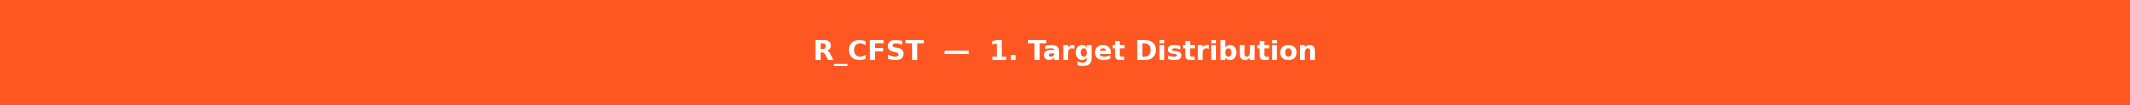


HOW TO READ:
  Histogram + KDE : Bell shape = normal. Right tail = few very large values.
  Boxplot          : Box = 25th–75th percentile. Dots beyond whiskers = outliers.
  ECDF             : Y-axis = % of data ≤ X. Steep = dense region, flat = sparse.
  Red line = median. Orange = mean. Gap between them = skewness.



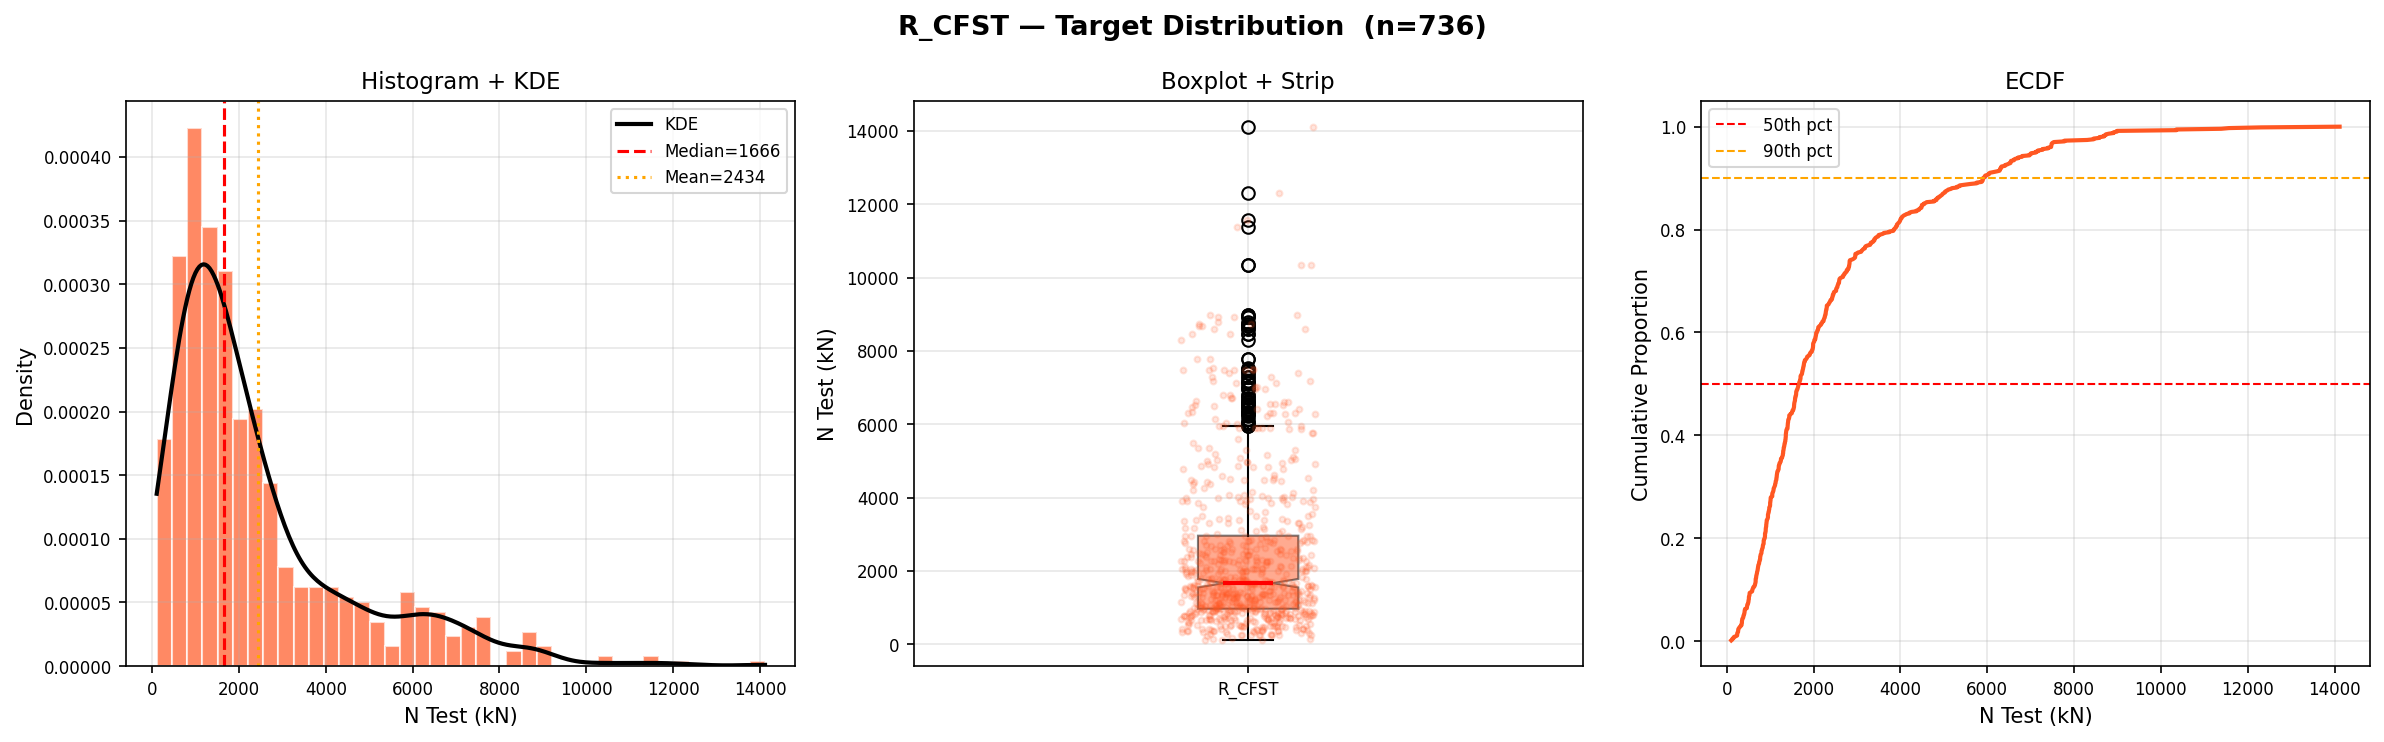

In [16]:

section_banner(f"{SHEET_NAME}  —  1. Target Distribution")

print("""
HOW TO READ:
  Histogram + KDE : Bell shape = normal. Right tail = few very large values.
  Boxplot          : Box = 25th–75th percentile. Dots beyond whiskers = outliers.
  ECDF             : Y-axis = % of data ≤ X. Steep = dense region, flat = sparse.
  Red line = median. Orange = mean. Gap between them = skewness.
""")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.hist(y, bins=40, color=color, alpha=0.7,
        edgecolor='white', density=True)
kde = gaussian_kde(y)
xr  = np.linspace(y.min(), y.max(), 300)
ax.plot(xr, kde(xr), color='black', lw=2, label='KDE')
ax.axvline(y.median(), color='red', linestyle='--',
           lw=1.5, label=f'Median={y.median():.0f}')
ax.axvline(y.mean(), color='orange', linestyle=':',
           lw=1.5, label=f'Mean={y.mean():.0f}')
ax.set_xlabel(TARGET); ax.set_ylabel('Density')
ax.set_title('Histogram + KDE')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.boxplot(y, notch=True, patch_artist=True,
           boxprops=dict(facecolor=color, alpha=0.5),
           medianprops=dict(color='red', lw=2))
jitter = np.random.uniform(-0.1, 0.1, n)
ax.scatter(1 + jitter, y, alpha=0.15, s=8,
           color=color, zorder=2)
ax.set_ylabel(TARGET)
ax.set_xticks([1]); ax.set_xticklabels([SHEET_NAME])
ax.set_title('Boxplot + Strip')
ax.grid(True, alpha=0.3)

ax = axes[2]
sorted_y = np.sort(y)
ecdf     = np.arange(1, n+1) / n
ax.plot(sorted_y, ecdf, color=color, lw=2)
ax.axhline(0.5, color='red', linestyle='--',
           lw=1, label='50th pct')
ax.axhline(0.9, color='orange', linestyle='--',
           lw=1, label='90th pct')
ax.set_xlabel(TARGET); ax.set_ylabel('Cumulative Proportion')
ax.set_title('ECDF')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'{SHEET_NAME} — Target Distribution  (n={n})',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### **FEATURE DISTRIBUTIONS**

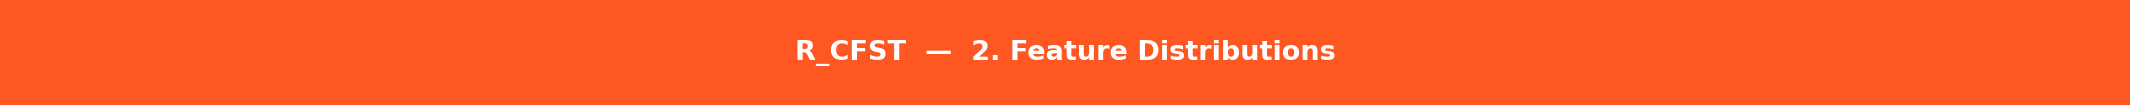


HOW TO READ:
  Each subplot = one feature.
  Shape of histogram shows if feature is normally distributed or skewed.
  Skew > 1.5 → log transformation recommended.
  Red = median, Orange = mean. Large gap = skewed distribution.



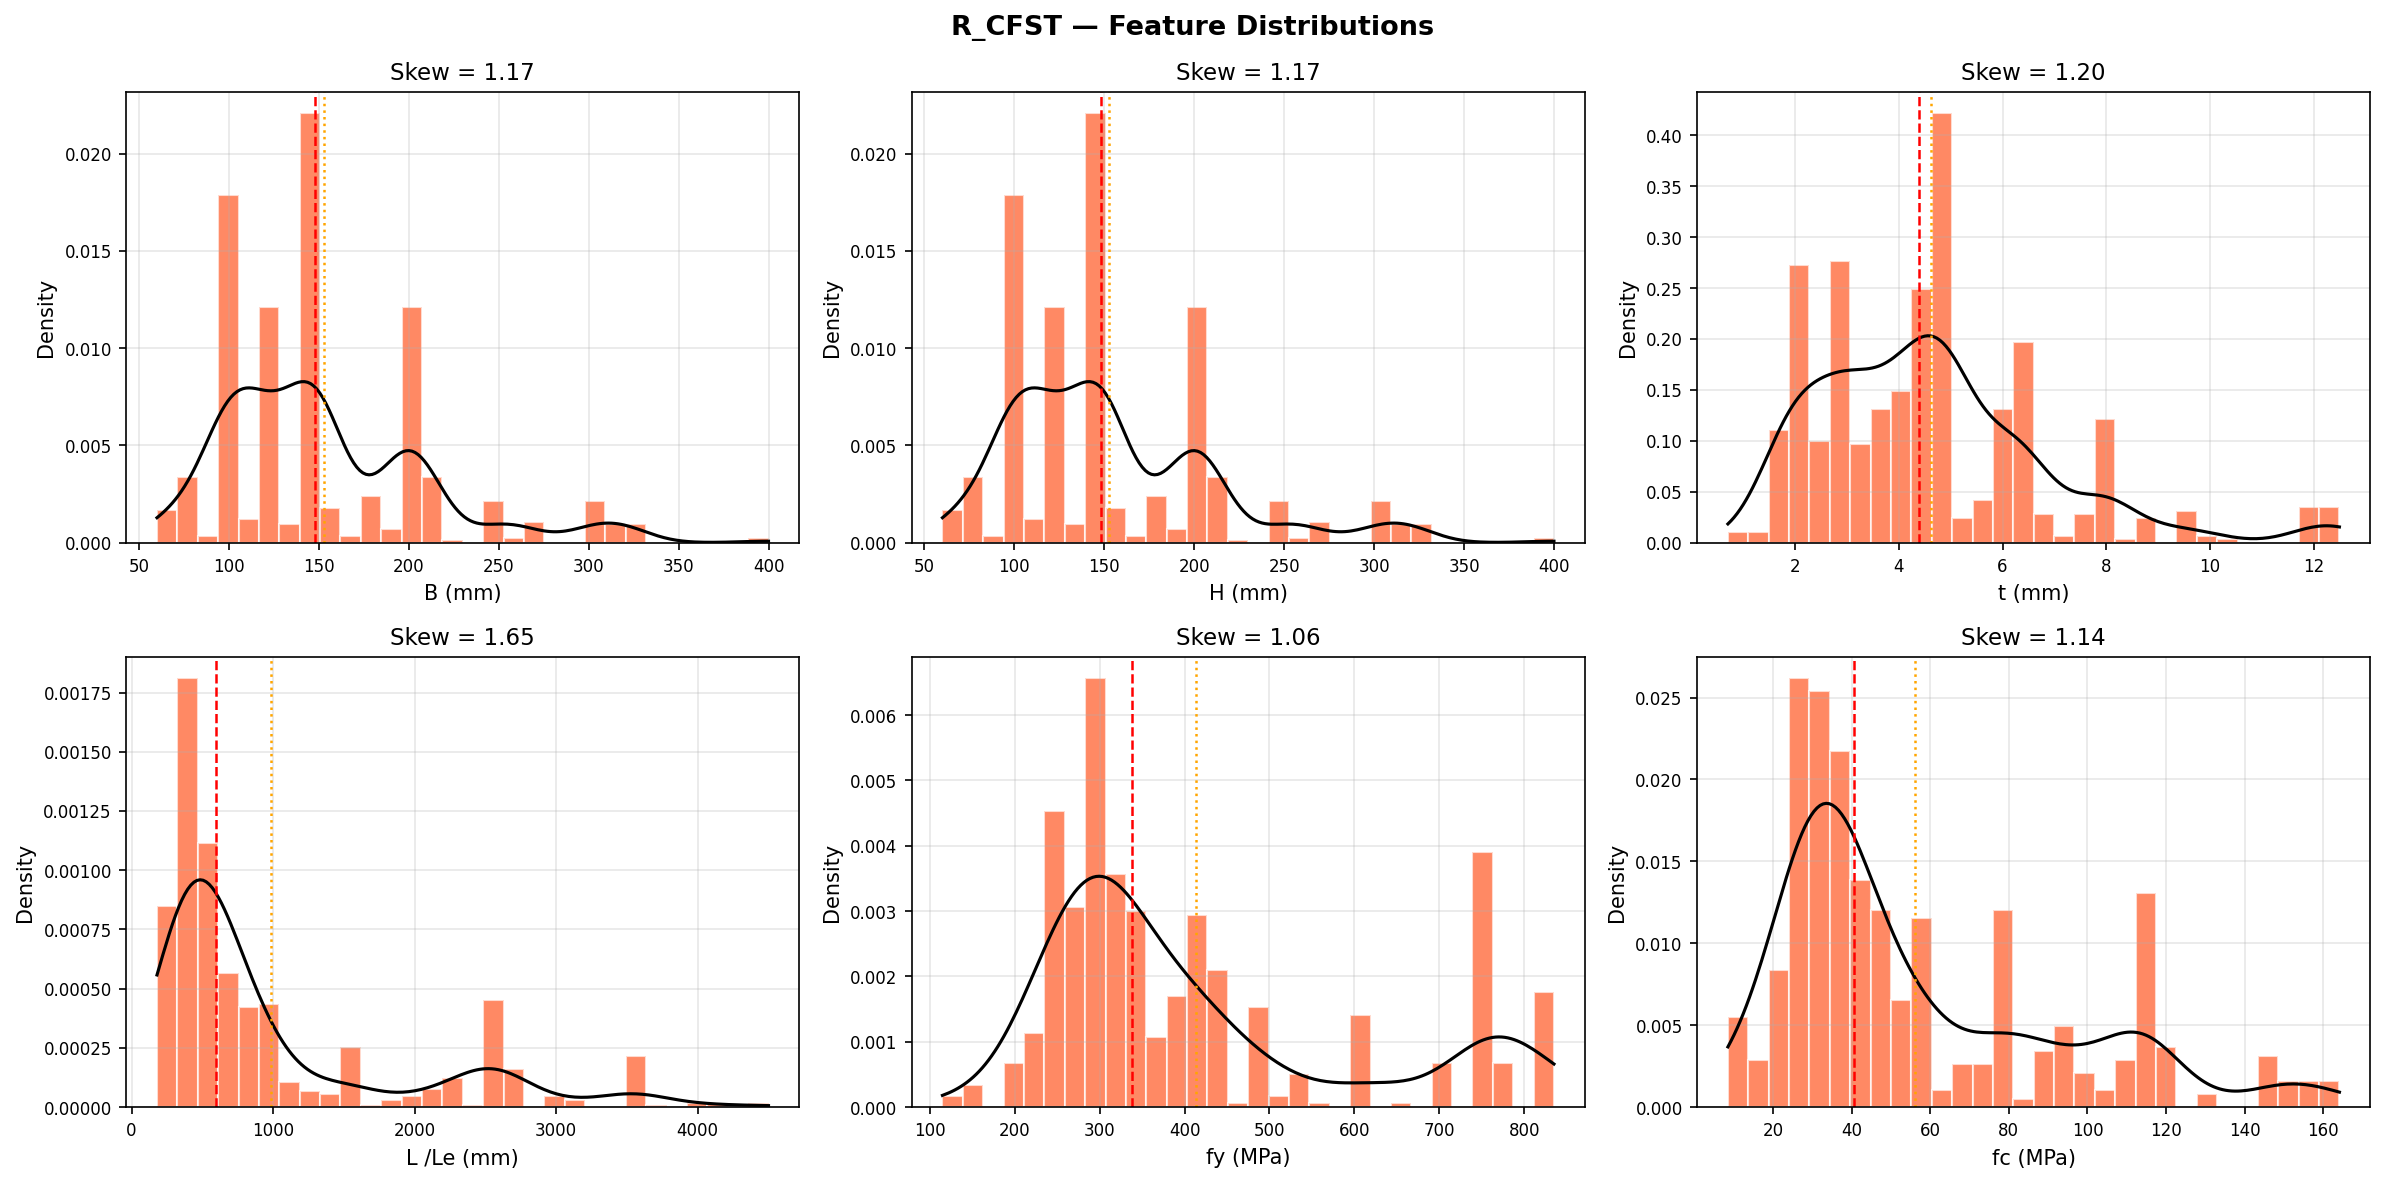

In [17]:

section_banner(f"{SHEET_NAME}  —  2. Feature Distributions")

print("""
HOW TO READ:
  Each subplot = one feature.
  Shape of histogram shows if feature is normally distributed or skewed.
  Skew > 1.5 → log transformation recommended.
  Red = median, Orange = mean. Large gap = skewed distribution.
""")

fig, axes = plt.subplots(nrow, ncol, figsize=(16, 4*nrow))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax  = axes[i]
    col = df[feat].dropna()
    ax.hist(col, bins=30, color=color, alpha=0.7,
            edgecolor='white', density=True)
    kde2 = gaussian_kde(col)
    xr2  = np.linspace(col.min(), col.max(), 200)
    ax.plot(xr2, kde2(xr2), 'k-', lw=1.5)
    ax.axvline(col.median(), color='red',
               linestyle='--', lw=1.2)
    ax.axvline(col.mean(), color='orange',
               linestyle=':', lw=1.2)
    ax.set_xlabel(feat); ax.set_ylabel('Density')
    ax.set_title(f'Skew = {col.skew():.2f}')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'{SHEET_NAME} — Feature Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### **FEATURES vs TARGET**


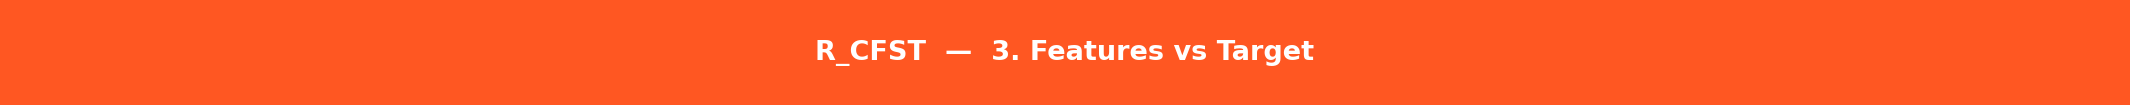


HOW TO READ:
  Each dot = one specimen. X = feature value, Y = axial capacity.
  Red line = linear fit (trend direction).
  r > 0.7 = strong positive link. r < 0.3 = weak / non-linear.
  Curved cloud = non-linear relationship (tree models handle this better).
  Wide spread at high X = heteroscedasticity (variance increases with load).



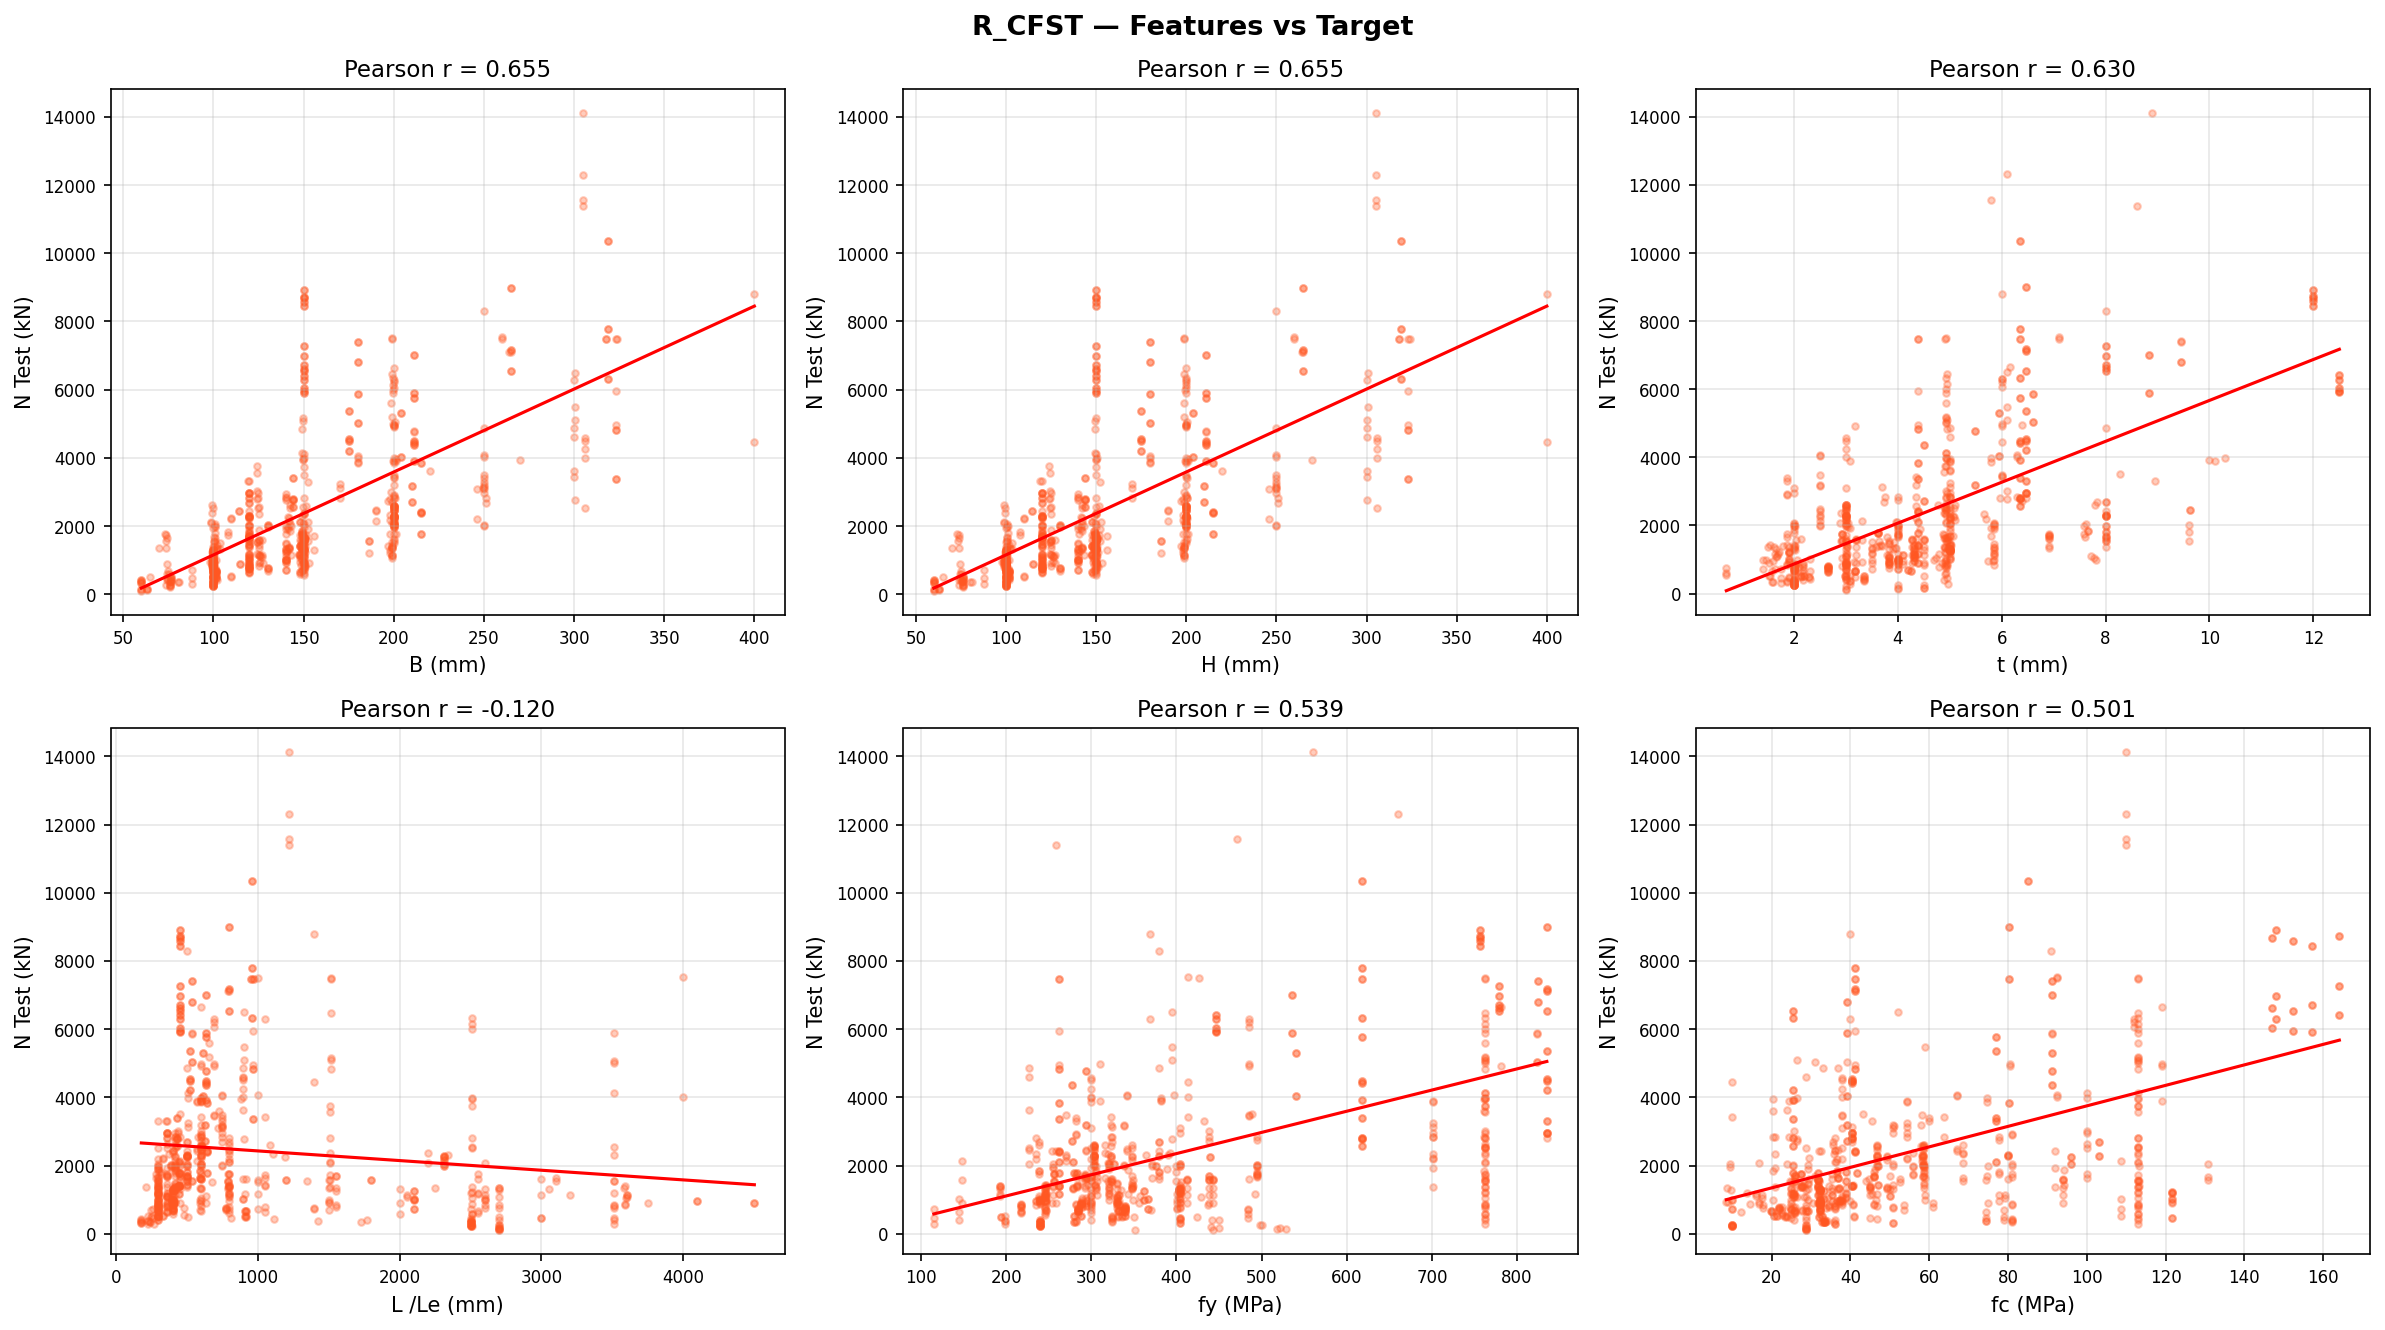

In [18]:

section_banner(f"{SHEET_NAME}  —  3. Features vs Target")

print("""
HOW TO READ:
  Each dot = one specimen. X = feature value, Y = axial capacity.
  Red line = linear fit (trend direction).
  r > 0.7 = strong positive link. r < 0.3 = weak / non-linear.
  Curved cloud = non-linear relationship (tree models handle this better).
  Wide spread at high X = heteroscedasticity (variance increases with load).
""")

fig, axes = plt.subplots(nrow, ncol, figsize=(16, 4.5*nrow))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    x  = df[feat].dropna()
    yy = y[x.index]
    r, _ = stats.pearsonr(x, yy)

    ax.scatter(x, yy, alpha=0.3, s=10, color=color)
    z  = np.polyfit(x, yy, 1)
    p2 = np.poly1d(z)
    xsort = np.linspace(x.min(), x.max(), 200)
    ax.plot(xsort, p2(xsort), 'r-', lw=1.5)
    ax.set_xlabel(feat); ax.set_ylabel(TARGET)
    ax.set_title(f'Pearson r = {r:.3f}')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'{SHEET_NAME} — Features vs Target',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### **CORRELATION HEATMAP**

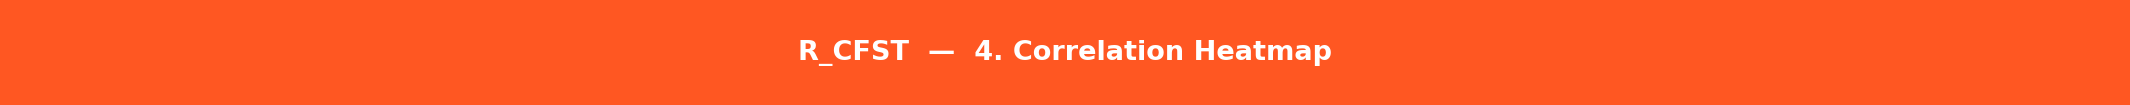


HOW TO READ:
  Red = strong positive correlation (+1).
  Blue = strong negative correlation (-1).
  White = no linear relationship (0).
  Last row/column = each feature's correlation with target.
  Dark red pairs between features = multicollinearity risk.



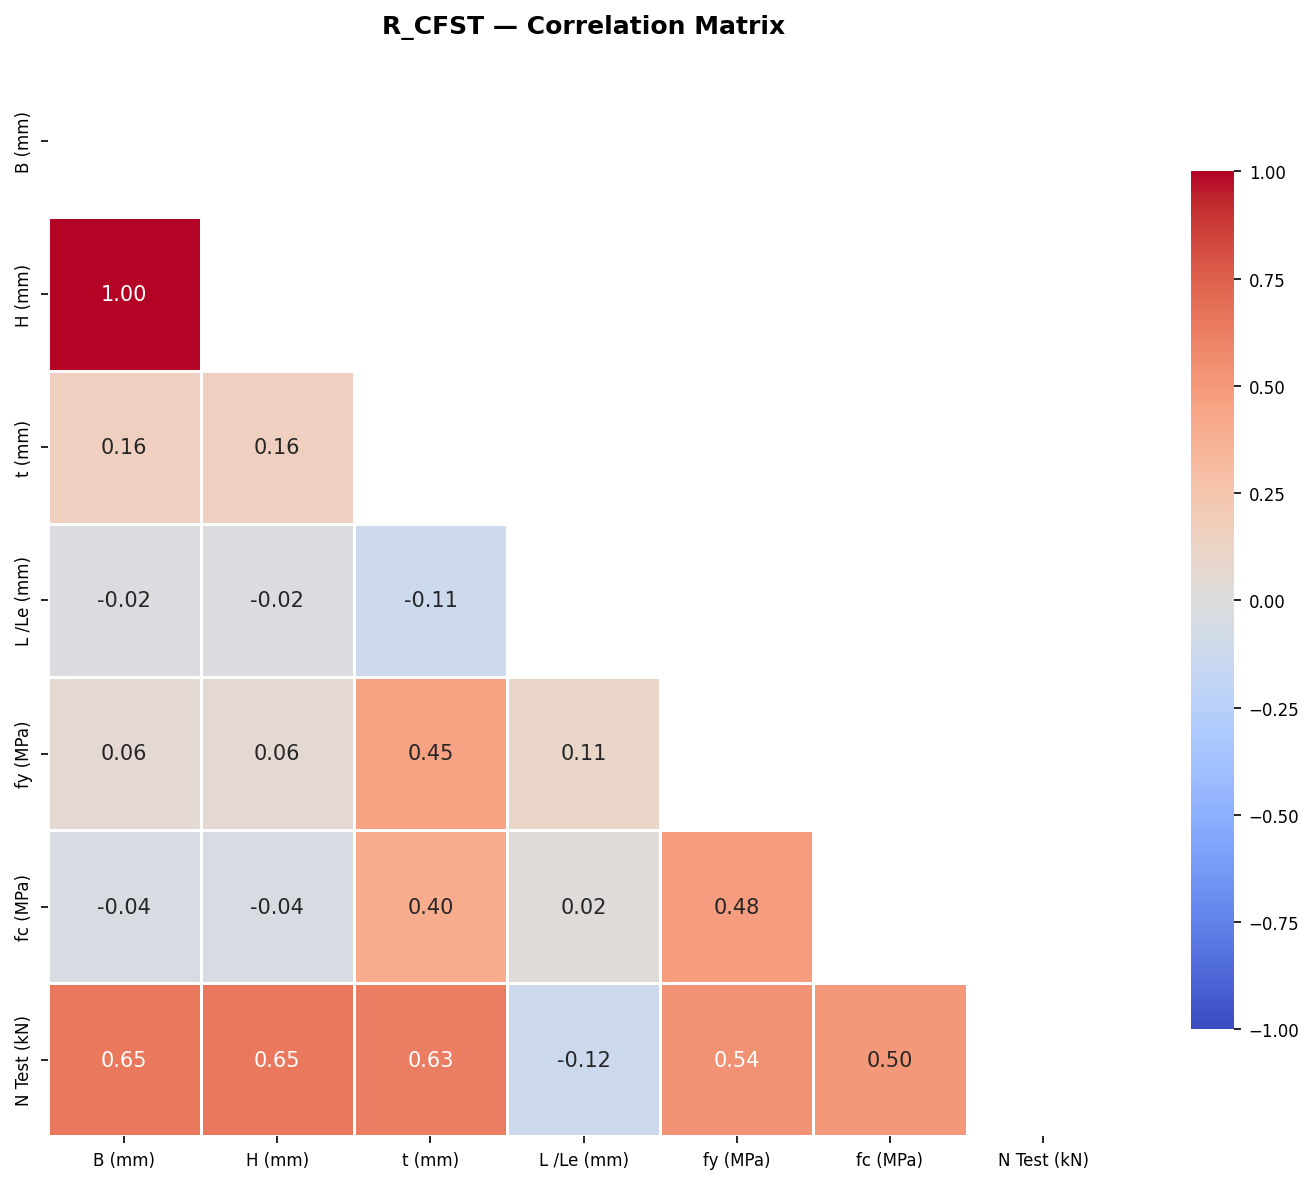

In [19]:

section_banner(f"{SHEET_NAME}  —  4. Correlation Heatmap")

print("""
HOW TO READ:
  Red = strong positive correlation (+1).
  Blue = strong negative correlation (-1).
  White = no linear relationship (0).
  Last row/column = each feature's correlation with target.
  Dark red pairs between features = multicollinearity risk.
""")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True,
            fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title(f'{SHEET_NAME} — Correlation Matrix',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()


### **PAIRPLOT (Top 4 features + Target)**

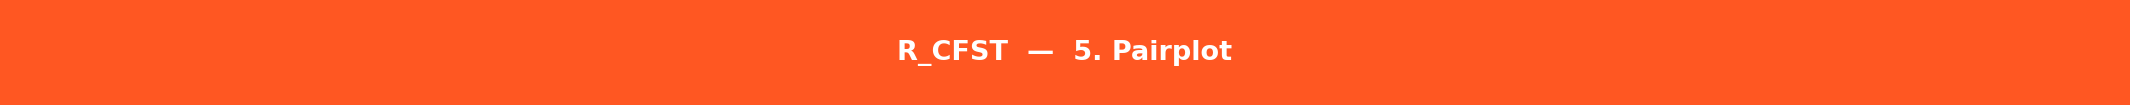


HOW TO READ:
  Diagonal = distribution of each variable (histogram).
  Upper triangle = scatter between every pair of variables.
  Lower triangle = density contours (darker = more specimens).
  Look for: linear trends (good feature), curved trends (non-linear),
  clusters (sub-groups), and outlier points far from the main cloud.



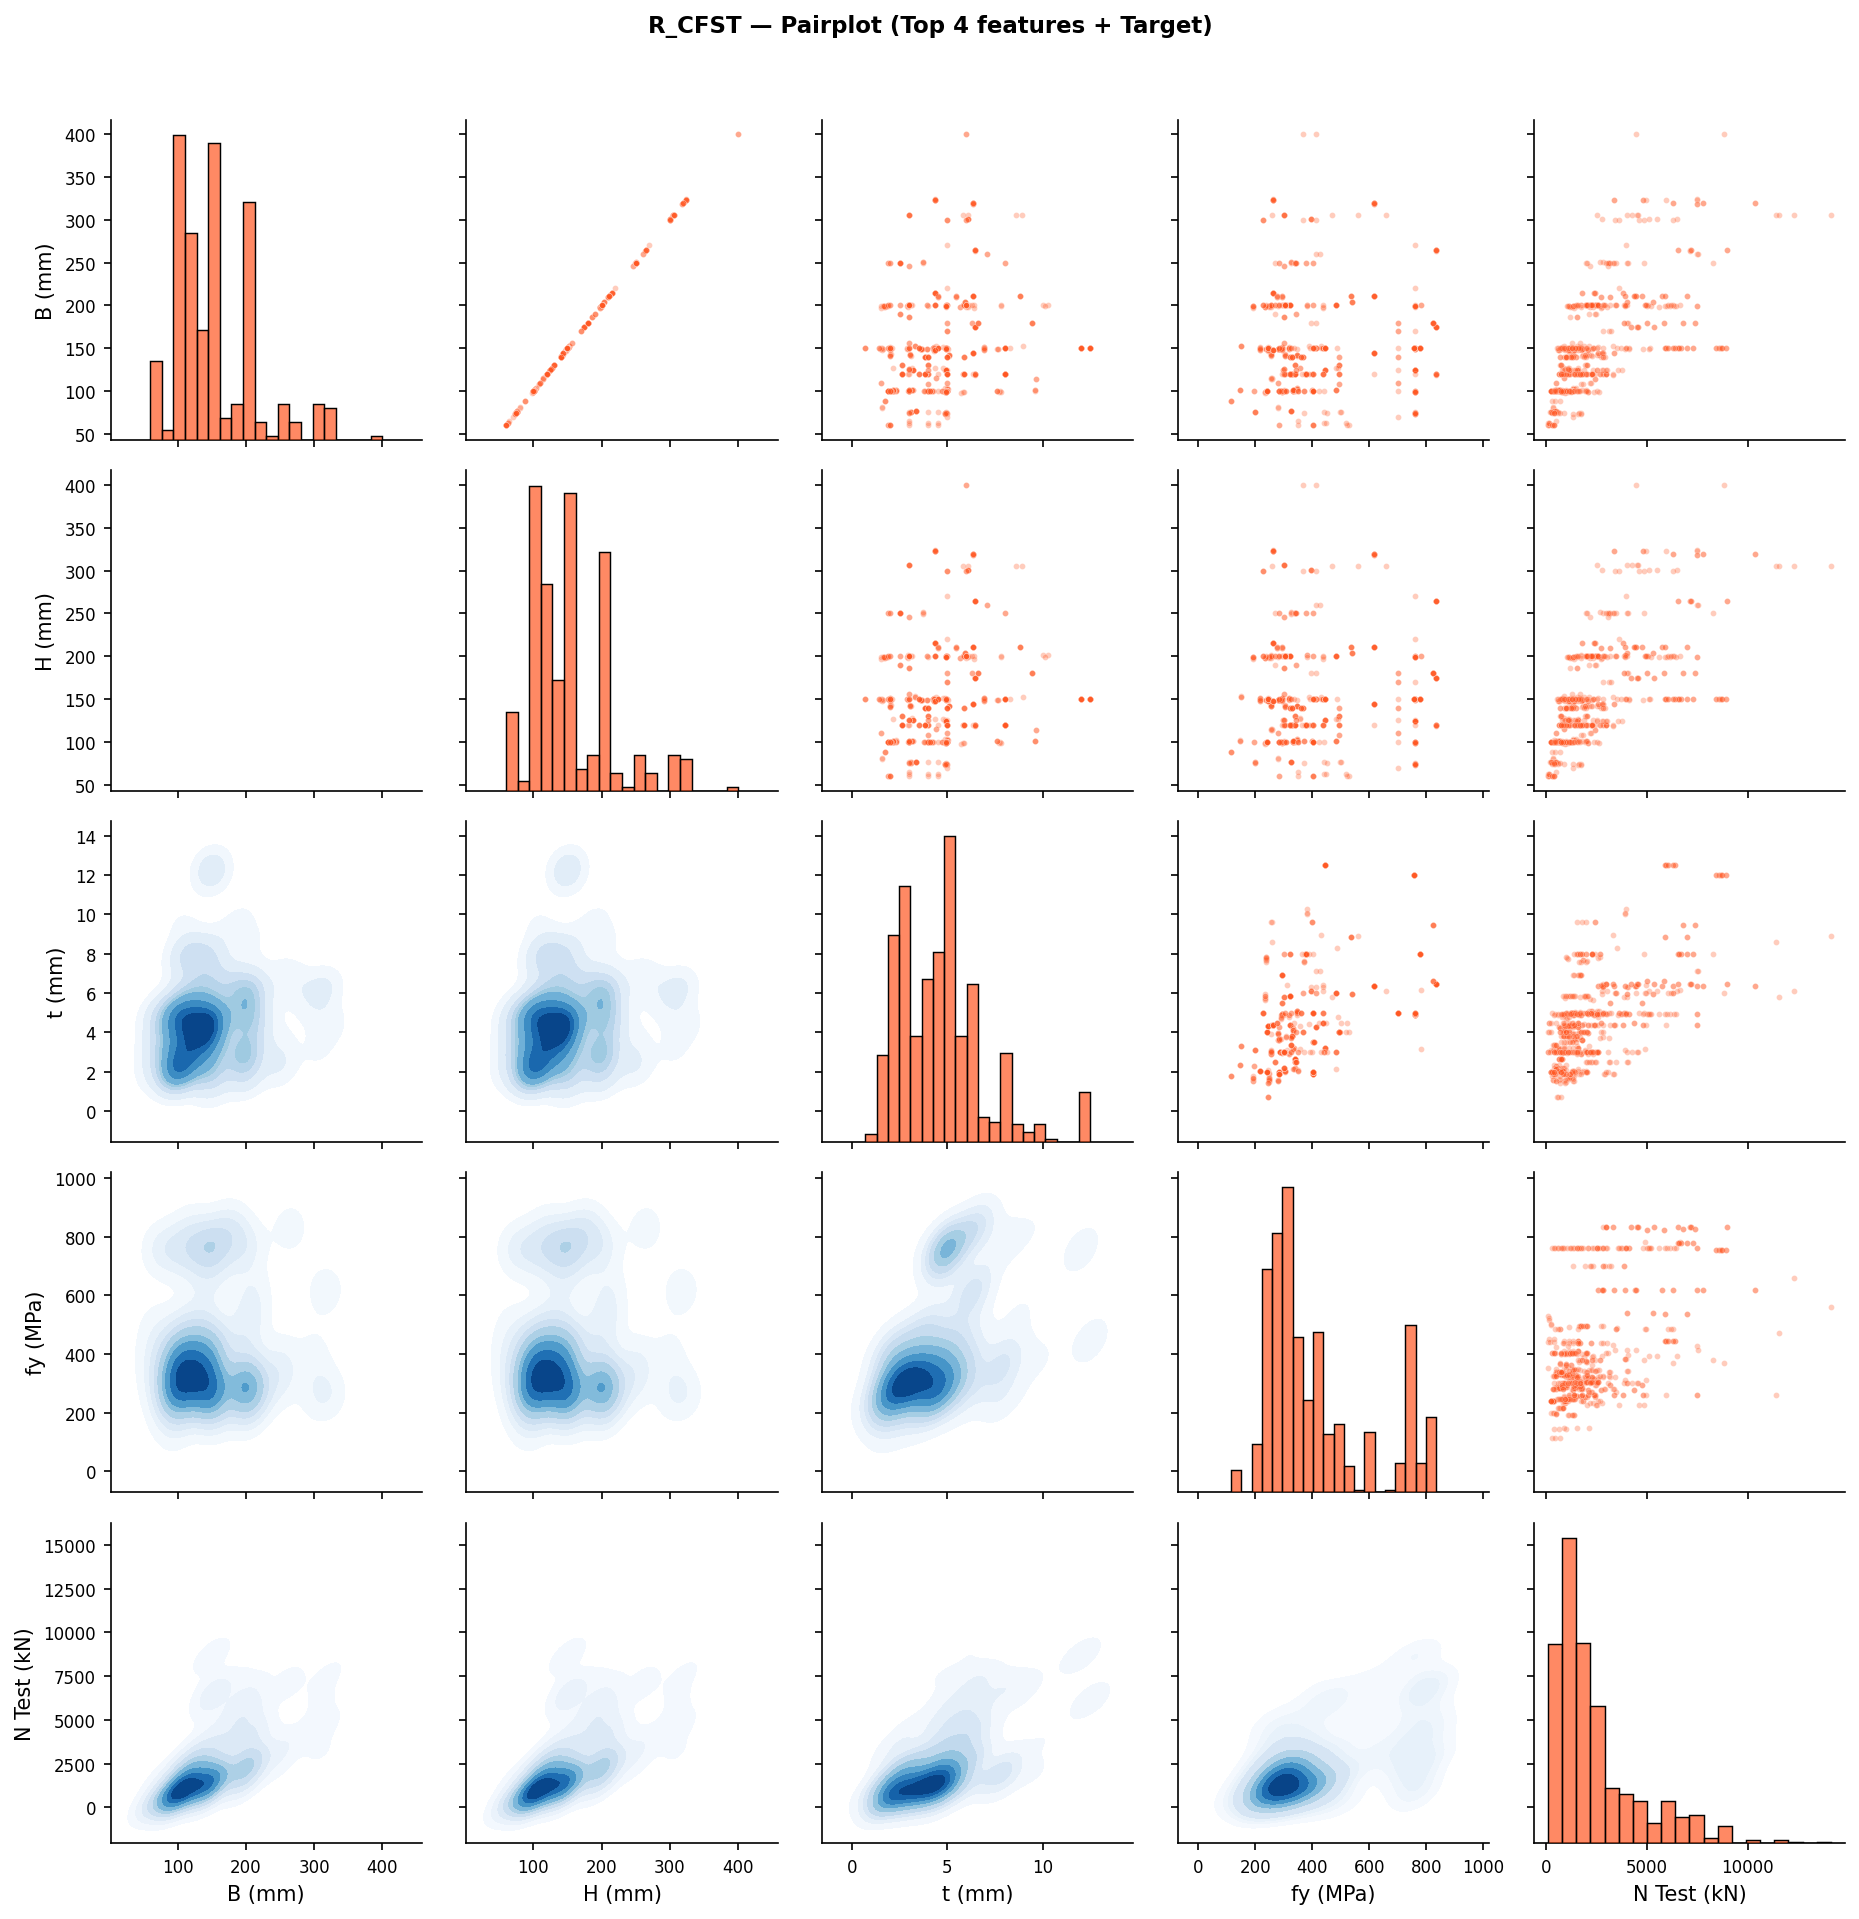

In [20]:

section_banner(f"{SHEET_NAME}  —  5. Pairplot")

print("""
HOW TO READ:
  Diagonal = distribution of each variable (histogram).
  Upper triangle = scatter between every pair of variables.
  Lower triangle = density contours (darker = more specimens).
  Look for: linear trends (good feature), curved trends (non-linear),
  clusters (sub-groups), and outlier points far from the main cloud.
""")

top4      = corr_target.nlargest(4).index.tolist()
pair_cols = top4 + [TARGET]
pair_df   = df_num[pair_cols].dropna()

g = sns.PairGrid(pair_df, diag_sharey=False)
g.map_diag(sns.histplot, color=color, alpha=0.7, bins=20)
g.map_upper(sns.scatterplot, alpha=0.3, s=8, color=color)
g.map_lower(sns.kdeplot, fill=True, cmap='Blues', thresh=0.05)
g.figure.suptitle(
    f'{SHEET_NAME} — Pairplot (Top 4 features + Target)',
    y=1.02, fontsize=11, fontweight='bold'
)
plt.tight_layout(); plt.show()


### **FEATURE BOXPLOTS (Outlier View)**

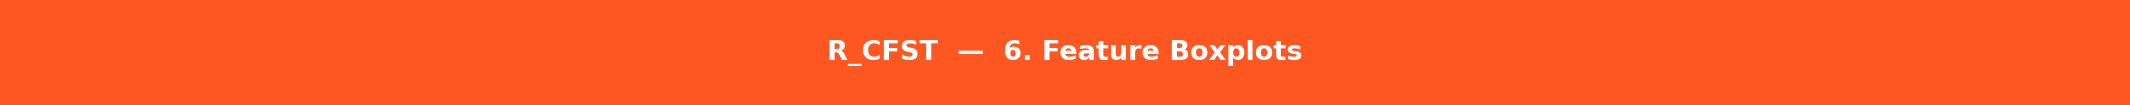


HOW TO READ:
  Box = 25th–75th percentile (IQR). Line inside = median.
  Whiskers = 1.5 × IQR from box edges.
  Dots beyond whiskers = statistical outliers (may be valid specimens).
  Wide box = high variability in that feature.
  Asymmetric box = skewed distribution.



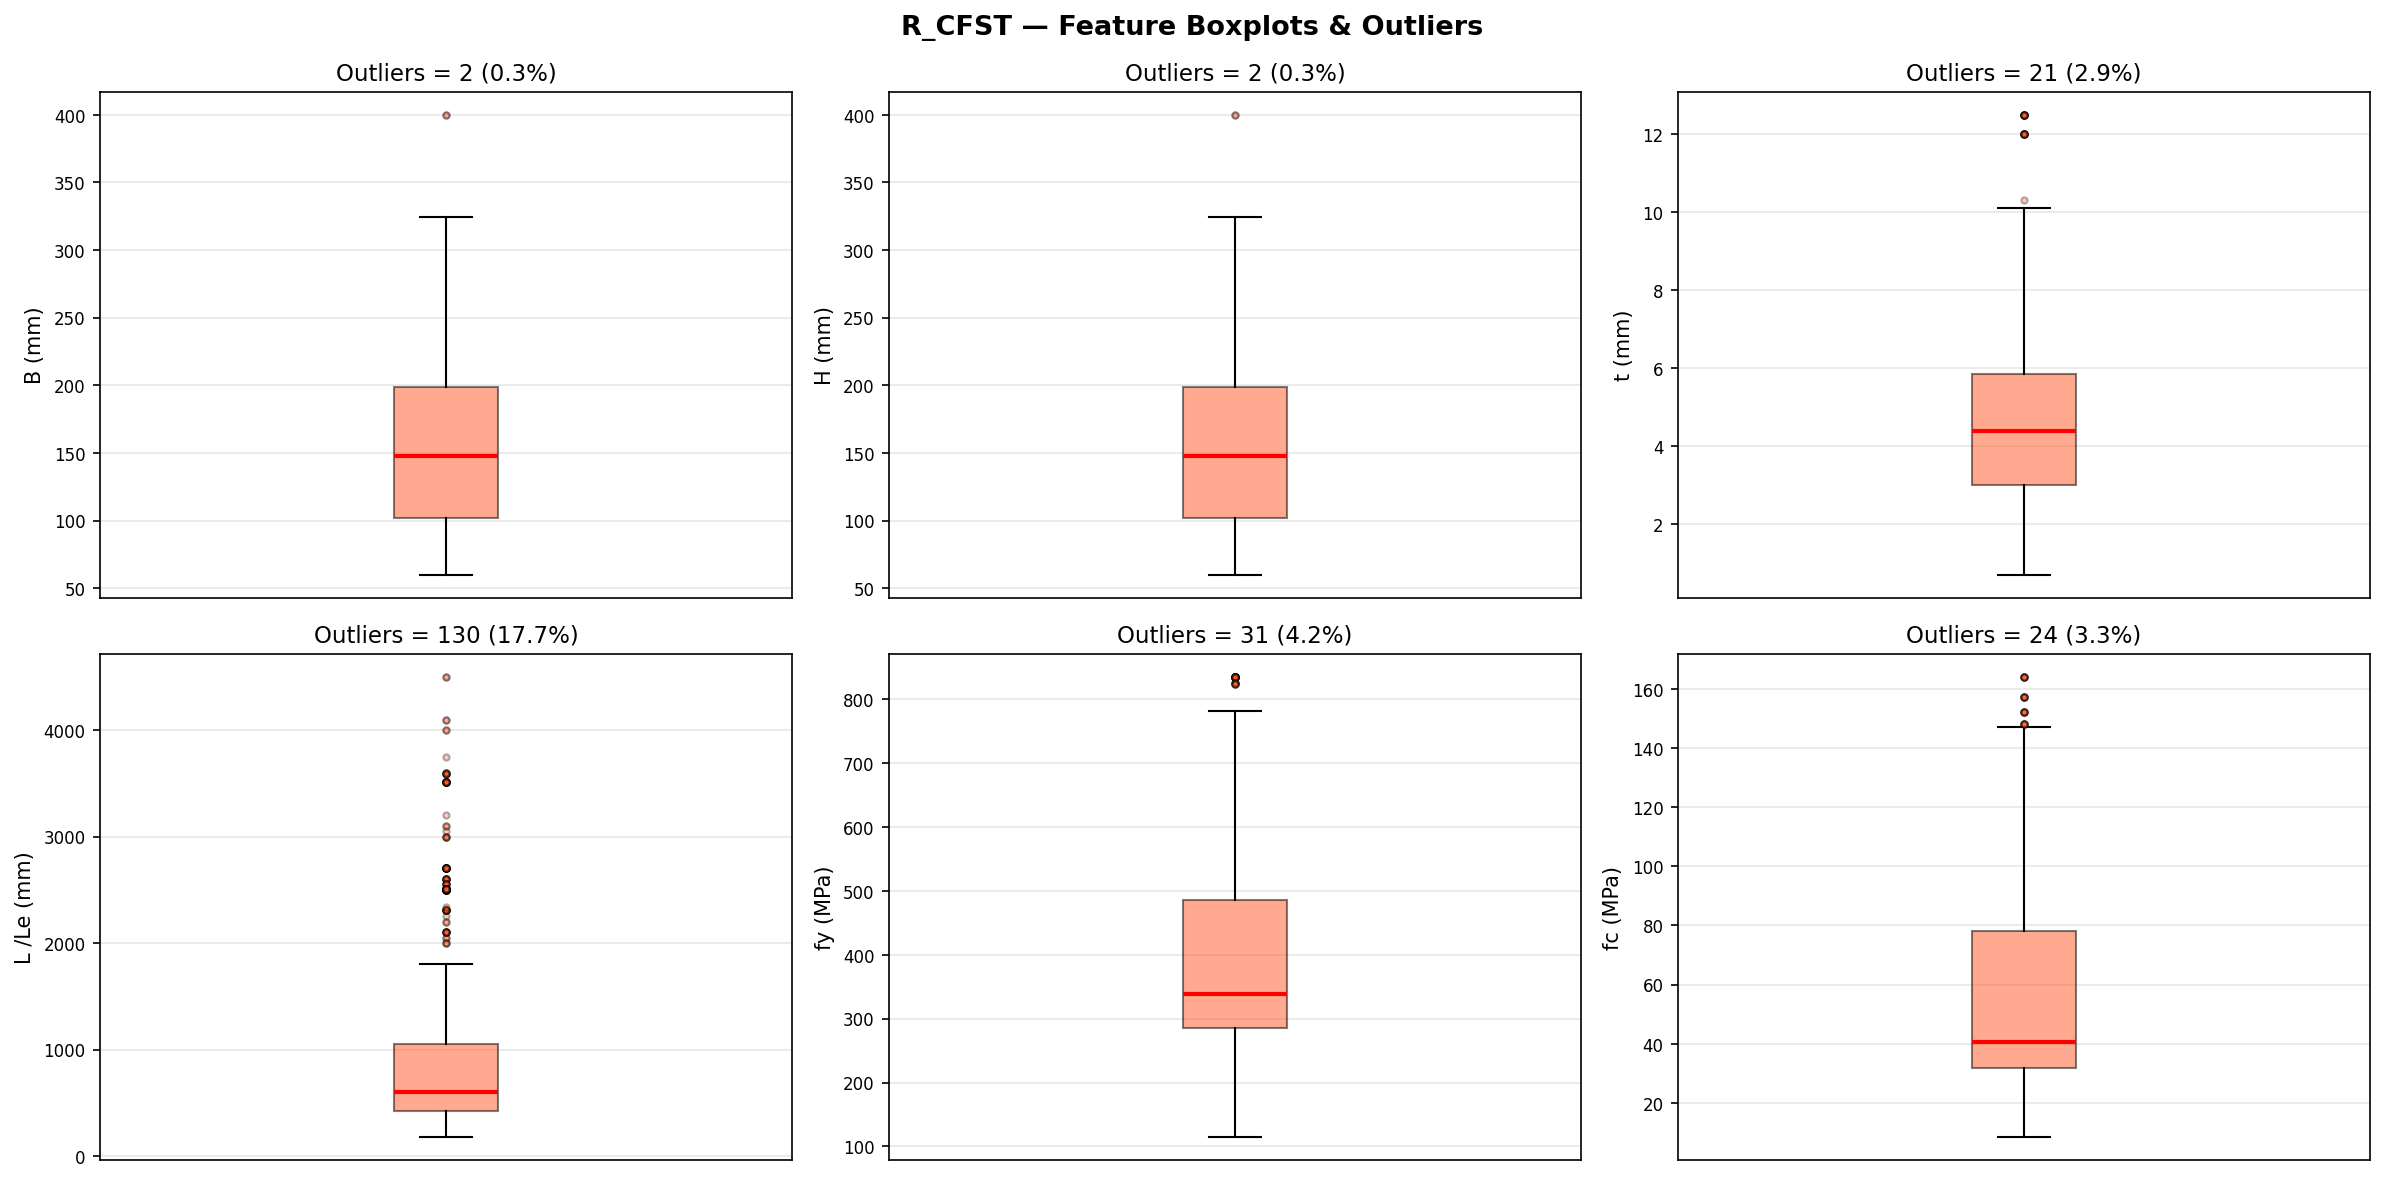

In [21]:

section_banner(f"{SHEET_NAME}  —  6. Feature Boxplots")

print("""
HOW TO READ:
  Box = 25th–75th percentile (IQR). Line inside = median.
  Whiskers = 1.5 × IQR from box edges.
  Dots beyond whiskers = statistical outliers (may be valid specimens).
  Wide box = high variability in that feature.
  Asymmetric box = skewed distribution.
""")

fig, axes = plt.subplots(2, int(np.ceil(nf/2)),
                          figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax  = axes[i]
    col = df[feat].dropna()
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((col < Q1-1.5*IQR) |
               (col > Q3+1.5*IQR)).sum()

    ax.boxplot(col, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='red', lw=2),
               flierprops=dict(marker='o', markersize=3,
                               alpha=0.3,
                               markerfacecolor=color))
    ax.set_ylabel(feat)
    ax.set_xticks([])
    ax.set_title(f'Outliers = {n_out} ({100*n_out/len(col):.1f}%)')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'{SHEET_NAME} — Feature Boxplots & Outliers',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### **BINNED HEATMAP (Feature × Target)**

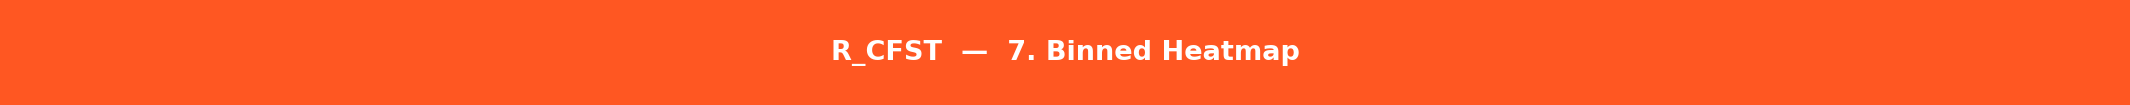


HOW TO READ:
  X-axis = feature divided into 10 equal-range bins.
  Y-axis = target divided into 10 equal-range bins.
  Color intensity = number of specimens in that cell (darker = more).
  Diagonal pattern from bottom-left to top-right = positive correlation.
  Concentrated cells = where most data lives (model is reliable there).
  Sparse top-right = few high-load specimens (model less reliable there).



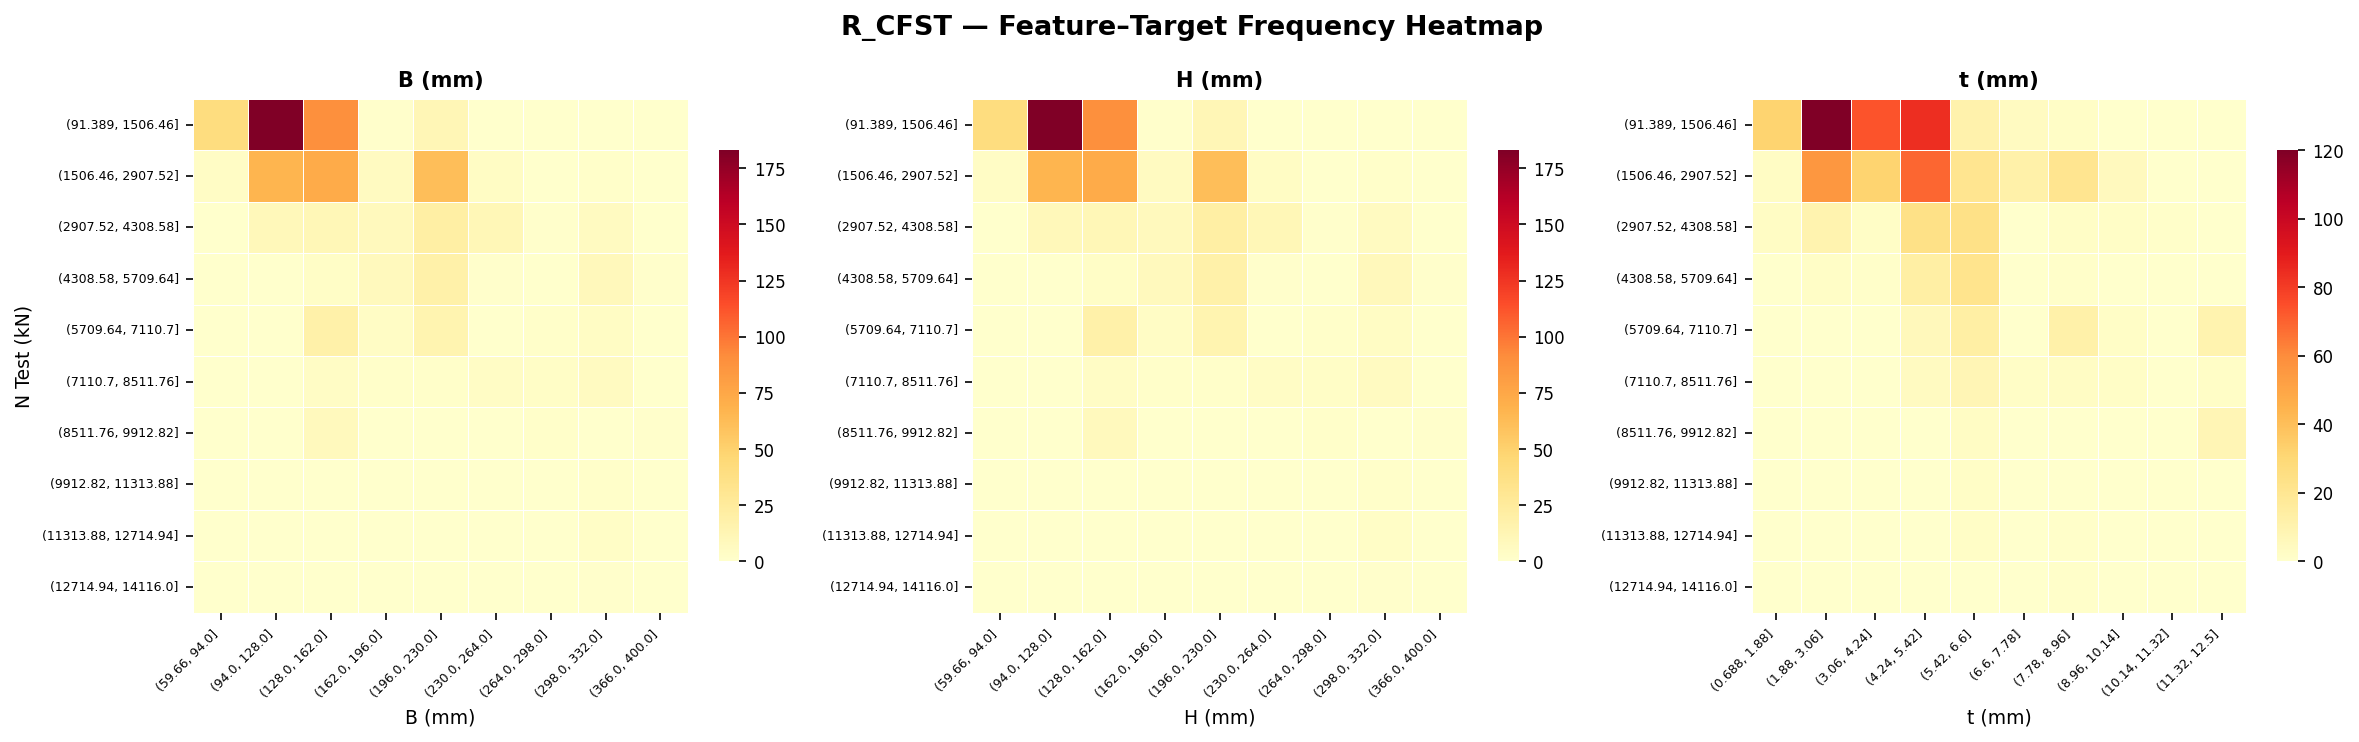

In [22]:

section_banner(f"{SHEET_NAME}  —  7. Binned Heatmap")

print("""
HOW TO READ:
  X-axis = feature divided into 10 equal-range bins.
  Y-axis = target divided into 10 equal-range bins.
  Color intensity = number of specimens in that cell (darker = more).
  Diagonal pattern from bottom-left to top-right = positive correlation.
  Concentrated cells = where most data lives (model is reliable there).
  Sparse top-right = few high-load specimens (model less reliable there).
""")

top3 = corr_target.nlargest(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat in enumerate(top3):
    ax     = axes[i]
    x_bins = pd.cut(df[feat], bins=10)
    y_bins = pd.cut(y, bins=10)
    heat   = pd.crosstab(y_bins, x_bins)

    sns.heatmap(heat, ax=ax, cmap='YlOrRd',
                linewidths=0.3,
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel(TARGET if i == 0 else '', fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(),
                       rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(),
                       rotation=0, fontsize=6)
    ax.set_title(feat, fontsize=10, fontweight='bold')

plt.suptitle(f'{SHEET_NAME} — Feature–Target Frequency Heatmap',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### **VIOLIN PLOTS (Feature by Target Quartile)**

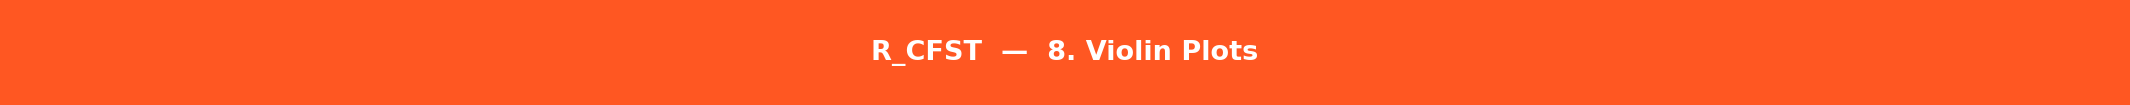


HOW TO READ:
  X-axis = target quartile (Q1=low load, Q4=high load).
  Width at each Y value = density (more specimens at that feature value).
  Widening as quartile increases = feature rises with target (positive link).
  Inner box = IQR. Inner dot = median.
  Identical shapes across quartiles = feature has no influence on target.



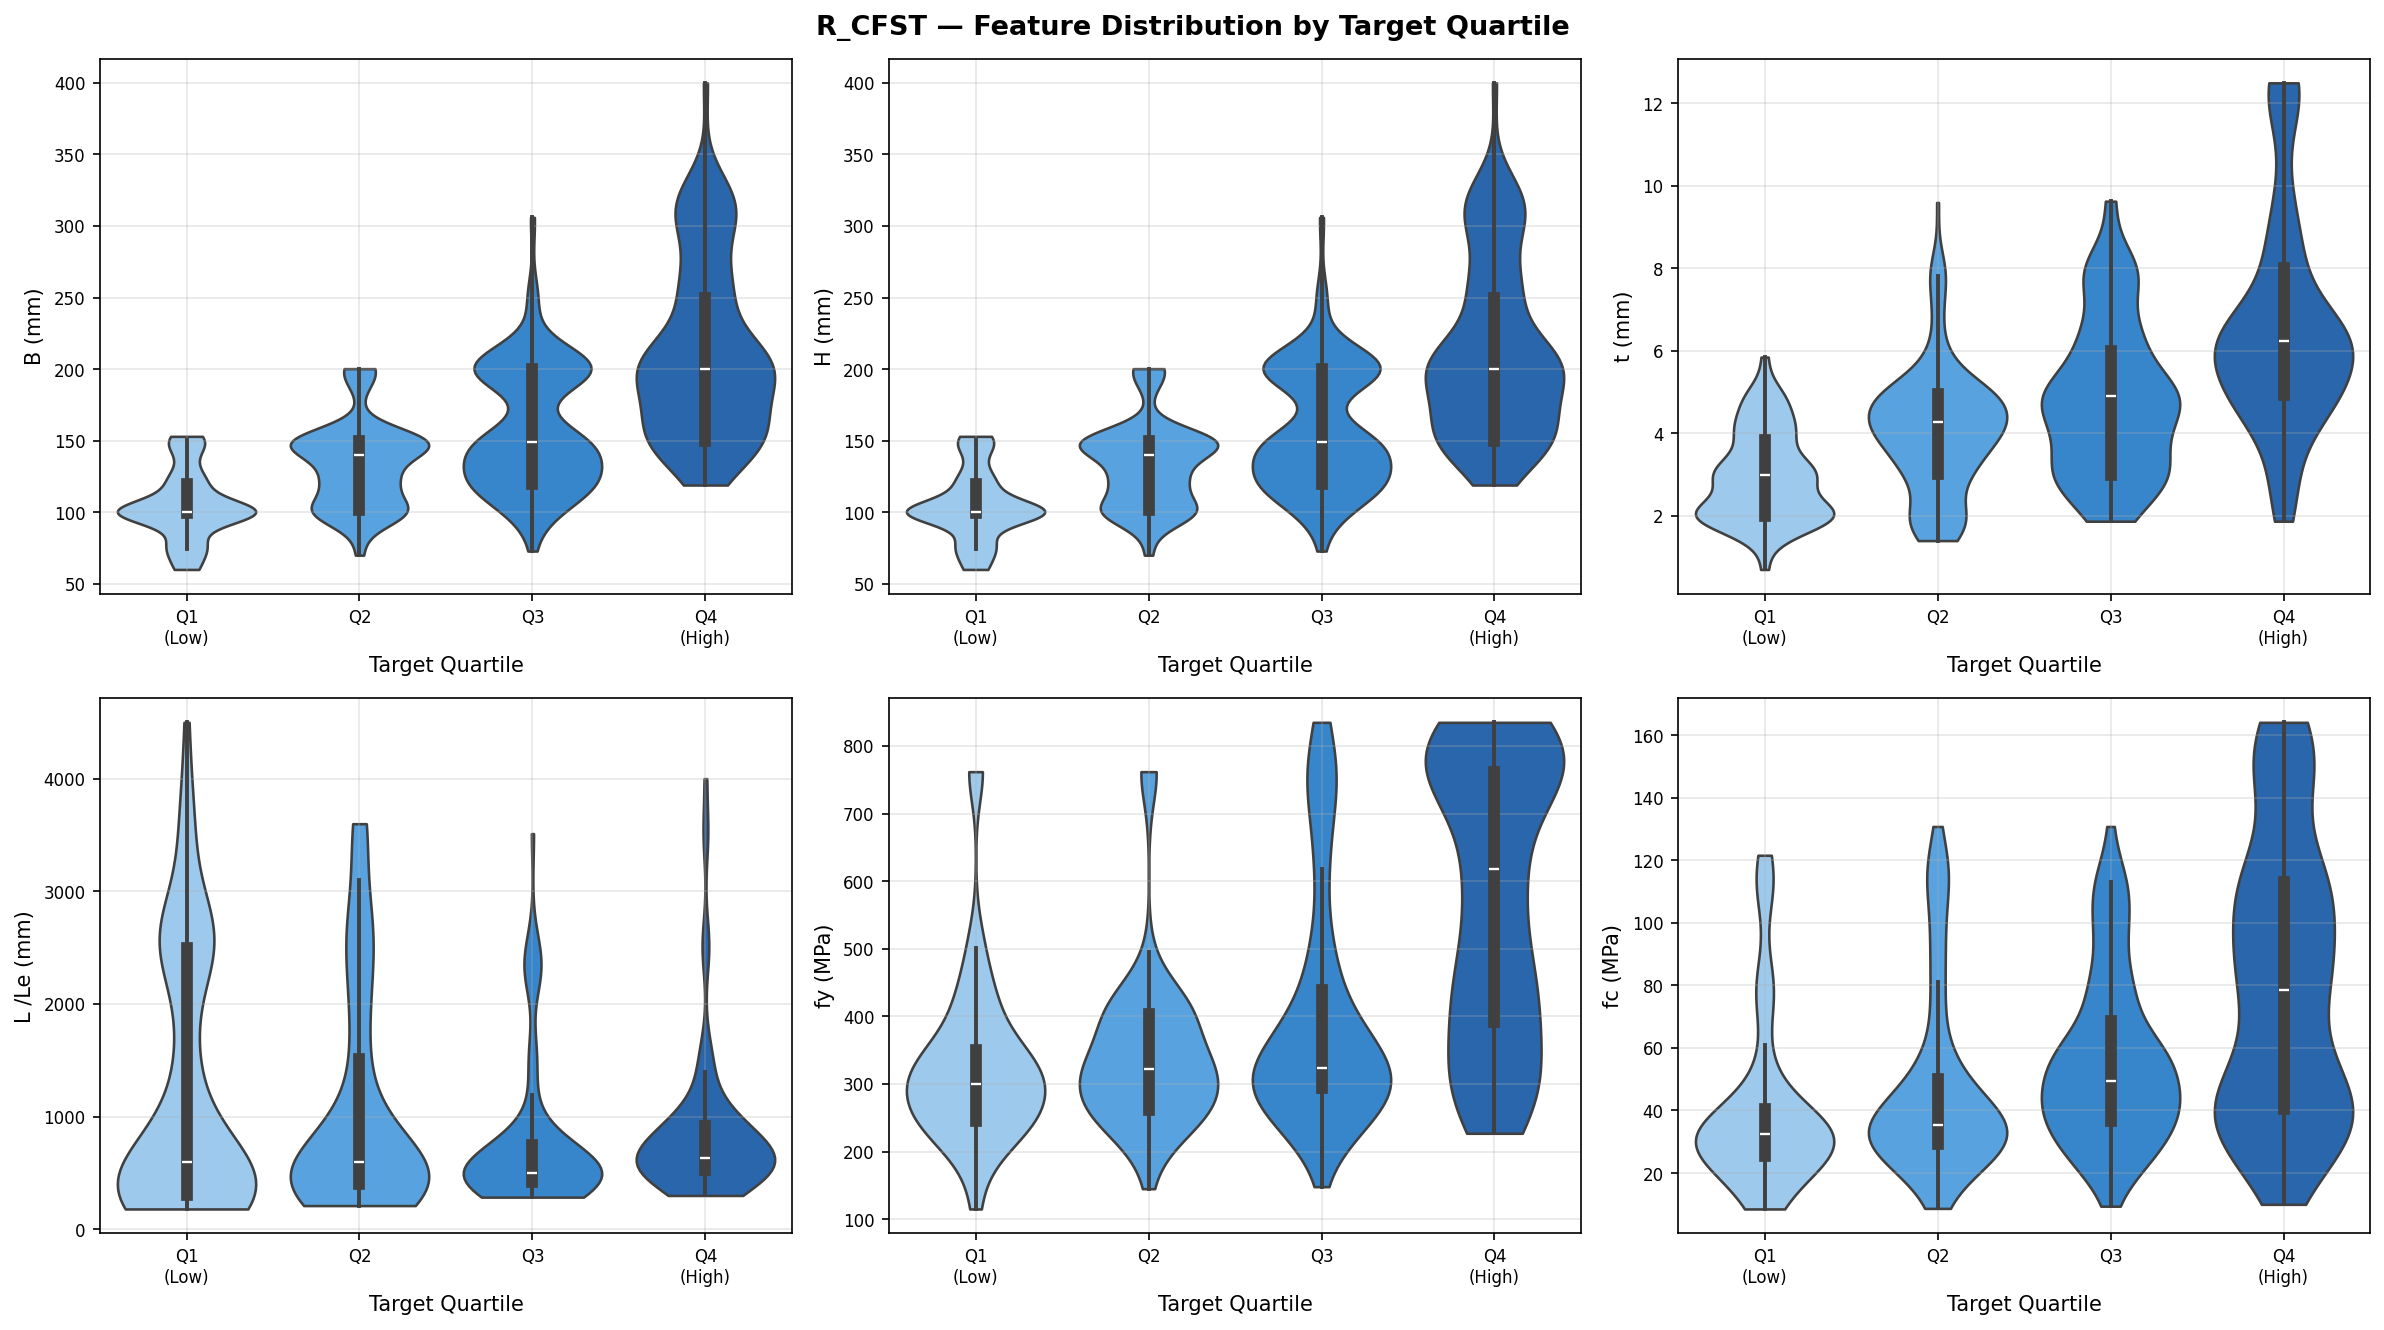

In [23]:


section_banner(f"{SHEET_NAME}  —  8. Violin Plots")

print("""
HOW TO READ:
  X-axis = target quartile (Q1=low load, Q4=high load).
  Width at each Y value = density (more specimens at that feature value).
  Widening as quartile increases = feature rises with target (positive link).
  Inner box = IQR. Inner dot = median.
  Identical shapes across quartiles = feature has no influence on target.
""")

df_v = df_num.copy()
df_v['Target_Quartile'] = pd.qcut(
    y, q=4,
    labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4\n(High)']
)

fig, axes = plt.subplots(2, int(np.ceil(nf/2)),
                          figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    sns.violinplot(
        data=df_v, x='Target_Quartile', y=feat,
        palette=['#90CAF9', '#42A5F5',
                 '#1E88E5', '#1565C0'],
        ax=ax, inner='box', cut=0
    )
    ax.set_xlabel('Target Quartile')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f'{SHEET_NAME} — Feature Distribution by Target Quartile',
    fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### **FEATURE INTERACTIONS (colored by Target)**

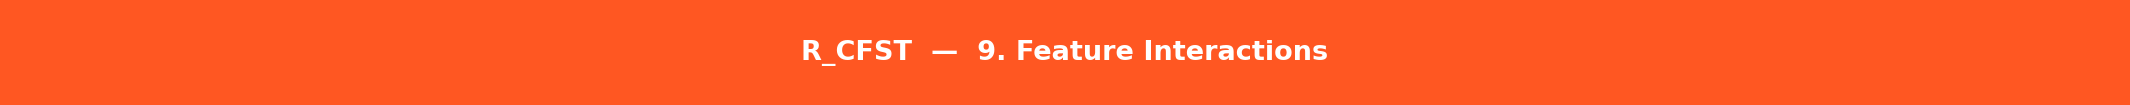


HOW TO READ:
  Each dot = one specimen. Color = target value (dark purple=high, yellow=low).
  X and Y axes = two features at once.
  Color gradient along X or Y = that feature drives target.
  Clusters of same color = feature combinations that produce similar loads.
  Diagonal color bands = strong interaction between both features and target.



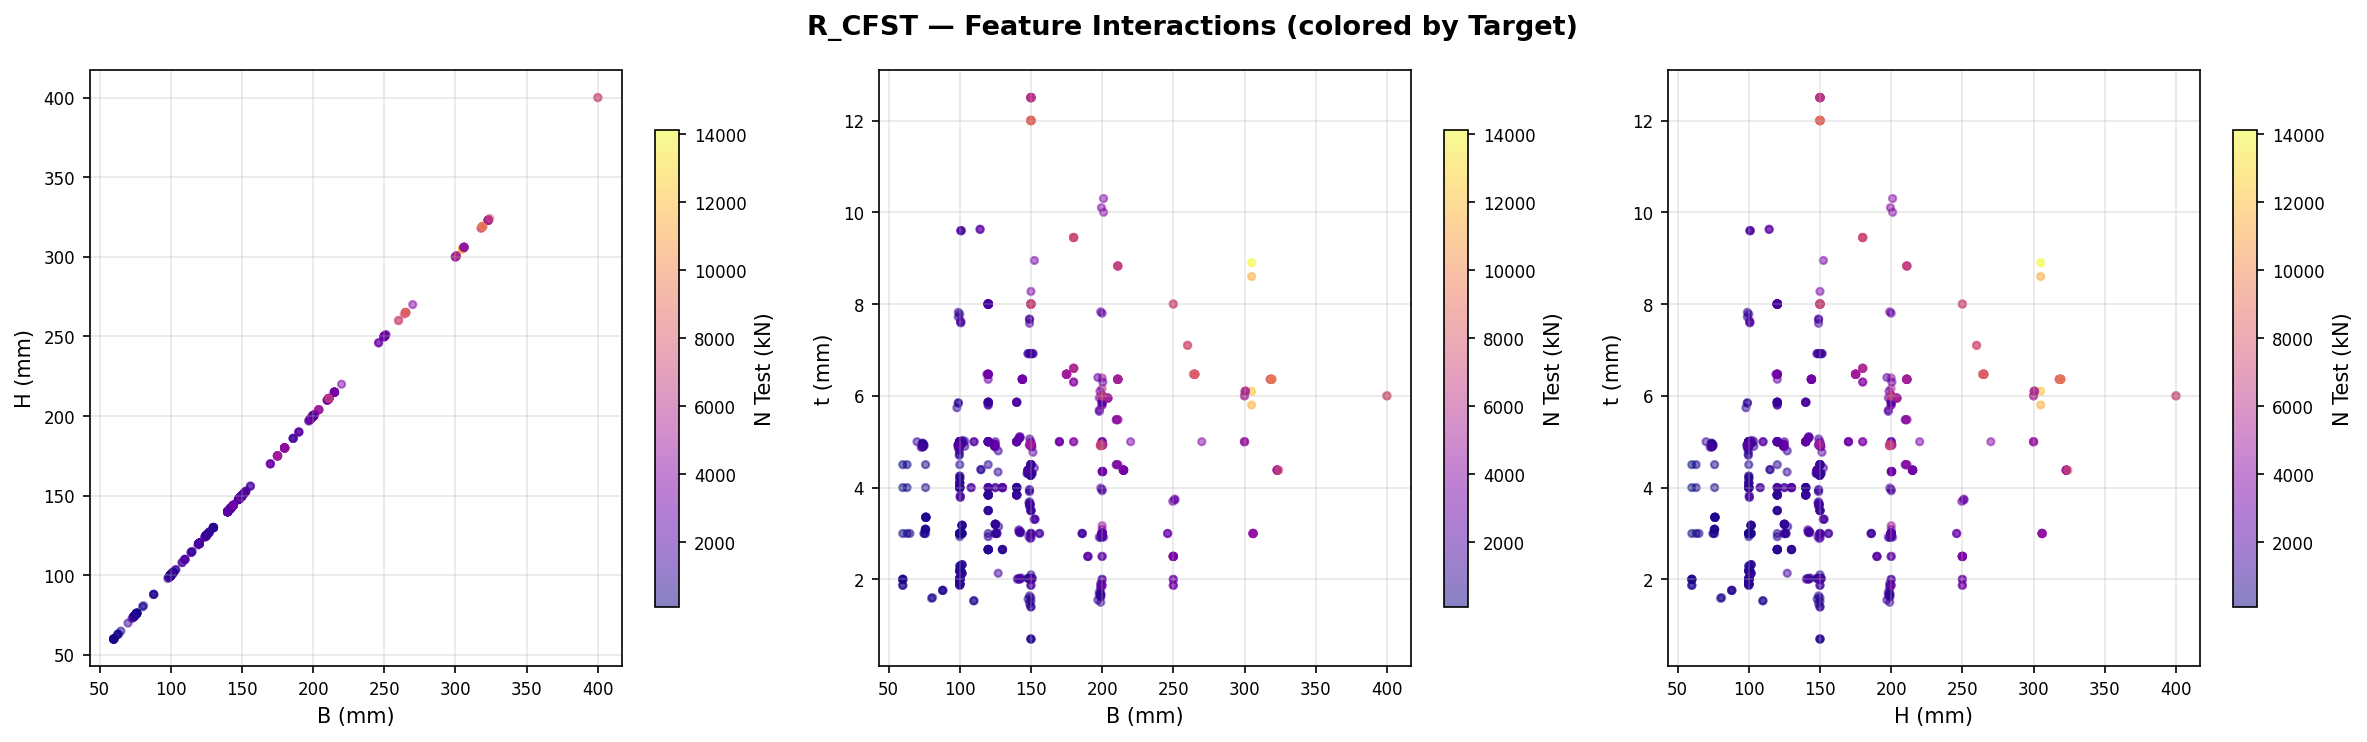

In [24]:


section_banner(f"{SHEET_NAME}  —  9. Feature Interactions")

print("""
HOW TO READ:
  Each dot = one specimen. Color = target value (dark purple=high, yellow=low).
  X and Y axes = two features at once.
  Color gradient along X or Y = that feature drives target.
  Clusters of same color = feature combinations that produce similar loads.
  Diagonal color bands = strong interaction between both features and target.
""")

combos = [
    (top3[0], top3[1]),
    (top3[0], top3[2]),
    (top3[1], top3[2]),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (f1, f2) in enumerate(combos):
    ax = axes[i]
    sc = ax.scatter(df[f1], df[f2],
                    c=y, cmap='plasma',
                    alpha=0.5, s=12)
    plt.colorbar(sc, ax=ax,
                 label=TARGET, shrink=0.8)
    ax.set_xlabel(f1); ax.set_ylabel(f2)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'{SHEET_NAME} — Feature Interactions (colored by Target)',
    fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### **SUMMARY DASHBOARD**

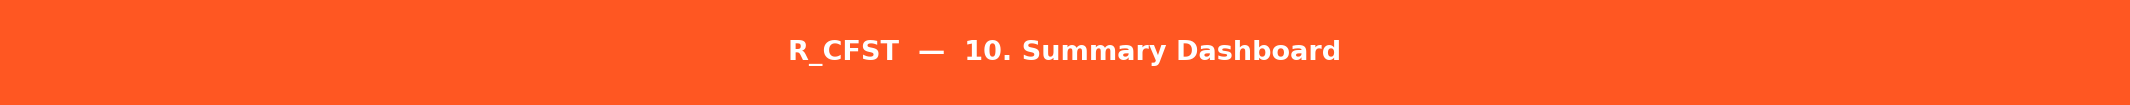


HOW TO READ:
  Top-left  : Target distribution — shape and spread.
  Top-middle : Correlation bar chart — which features matter most.
  Top-right  : Best feature vs target — strongest linear driver.
  Bottom-left: Normalized boxplots (z-score) — compare spread across features.
  Bottom-right: Stats table — CV = variability relative to mean (higher = more spread).



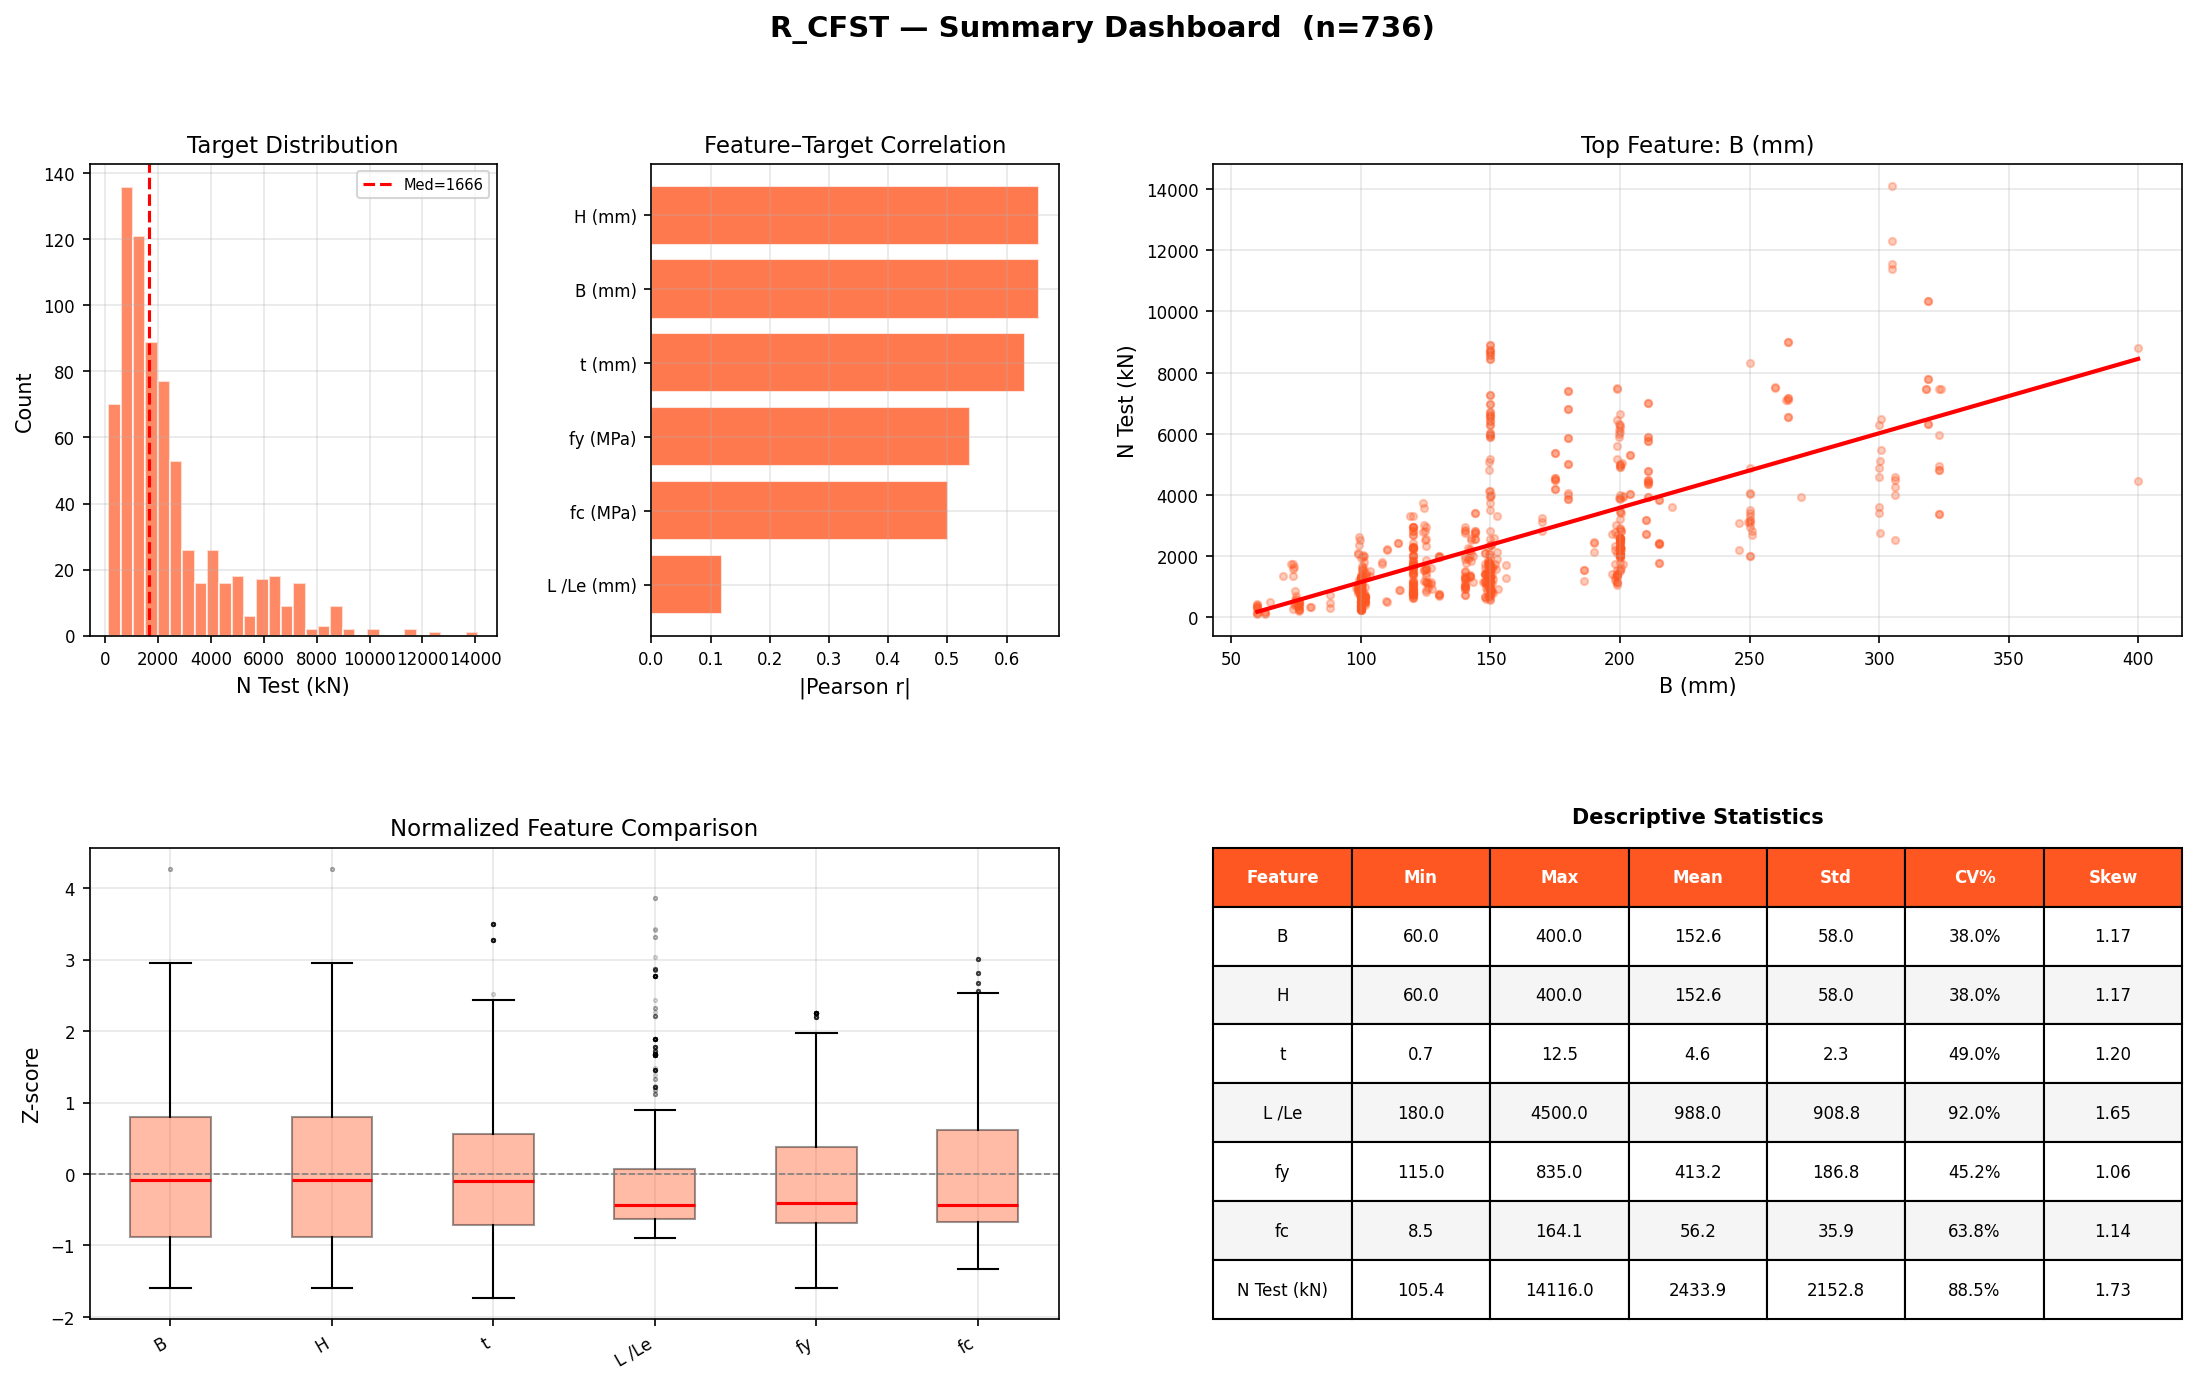


✅ R_CFST — All 10 visualizations complete
   Change SHEET_NAME at the top to run for another sheet


In [25]:


section_banner(f"{SHEET_NAME}  —  10. Summary Dashboard")

print("""
HOW TO READ:
  Top-left  : Target distribution — shape and spread.
  Top-middle : Correlation bar chart — which features matter most.
  Top-right  : Best feature vs target — strongest linear driver.
  Bottom-left: Normalized boxplots (z-score) — compare spread across features.
  Bottom-right: Stats table — CV = variability relative to mean (higher = more spread).
""")

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig,
                         hspace=0.45, wspace=0.38)

# A. Target histogram
ax_a = fig.add_subplot(gs[0, 0])
ax_a.hist(y, bins=30, color=color, alpha=0.7,
          edgecolor='white')
ax_a.axvline(y.median(), color='red', linestyle='--',
             lw=1.5, label=f'Med={y.median():.0f}')
ax_a.set_xlabel(TARGET); ax_a.set_ylabel('Count')
ax_a.set_title('Target Distribution')
ax_a.legend(fontsize=7); ax_a.grid(True, alpha=0.3)

# B. Correlation bar
ax_b = fig.add_subplot(gs[0, 1])
corr_vals        = corr[TARGET].drop(TARGET)
corr_vals_sorted = corr_vals.abs().sort_values(ascending=True)
bar_colors       = [color if corr_vals[v] >= 0
                    else '#FF5722'
                    for v in corr_vals_sorted.index]
ax_b.barh(corr_vals_sorted.index,
          corr_vals_sorted.values,
          color=bar_colors, alpha=0.8,
          edgecolor='white')
ax_b.set_xlabel('|Pearson r|')
ax_b.set_title('Feature–Target Correlation')
ax_b.grid(True, alpha=0.3)

# C. Top feature vs target
ax_c  = fig.add_subplot(gs[0, 2:])
top1  = corr_target.idxmax()
ax_c.scatter(df[top1], y, alpha=0.3, s=12, color=color)
z    = np.polyfit(df[top1].dropna(), y, 1)
p3   = np.poly1d(z)
xr3  = np.linspace(df[top1].min(), df[top1].max(), 200)
ax_c.plot(xr3, p3(xr3), 'r-', lw=2)
ax_c.set_xlabel(top1); ax_c.set_ylabel(TARGET)
ax_c.set_title(f'Top Feature: {top1}')
ax_c.grid(True, alpha=0.3)

# D. Normalized boxplots
ax_d   = fig.add_subplot(gs[1, :2])
df_norm = (df_num[features] - df_num[features].mean()) / \
           df_num[features].std()
short_labels = [c.replace(' (mm)', ''
                 ).replace(' (MPa)', '')
                for c in features]
ax_d.boxplot(
    [df_norm[c].dropna() for c in features],
    labels=short_labels, patch_artist=True,
    boxprops=dict(facecolor=color, alpha=0.4),
    medianprops=dict(color='red', lw=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.2)
)
ax_d.axhline(0, color='gray', linestyle='--', lw=0.8)
ax_d.set_ylabel('Z-score')
ax_d.set_title('Normalized Feature Comparison')
plt.setp(ax_d.get_xticklabels(), rotation=30, ha='right')
ax_d.grid(True, alpha=0.3)

# E. Stats table
ax_e = fig.add_subplot(gs[1, 2:])
ax_e.axis('off')
stats_data = []
for feat in features + [TARGET]:
    col = df[feat].dropna()
    cv  = (col.std() / col.mean() * 100
           if col.mean() != 0 else 0)
    stats_data.append([
        feat.replace(' (mm)', '').replace(' (MPa)', ''),
        f'{col.min():.1f}',
        f'{col.max():.1f}',
        f'{col.mean():.1f}',
        f'{col.std():.1f}',
        f'{cv:.1f}%',
        f'{col.skew():.2f}',
    ])

tbl = ax_e.table(
    cellText=stats_data,
    colLabels=['Feature', 'Min', 'Max',
               'Mean', 'Std', 'CV%', 'Skew'],
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(color)
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F5F5F5')

ax_e.set_title('Descriptive Statistics', fontsize=10,
               fontweight='bold', pad=12)

plt.suptitle(
    f'{SHEET_NAME} — Summary Dashboard  (n={n})',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'/content/{SHEET_NAME}_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ {SHEET_NAME} — All 10 visualizations complete")
print(f"   Change SHEET_NAME at the top to run for another sheet")

## **CFST_BC**

In [ ]:


SHEET_NAME = 'C_CFST_BC'
# ── Setup ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi':      150,
    'font.family':     'sans-serif',
    'axes.titlesize':  11,
    'axes.labelsize':  10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

TARGET = 'N Test (kN)'

sheet_configs = {
    'C_CFST': {
        'df':       C_CFST.copy(),
        'color':    '#2196F3',
        'features': ['D (mm)', 't (mm)', 'Le (mm)',
                     'fy (MPa)', 'fc (MPa)'],
    },
    'C_CFST_BC': {
        'df':       C_CFST_BC.copy(),
        'color':    '#4CAF50',
        'features': ['D (mm)', 't (mm)', 'Le (mm)',
                     'fy (MPa)', 'fc (MPa)',
                     'et (mm)', 'eb (mm)'],
    },
    'R_CFST': {
        'df':       R_CFST.copy(),
        'color':    '#FF5722',
        'features': ['B (mm)', 'H (mm)', 't (mm)',
                     'Le (mm)', 'fy (MPa)', 'fc (MPa)'],
    },
    'R_CFST_BC': {
        'df':       R_CFST_BC.copy(),
        'color':    '#9C27B0',
        'features': ['B (mm)', 'H (mm)', 't (mm)',
                     'Le (mm)', 'fy (MPa)', 'fc (MPa)',
                     'et (mm)', 'eb (mm)'],
    },
}

cfg      = sheet_configs[SHEET_NAME]
df       = cfg['df'].copy()
color    = cfg['color']
features = cfg['features']
n        = len(df)
y        = df[TARGET]
num_cols = features + [TARGET]
df_num   = df[num_cols].copy()
corr     = df_num.corr()
corr_target = corr[TARGET].drop(TARGET).abs()
nf       = len(features)
ncol     = 3
nrow     = int(np.ceil(nf / ncol))

def section_banner(title):
    fig = plt.figure(figsize=(14, 0.5))
    fig.patch.set_facecolor(color)
    fig.text(0.5, 0.5, title,
             ha='center', va='center',
             fontsize=13, fontweight='bold',
             color='white')
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.show()

print(f"Sheet: {SHEET_NAME}  |  n={n}  |  Features={nf}")
print(f"Target range: {y.min():.0f} – {y.max():.0f} kN")
print(f"Target mean:  {y.mean():.0f}  |  median: {y.median():.0f}")

# ============================================================
# 1. TARGET DISTRIBUTION
# ============================================================

section_banner(f"{SHEET_NAME}  —  1. Target Distribution")

print("""
HOW TO READ:
  Histogram + KDE : Bell shape = normal. Right tail = few very large values.
  Boxplot          : Box = 25th–75th percentile. Dots beyond whiskers = outliers.
  ECDF             : Y-axis = % of data ≤ X. Steep = dense region, flat = sparse.
  Red line = median. Orange = mean. Gap between them = skewness.
""")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.hist(y, bins=40, color=color, alpha=0.7,
        edgecolor='white', density=True)
kde = gaussian_kde(y)
xr  = np.linspace(y.min(), y.max(), 300)
ax.plot(xr, kde(xr), color='black', lw=2, label='KDE')
ax.axvline(y.median(), color='red', linestyle='--',
           lw=1.5, label=f'Median={y.median():.0f}')
ax.axvline(y.mean(), color='orange', linestyle=':',
           lw=1.5, label=f'Mean={y.mean():.0f}')
ax.set_xlabel(TARGET); ax.set_ylabel('Density')
ax.set_title('Histogram + KDE')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.boxplot(y, notch=True, patch_artist=True,
           boxprops=dict(facecolor=color, alpha=0.5),
           medianprops=dict(color='red', lw=2))
jitter = np.random.uniform(-0.1, 0.1, n)
ax.scatter(1 + jitter, y, alpha=0.15, s=8,
           color=color, zorder=2)
ax.set_ylabel(TARGET)
ax.set_xticks([1]); ax.set_xticklabels([SHEET_NAME])
ax.set_title('Boxplot + Strip')
ax.grid(True, alpha=0.3)

ax = axes[2]
sorted_y = np.sort(y)
ecdf     = np.arange(1, n+1) / n
ax.plot(sorted_y, ecdf, color=color, lw=2)
ax.axhline(0.5, color='red', linestyle='--',
           lw=1, label='50th pct')
ax.axhline(0.9, color='orange', linestyle='--',
           lw=1, label='90th pct')
ax.set_xlabel(TARGET); ax.set_ylabel('Cumulative Proportion')
ax.set_title('ECDF')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'{SHEET_NAME} — Target Distribution  (n={n})',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
# 2. FEATURE DISTRIBUTIONS
# ============================================================

section_banner(f"{SHEET_NAME}  —  2. Feature Distributions")

print("""
HOW TO READ:
  Each subplot = one feature.
  Shape of histogram shows if feature is normally distributed or skewed.
  Skew > 1.5 → log transformation recommended.
  Red = median, Orange = mean. Large gap = skewed distribution.
""")

fig, axes = plt.subplots(nrow, ncol, figsize=(16, 4*nrow))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax  = axes[i]
    col = df[feat].dropna()
    ax.hist(col, bins=30, color=color, alpha=0.7,
            edgecolor='white', density=True)
    kde2 = gaussian_kde(col)
    xr2  = np.linspace(col.min(), col.max(), 200)
    ax.plot(xr2, kde2(xr2), 'k-', lw=1.5)
    ax.axvline(col.median(), color='red',
               linestyle='--', lw=1.2)
    ax.axvline(col.mean(), color='orange',
               linestyle=':', lw=1.2)
    ax.set_xlabel(feat); ax.set_ylabel('Density')
    ax.set_title(f'Skew = {col.skew():.2f}')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'{SHEET_NAME} — Feature Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
# 3. FEATURES vs TARGET
# ============================================================

section_banner(f"{SHEET_NAME}  —  3. Features vs Target")

print("""
HOW TO READ:
  Each dot = one specimen. X = feature value, Y = axial capacity.
  Red line = linear fit (trend direction).
  r > 0.7 = strong positive link. r < 0.3 = weak / non-linear.
  Curved cloud = non-linear relationship (tree models handle this better).
  Wide spread at high X = heteroscedasticity (variance increases with load).
""")

fig, axes = plt.subplots(nrow, ncol, figsize=(16, 4.5*nrow))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    x  = df[feat].dropna()
    yy = y[x.index]
    r, _ = stats.pearsonr(x, yy)

    ax.scatter(x, yy, alpha=0.3, s=10, color=color)
    z  = np.polyfit(x, yy, 1)
    p2 = np.poly1d(z)
    xsort = np.linspace(x.min(), x.max(), 200)
    ax.plot(xsort, p2(xsort), 'r-', lw=1.5)
    ax.set_xlabel(feat); ax.set_ylabel(TARGET)
    ax.set_title(f'Pearson r = {r:.3f}')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'{SHEET_NAME} — Features vs Target',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
# 4. CORRELATION HEATMAP
# ============================================================

section_banner(f"{SHEET_NAME}  —  4. Correlation Heatmap")

print("""
HOW TO READ:
  Red = strong positive correlation (+1).
  Blue = strong negative correlation (-1).
  White = no linear relationship (0).
  Last row/column = each feature's correlation with target.
  Dark red pairs between features = multicollinearity risk.
""")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True,
            fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title(f'{SHEET_NAME} — Correlation Matrix',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

# ============================================================
# 5. PAIRPLOT (Top 4 features + Target)
# ============================================================

section_banner(f"{SHEET_NAME}  —  5. Pairplot")

print("""
HOW TO READ:
  Diagonal = distribution of each variable (histogram).
  Upper triangle = scatter between every pair of variables.
  Lower triangle = density contours (darker = more specimens).
  Look for: linear trends (good feature), curved trends (non-linear),
  clusters (sub-groups), and outlier points far from the main cloud.
""")

top4      = corr_target.nlargest(4).index.tolist()
pair_cols = top4 + [TARGET]
pair_df   = df_num[pair_cols].dropna()

g = sns.PairGrid(pair_df, diag_sharey=False)
g.map_diag(sns.histplot, color=color, alpha=0.7, bins=20)
g.map_upper(sns.scatterplot, alpha=0.3, s=8, color=color)
g.map_lower(sns.kdeplot, fill=True, cmap='Blues', thresh=0.05)
g.figure.suptitle(
    f'{SHEET_NAME} — Pairplot (Top 4 features + Target)',
    y=1.02, fontsize=11, fontweight='bold'
)
plt.tight_layout(); plt.show()

# ============================================================
# 6. FEATURE BOXPLOTS (Outlier View)
# ============================================================

section_banner(f"{SHEET_NAME}  —  6. Feature Boxplots")

print("""
HOW TO READ:
  Box = 25th–75th percentile (IQR). Line inside = median.
  Whiskers = 1.5 × IQR from box edges.
  Dots beyond whiskers = statistical outliers (may be valid specimens).
  Wide box = high variability in that feature.
  Asymmetric box = skewed distribution.
""")

fig, axes = plt.subplots(2, int(np.ceil(nf/2)),
                          figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax  = axes[i]
    col = df[feat].dropna()
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((col < Q1-1.5*IQR) |
               (col > Q3+1.5*IQR)).sum()

    ax.boxplot(col, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='red', lw=2),
               flierprops=dict(marker='o', markersize=3,
                               alpha=0.3,
                               markerfacecolor=color))
    ax.set_ylabel(feat)
    ax.set_xticks([])
    ax.set_title(f'Outliers = {n_out} ({100*n_out/len(col):.1f}%)')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'{SHEET_NAME} — Feature Boxplots & Outliers',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
# 7. BINNED HEATMAP (Feature × Target)
# ============================================================

section_banner(f"{SHEET_NAME}  —  7. Binned Heatmap")

print("""
HOW TO READ:
  X-axis = feature divided into 10 equal-range bins.
  Y-axis = target divided into 10 equal-range bins.
  Color intensity = number of specimens in that cell (darker = more).
  Diagonal pattern from bottom-left to top-right = positive correlation.
  Concentrated cells = where most data lives (model is reliable there).
  Sparse top-right = few high-load specimens (model less reliable there).
""")

top3 = corr_target.nlargest(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat in enumerate(top3):
    ax     = axes[i]
    x_bins = pd.cut(df[feat], bins=10)
    y_bins = pd.cut(y, bins=10)
    heat   = pd.crosstab(y_bins, x_bins)

    sns.heatmap(heat, ax=ax, cmap='YlOrRd',
                linewidths=0.3,
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel(TARGET if i == 0 else '', fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(),
                       rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(),
                       rotation=0, fontsize=6)
    ax.set_title(feat, fontsize=10, fontweight='bold')

plt.suptitle(f'{SHEET_NAME} — Feature–Target Frequency Heatmap',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
# 8. VIOLIN PLOTS (Feature by Target Quartile)
# ============================================================

section_banner(f"{SHEET_NAME}  —  8. Violin Plots")

print("""
HOW TO READ:
  X-axis = target quartile (Q1=low load, Q4=high load).
  Width at each Y value = density (more specimens at that feature value).
  Widening as quartile increases = feature rises with target (positive link).
  Inner box = IQR. Inner dot = median.
  Identical shapes across quartiles = feature has no influence on target.
""")

df_v = df_num.copy()
df_v['Target_Quartile'] = pd.qcut(
    y, q=4,
    labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4\n(High)']
)

fig, axes = plt.subplots(2, int(np.ceil(nf/2)),
                          figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    sns.violinplot(
        data=df_v, x='Target_Quartile', y=feat,
        palette=['#90CAF9', '#42A5F5',
                 '#1E88E5', '#1565C0'],
        ax=ax, inner='box', cut=0
    )
    ax.set_xlabel('Target Quartile')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f'{SHEET_NAME} — Feature Distribution by Target Quartile',
    fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
# 9. FEATURE INTERACTIONS (colored by Target)
# ============================================================

section_banner(f"{SHEET_NAME}  —  9. Feature Interactions")

print("""
HOW TO READ:
  Each dot = one specimen. Color = target value (dark purple=high, yellow=low).
  X and Y axes = two features at once.
  Color gradient along X or Y = that feature drives target.
  Clusters of same color = feature combinations that produce similar loads.
  Diagonal color bands = strong interaction between both features and target.
""")

combos = [
    (top3[0], top3[1]),
    (top3[0], top3[2]),
    (top3[1], top3[2]),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (f1, f2) in enumerate(combos):
    ax = axes[i]
    sc = ax.scatter(df[f1], df[f2],
                    c=y, cmap='plasma',
                    alpha=0.5, s=12)
    plt.colorbar(sc, ax=ax,
                 label=TARGET, shrink=0.8)
    ax.set_xlabel(f1); ax.set_ylabel(f2)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'{SHEET_NAME} — Feature Interactions (colored by Target)',
    fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
# 10. SUMMARY DASHBOARD
# ============================================================

section_banner(f"{SHEET_NAME}  —  10. Summary Dashboard")

print("""
HOW TO READ:
  Top-left  : Target distribution — shape and spread.
  Top-middle : Correlation bar chart — which features matter most.
  Top-right  : Best feature vs target — strongest linear driver.
  Bottom-left: Normalized boxplots (z-score) — compare spread across features.
  Bottom-right: Stats table — CV = variability relative to mean (higher = more spread).
""")

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig,
                         hspace=0.45, wspace=0.38)

# A. Target histogram
ax_a = fig.add_subplot(gs[0, 0])
ax_a.hist(y, bins=30, color=color, alpha=0.7,
          edgecolor='white')
ax_a.axvline(y.median(), color='red', linestyle='--',
             lw=1.5, label=f'Med={y.median():.0f}')
ax_a.set_xlabel(TARGET); ax_a.set_ylabel('Count')
ax_a.set_title('Target Distribution')
ax_a.legend(fontsize=7); ax_a.grid(True, alpha=0.3)

# B. Correlation bar
ax_b = fig.add_subplot(gs[0, 1])
corr_vals        = corr[TARGET].drop(TARGET)
corr_vals_sorted = corr_vals.abs().sort_values(ascending=True)
bar_colors       = [color if corr_vals[v] >= 0
                    else '#FF5722'
                    for v in corr_vals_sorted.index]
ax_b.barh(corr_vals_sorted.index,
          corr_vals_sorted.values,
          color=bar_colors, alpha=0.8,
          edgecolor='white')
ax_b.set_xlabel('|Pearson r|')
ax_b.set_title('Feature–Target Correlation')
ax_b.grid(True, alpha=0.3)

# C. Top feature vs target
ax_c  = fig.add_subplot(gs[0, 2:])
top1  = corr_target.idxmax()
ax_c.scatter(df[top1], y, alpha=0.3, s=12, color=color)
z    = np.polyfit(df[top1].dropna(), y, 1)
p3   = np.poly1d(z)
xr3  = np.linspace(df[top1].min(), df[top1].max(), 200)
ax_c.plot(xr3, p3(xr3), 'r-', lw=2)
ax_c.set_xlabel(top1); ax_c.set_ylabel(TARGET)
ax_c.set_title(f'Top Feature: {top1}')
ax_c.grid(True, alpha=0.3)

# D. Normalized boxplots
ax_d   = fig.add_subplot(gs[1, :2])
df_norm = (df_num[features] - df_num[features].mean()) / \
           df_num[features].std()
short_labels = [c.replace(' (mm)', ''
                 ).replace(' (MPa)', '')
                for c in features]
ax_d.boxplot(
    [df_norm[c].dropna() for c in features],
    labels=short_labels, patch_artist=True,
    boxprops=dict(facecolor=color, alpha=0.4),
    medianprops=dict(color='red', lw=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.2)
)
ax_d.axhline(0, color='gray', linestyle='--', lw=0.8)
ax_d.set_ylabel('Z-score')
ax_d.set_title('Normalized Feature Comparison')
plt.setp(ax_d.get_xticklabels(), rotation=30, ha='right')
ax_d.grid(True, alpha=0.3)

# E. Stats table
ax_e = fig.add_subplot(gs[1, 2:])
ax_e.axis('off')
stats_data = []
for feat in features + [TARGET]:
    col = df[feat].dropna()
    cv  = (col.std() / col.mean() * 100
           if col.mean() != 0 else 0)
    stats_data.append([
        feat.replace(' (mm)', '').replace(' (MPa)', ''),
        f'{col.min():.1f}',
        f'{col.max():.1f}',
        f'{col.mean():.1f}',
        f'{col.std():.1f}',
        f'{cv:.1f}%',
        f'{col.skew():.2f}',
    ])

tbl = ax_e.table(
    cellText=stats_data,
    colLabels=['Feature', 'Min', 'Max',
               'Mean', 'Std', 'CV%', 'Skew'],
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(color)
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F5F5F5')

ax_e.set_title('Descriptive Statistics', fontsize=10,
               fontweight='bold', pad=12)

plt.suptitle(
    f'{SHEET_NAME} — Summary Dashboard  (n={n})',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'/content/{SHEET_NAME}_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ {SHEET_NAME} — All 10 visualizations complete")
print(f"   Change SHEET_NAME at the top to run for another sheet")

# **Cleaning & Preprocessing**

## **Data Selection**

This code standardizes dataframes and prepares features and targets for model training.

In [ ]:

def clean_sheet(df):
    df = df.copy()
    if 'L /Le (mm)' in df.columns:
        df.rename(columns={'L /Le (mm)': 'Le (mm)'}, inplace=True)
    if 'eb (mm)' in df.columns:
        df['eb (mm)'] = df['eb (mm)'].abs()
    if 'et (mm)' in df.columns:
        df['et (mm)'] = df['et (mm)'].abs()
    if 'Bending Axis' in df.columns:
        df['Bending Axis'] = df['Bending Axis'].astype('category').cat.codes
    cols_to_drop = [c for c in ['No', 'Speciment', 'Specimen','Bending Axis'] if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)
    return df

TARGET = 'N Test (kN)'

processed_data = {}
for sheet, df in raw_data.items():
    if sheet == 'Summary' or TARGET not in df.columns:
        continue
    df_clean = clean_sheet(df)
    X = df_clean.drop(columns=[TARGET]).fillna(df_clean.median(numeric_only=True))
    y = df_clean[TARGET]
    processed_data[sheet] = {'X': X, 'y': y}
    print(f"✓ {sheet}: {X.shape[0]} samples, {X.shape[1]} features | target range: {y.min():.0f}–{y.max():.0f} kN")

✓ C_CFST: 1232 samples, 5 features | target range: 45–46000 kN
✓ C_CFST_BC: 482 samples, 7 features | target range: 67–5288 kN
✓ R_CFST: 736 samples, 8 features | target range: 105–14116 kN
✓ R_CFST_BC: 370 samples, 8 features | target range: 156–7136 kN


In [ ]:
for sheet, data in processed_data.items():
    print(f"====================================================")
    print(f"Columns for: {sheet}")
    print(f"====================================================")
    columns_list = list(data['X'].columns)

    for i, col in enumerate(columns_list):
        print(f"{i+1:2}. {col}")
    print(" ")

Columns for: C_CFST
 1. D (mm)
 2. t (mm)
 3. Le (mm)
 4. fy (MPa)
 5. fc (MPa)
 
Columns for: C_CFST_BC
 1. D (mm)
 2. t (mm)
 3. Le (mm)
 4. fy (MPa)
 5. fc (MPa)
 6. et (mm)
 7. eb (mm)
 
Columns for: R_CFST
 1. B (mm)
 2. H (mm)
 3. t (mm)
 4. Le (mm)
 5. fy (MPa)
 6. Es (Gpa)
 7. fc (MPa)
 8. fc type
 
Columns for: R_CFST_BC
 1. B (mm)
 2. H (mm)
 3. t (mm)
 4. Le (mm)
 5. fy (MPa)
 6. fc (MPa)
 7. et (mm)
 8. eb (mm)
 


In [ ]:
column_to_drop = 'Bending Axis'

for sheet, data in processed_data.items():
    if column_to_drop in data['X'].columns:
        processed_data[sheet]['X'] = data['X'].drop(columns=[column_to_drop])
        print(f"✓ Removed '{column_to_drop}' from {sheet}")
    else:
        print(f"- '{column_to_drop}' not found in {sheet}")


- 'Bending Axis' not found in C_CFST
- 'Bending Axis' not found in C_CFST_BC
- 'Bending Axis' not found in R_CFST
- 'Bending Axis' not found in R_CFST_BC


In [ ]:
for sheet, data in processed_data.items():
    print(f"====================================================")
    print(f"Columns for: {sheet}")
    print(f"====================================================")
    columns_list = list(data['X'].columns)

    for i, col in enumerate(columns_list):
        print(f"{i+1:2}. {col}")
    print(" ")

Columns for: C_CFST
 1. D (mm)
 2. t (mm)
 3. Le (mm)
 4. fy (MPa)
 5. fc (MPa)
 
Columns for: C_CFST_BC
 1. D (mm)
 2. t (mm)
 3. Le (mm)
 4. fy (MPa)
 5. fc (MPa)
 6. et (mm)
 7. eb (mm)
 
Columns for: R_CFST
 1. B (mm)
 2. H (mm)
 3. t (mm)
 4. Le (mm)
 5. fy (MPa)
 6. Es (Gpa)
 7. fc (MPa)
 8. fc type
 
Columns for: R_CFST_BC
 1. B (mm)
 2. H (mm)
 3. t (mm)
 4. Le (mm)
 5. fy (MPa)
 6. fc (MPa)
 7. et (mm)
 8. eb (mm)
 


## **Check Skewness**

This code detects highly skewed features and applies a logarithmic transformation to normalize them.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def analyze_skewness(processed_data):

    print("="*60)
    print("SKEWNESS ANALYSIS")
    print("="*60)

    all_skew = {}

    for sheet, data in processed_data.items():
        X = data['X']
        skewness = X.skew()

        high_skew = skewness[abs(skewness) > 1].sort_values()

        all_skew[sheet] = skewness

        print(f"\n{sheet}:")
        print(f"  Features with |skew| > 1:")
        for feat, sk in high_skew.items():
            direction = "right +" if sk > 0 else "left  -"
            print(f"    {feat:<20} {direction}  {sk:.3f}")

    return all_skew

skew_results = analyze_skewness(processed_data)

SKEWNESS ANALYSIS

C_CFST:
  Features with |skew| > 1:
    t (mm)               right +  1.591
    Le (mm)              right +  1.969
    fc (MPa)             right +  2.116
    fy (MPa)             right +  2.201
    D (mm)               right +  3.704

C_CFST_BC:
  Features with |skew| > 1:
    t (mm)               right +  2.188
    fc (MPa)             right +  2.287
    et (mm)              right +  2.829
    eb (mm)              right +  2.879
    D (mm)               right +  2.924


TypeError: could not convert string to float: 'Cyl'

### **Fixing Skewness**

In [ ]:
import numpy as np
import pandas as pd


print("=" * 60)
print("APPLYING SKEWNESS TREATMENT")
print("=" * 60)

SKEW_THRESHOLD = 1.5

for sheet, data in processed_data.items():
    X = data["X"]
    treated_features = []

    for col in X.columns:
        if col != "Bending Axis" and pd.api.types.is_numeric_dtype(X[col]):
            col_skew = X[col].skew()

            if abs(col_skew) > SKEW_THRESHOLD:
                X[col] = np.log1p(X[col])
                treated_features.append(f"{col:<15} (Skew was: {col_skew:.3f})")

    print(f"\n{sheet}:")
    if treated_features:
        print(f"  Applied [np.log1p] to:")
        for feat in treated_features:
            print(f"    - {feat}")
    else:
        print(f"  No features required treatment (All |skew| <= {SKEW_THRESHOLD}).")

print("\n" + "=" * 60)
print(" Treatment Complete! 'processed_data' has been updated in-place.")
print("=" * 60)

APPLYING SKEWNESS TREATMENT

C_CFST:
  Applied [np.log1p] to:
    - D (mm)          (Skew was: 3.704)
    - t (mm)          (Skew was: 1.591)
    - Le (mm)         (Skew was: 1.969)
    - fy (MPa)        (Skew was: 2.201)
    - fc (MPa)        (Skew was: 2.116)

C_CFST_BC:
  Applied [np.log1p] to:
    - D (mm)          (Skew was: 2.924)
    - t (mm)          (Skew was: 2.188)
    - fc (MPa)        (Skew was: 2.287)
    - et (mm)         (Skew was: 2.829)
    - eb (mm)         (Skew was: 2.879)

R_CFST:
  Applied [np.log1p] to:
    - Le (mm)         (Skew was: 1.654)
    - Es (Gpa)        (Skew was: -3.873)

R_CFST_BC:
  Applied [np.log1p] to:
    - t (mm)          (Skew was: 2.284)
    - fy (MPa)        (Skew was: 1.641)
    - et (mm)         (Skew was: 3.064)
    - eb (mm)         (Skew was: 2.993)

 Treatment Complete! 'processed_data' has been updated in-place.


## **Correlation Analysis**

This code identifies feature-target correlations and multicollinearity, then visualizes the results using a heatmap.


Correlation Analysis: C_CFST

  Feature-Target Correlations:
  Feature                  Corr   |Corr|
  --------------------------------------
  D (mm)                  0.733    0.733
  t (mm)                  0.471    0.471
  Le (mm)                 0.167    0.167
  fy (MPa)                0.146    0.146
  fc (MPa)                0.112    0.112

  ✓ No multicollinearity detected


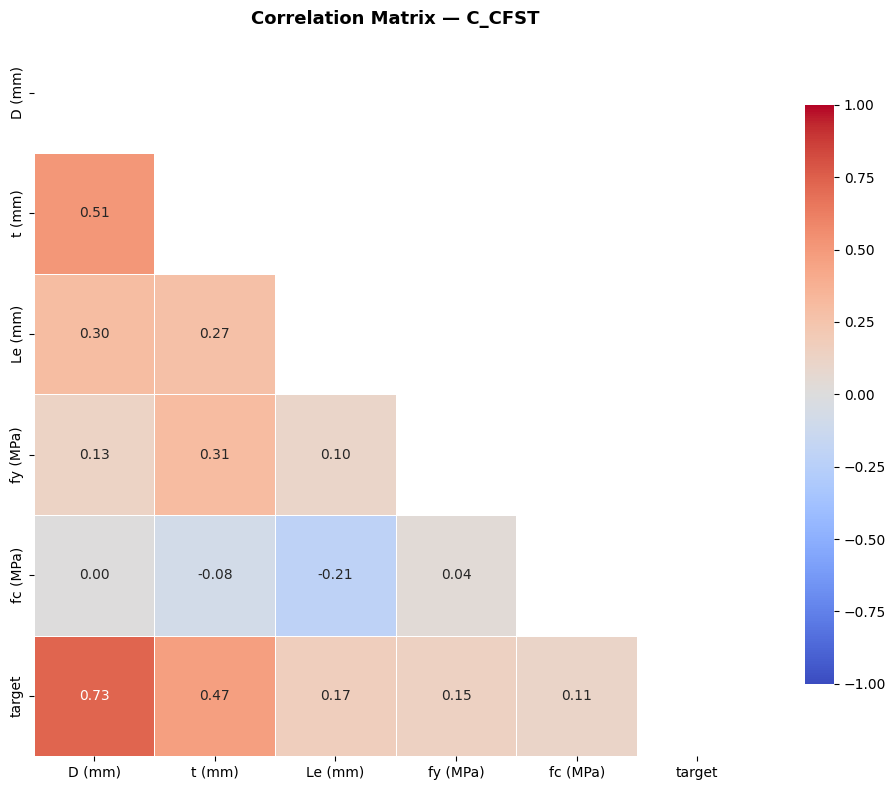


Correlation Analysis: C_CFST_BC

  Feature-Target Correlations:
  Feature                  Corr   |Corr|
  --------------------------------------
  D (mm)                  0.735    0.735
  t (mm)                  0.388    0.388
  fc (MPa)                0.376    0.376
  fy (MPa)                0.201    0.201
  et (mm)                 0.052    0.052
  Le (mm)                 0.040    0.040 low
  eb (mm)                 0.033    0.033 low

  Low correlation features (<0.05):
  ['Le (mm)', 'eb (mm)']
  → Consider dropping BUT verify with domain knowledge

  ✓ No multicollinearity detected


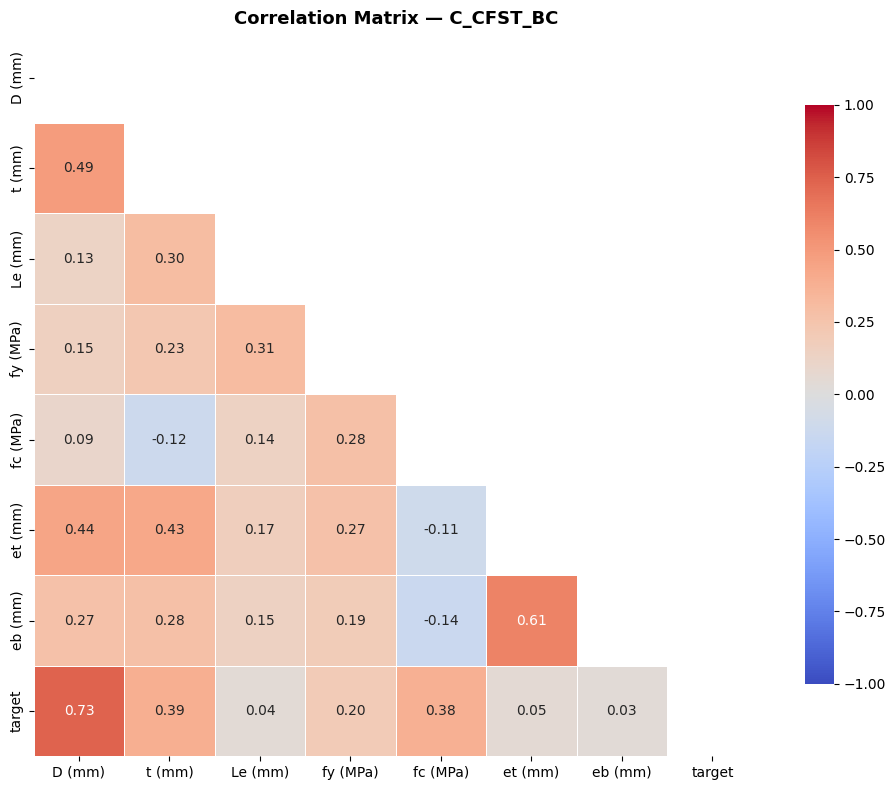

ValueError: could not convert string to float: 'Cyl'

In [ ]:

import seaborn as sns

def analyze_correlations(processed_data, threshold_low=0.05,
                          threshold_high=0.95):


    for sheet, data in processed_data.items():
        X = data['X']
        y = data['y']

        df_full = X.copy()
        df_full['target'] = y.values

        corr_matrix = df_full.corr()

        print(f"\n{'='*55}")
        print(f"Correlation Analysis: {sheet}")
        print(f"{'='*55}")

        target_corr = corr_matrix['target'].drop('target')
        target_corr_abs = target_corr.abs().sort_values(
            ascending=False)

        print(f"\n  Feature-Target Correlations:")
        print(f"  {'Feature':<20} {'Corr':>8} {'|Corr|':>8}")
        print(f"  {'-'*38}")
        for feat, val in target_corr.abs().sort_values(
                ascending=False).items():
            raw = target_corr[feat]
            flag = " low" if val < threshold_low else ""
            print(f"  {feat:<20} {raw:>8.3f} {val:>8.3f}{flag}")

        low_corr_feats = target_corr_abs[
            target_corr_abs < threshold_low
        ].index.tolist()

        if low_corr_feats:
            print(f"\n  Low correlation features (<{threshold_low}):")
            print(f"  {low_corr_feats}")
            print(f"  → Consider dropping BUT verify with domain knowledge")

        feat_corr = corr_matrix.drop('target', axis=0).drop(
            'target', axis=1)

        high_pairs = []
        for i in range(len(feat_corr.columns)):
            for j in range(i+1, len(feat_corr.columns)):
                val = abs(feat_corr.iloc[i, j])
                if val > threshold_high:
                    high_pairs.append((
                        feat_corr.columns[i],
                        feat_corr.columns[j],
                        round(val, 3)
                    ))

        if high_pairs:
            print(f"\n  High correlation pairs (>{threshold_high}):")
            for f1, f2, v in high_pairs:
                print(f"     {f1} ↔ {f2}: {v}")
        else:
            print(f"\n  ✓ No multicollinearity detected")

        plt.figure(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(
            corr_matrix, mask=mask,
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}
        )
        plt.title(f'Correlation Matrix — {sheet}',
                  fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'/content/corr_{sheet}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

analyze_correlations(processed_data)

### **Fixing**

**⚠️NOTE**

Low correlation does not imply low importance. Pearson correlation measures only linear relationships, whereas some features may influence the target through non-linear interactions that are captured by machine learning models.

## **Feature Engineering**

This code creates new, domain-relevant features from existing data, such as slenderness ratios and cross-sectional areas, to improve model performance.

In [ ]:


def add_engineering_features(processed_data):

    print("="*55)
    print("ADDING ENGINEERED FEATURES")
    print("="*55)

    for sheet, data in processed_data.items():
        X = data['X'].copy()
        added = []

        if 'D (mm)' in X.columns and 't (mm)' in X.columns:
            X['D_t_ratio'] = X['D (mm)'] / X['t (mm)']
            added.append('D_t_ratio (slenderness)')

        if 'Le (mm)' in X.columns and 'D (mm)' in X.columns:
            X['L_D_ratio'] = X['Le (mm)'] / X['D (mm)']
            added.append('L_D_ratio (global slenderness)')

        if 'D (mm)' in X.columns:
            X['area_approx'] = np.pi * (X['D (mm)'] / 2) ** 2
            added.append('area_approx (cross-section area)')

        if 'B (mm)' in X.columns and 't (mm)' in X.columns:
            X['B_t_ratio'] = X['B (mm)'] / X['t (mm)']
            added.append('B_t_ratio (slenderness)')

        if 'H (mm)' in X.columns and 't (mm)' in X.columns:
            X['H_t_ratio'] = X['H (mm)'] / X['t (mm)']
            added.append('H_t_ratio (slenderness)')

        if 'Le (mm)' in X.columns and 'B (mm)' in X.columns:
            X['L_B_ratio'] = X['Le (mm)'] / X['B (mm)']
            added.append('L_B_ratio (global slenderness)')

        if 'B (mm)' in X.columns and 'H (mm)' in X.columns:
            X['area_approx'] = X['B (mm)'] * X['H (mm)']
            added.append('area_approx (cross-section area)')

        if 'fy (MPa)' in X.columns and 'fc (MPa)' in X.columns:
            X['fy_fc_ratio'] = X['fy (MPa)'] / X['fc (MPa)']
            added.append('fy_fc_ratio (strength ratio)')

        if 'et (mm)' in X.columns and 'eb (mm)' in X.columns:
            X['e_avg'] = (X['et (mm)'] + X['eb (mm)']) / 2
            added.append('e_avg (average eccentricity)')

        processed_data[sheet]['X'] = X

        print(f"\n{sheet}:")
        print(f"  Features before: {len(data['X'].columns)}")
        print(f"  Features after:  {len(X.columns)}")
        for feat in added:
            print(f"    + {feat}")

    print("\n" + "="*55)
    print("Engineering features added to processed_data")
    print("="*55)

add_engineering_features(processed_data)

for sheet, data in processed_data.items():
    print(f"{sheet}: {list(data['X'].columns)}")

ADDING ENGINEERED FEATURES

C_CFST:
  Features before: 9
  Features after:  9
    + D_t_ratio (slenderness)
    + L_D_ratio (global slenderness)
    + area_approx (cross-section area)
    + fy_fc_ratio (strength ratio)

C_CFST_BC:
  Features before: 12
  Features after:  12
    + D_t_ratio (slenderness)
    + L_D_ratio (global slenderness)
    + area_approx (cross-section area)
    + fy_fc_ratio (strength ratio)
    + e_avg (average eccentricity)

R_CFST:
  Features before: 13
  Features after:  13
    + B_t_ratio (slenderness)
    + H_t_ratio (slenderness)
    + L_B_ratio (global slenderness)
    + area_approx (cross-section area)
    + fy_fc_ratio (strength ratio)

R_CFST_BC:
  Features before: 14
  Features after:  14
    + B_t_ratio (slenderness)
    + H_t_ratio (slenderness)
    + L_B_ratio (global slenderness)
    + area_approx (cross-section area)
    + fy_fc_ratio (strength ratio)
    + e_avg (average eccentricity)

Engineering features added to processed_data
C_CFST: ['D (mm)'

## **Data Transformation**

### **Data Info**

In [ ]:
for sheet, data in processed_data.items():

    X = data['X']

    print("\n" + "="*70)
    print(sheet)
    print("="*70)

    print("\nShape:")
    print(X.shape)

    print("\nData Types:")
    print(X.dtypes)

    print("\nUnique Values (categorical columns only):")
    for col in X.columns:
        if X[col].nunique() <= 10:
            try:
                print(f"{col}: {sorted(X[col].unique())}")
            except TypeError:
                print(f"{col}: {list(X[col].unique())}")

    print("\nNumerical Summary:")
    print(X.describe().T[['min', 'max', 'mean', 'std']])


C_CFST

Shape:
(1232, 9)

Data Types:
D (mm)         float64
t (mm)         float64
Le (mm)        float64
fy (MPa)       float64
fc (MPa)       float64
D_t_ratio      float64
L_D_ratio      float64
area_approx    float64
fy_fc_ratio    float64
dtype: object

Unique Values (categorical columns only):

Numerical Summary:
                   min        max       mean       std
D (mm)        3.816613   6.928538   4.935460  0.488256
t (mm)        0.418710   2.864484   1.579977  0.427769
Le (mm)       5.032718   8.623533   6.630841  0.794405
fy (MPa)      5.188949   6.749931   5.793752  0.234928
fc (MPa)      2.319365   5.269403   3.785730  0.515780
D_t_ratio     1.739019  11.022227   3.372338  1.130942
L_D_ratio     0.964147   1.856860   1.351756  0.178850
area_approx  11.440529  37.702753  19.318411  3.918087
fy_fc_ratio   1.103302   2.452245   1.558395  0.219261

C_CFST_BC

Shape:
(482, 12)

Data Types:
D (mm)         float64
t (mm)         float64
Le (mm)        float64
fy (MPa)       f

### **Encoding**

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler      = RobustScaler()
scaled_data = {}

for sheet, data in processed_data.items():
    X = data['X'].copy()
    y = data['y']

    #Encoding
    obj_cols = X.select_dtypes(include='object').columns.tolist()

    for col in obj_cols:
        unique_vals = X[col].dropna().unique()
        print(f"  {sheet} — encoding '{col}': {unique_vals}")

        if len(unique_vals) <= 2:
            X[col] = X[col].str.lower().str.contains(
                'cyl', na=False
            ).astype(int)
            print(f"    → Binary: Cyl=1, Cube=0")

        else:
            cat_col    = X[col].astype('category')
            cat_map    = dict(enumerate(cat_col.cat.categories))
            X[col]     = cat_col.cat.codes
            print(f"    → Label encoded: {cat_map}")

    #Scaling
    cols     = X.columns
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=cols,
        index=X.index
    )

    scaled_data[sheet] = {'X': X_scaled, 'y': y}
    print(f"✓ {sheet}: Shape={X_scaled.shape}")

print("\nSample (C_CFST):")
print(scaled_data['C_CFST']['X'].head())

✓ C_CFST: Shape=(1232, 9)
✓ C_CFST_BC: Shape=(482, 12)
  R_CFST — encoding 'fc type': ['Cyl' 'Cube' 'Cyl 100']
    → Label encoded: {0: 'Cube', 1: 'Cyl', 2: 'Cyl 100'}
✓ R_CFST: Shape=(736, 13)
✓ R_CFST_BC: Shape=(370, 14)

Sample (C_CFST):
     D (mm)    t (mm)   Le (mm)  fy (MPa)  fc (MPa)  D_t_ratio  L_D_ratio  \
0  0.588565 -0.678312 -0.640798 -0.246660 -1.173677   0.990254  -0.660542   
1  0.588565 -0.678312 -0.640798 -0.246660 -0.240842   0.990254  -0.660542   
2  0.594706 -0.690084 -0.640798  0.135260 -0.142987   1.009866  -0.662998   
3  0.594706 -0.690084 -0.640798  0.135260 -0.266334   1.009866  -0.662998   
4  0.582406 -0.178163 -0.640798 -0.408852 -0.606230   0.369067  -0.658075   

   area_approx  fy_fc_ratio  
0     0.596070     1.205787  
1     0.596070     0.126597  
2     0.602467     0.132990  
3     0.602467     0.251642  
4     0.589658     0.455850  


## **Save Steps**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib
import os
from sklearn.preprocessing import RobustScaler

SAVE_DIR = '/content/drive/MyDrive/Master/Final/Preprocessing'
os.makedirs(SAVE_DIR, exist_ok=True)

saved_processors = {}

for sheet, data in processed_data.items():
    X = data['X'].copy()

    obj_cols = X.select_dtypes(include='object').columns.tolist()
    for col in obj_cols:
        unique_vals = X[col].dropna().unique()
        if len(unique_vals) <= 2:
            X[col] = X[col].str.lower().str.contains(
                'cyl', na=False
            ).astype(int)
        else:
            cat_col = X[col].astype('category')
            X[col]  = cat_col.cat.codes

    scaler = RobustScaler()
    scaler.fit(X)

    saved_processors[sheet] = {
        'scaler':  scaler,
        'columns': X.columns.tolist(),
    }
    print(f"✓ {sheet}: {len(X.columns)} features saved")

joblib.dump(
    saved_processors,
    os.path.join(SAVE_DIR, 'preprocessing_artifacts.pkl')
)
print(f"\n Saved: {SAVE_DIR}/preprocessing_artifacts.pkl")

✓ C_CFST: 9 features saved
✓ C_CFST_BC: 12 features saved
✓ R_CFST: 13 features saved
✓ R_CFST_BC: 14 features saved

 Saved: /content/drive/MyDrive/Master/Final/Preprocessing/preprocessing_artifacts.pkl


# **Baseline Models**




## Evaluation Function

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_model(model, X, y, model_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {"Model": model_name, "RMSE": rmse, "R2": r2}

results = []

## **Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

for sheet, data in scaled_data.items():
    model = LinearRegression()
    res = evaluate_model(model, data['X'], data['y'], "Linear Regression")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Linear Regression: R2 = {res['R2']:.4f}")

[C_CFST] Linear Regression: R2 = 0.8504
[C_CFST_BC] Linear Regression: R2 = 0.8707
[R_CFST] Linear Regression: R2 = 0.8840
[R_CFST_BC] Linear Regression: R2 = 0.8097


## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

for sheet, data in scaled_data.items():
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "Random Forest")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Random Forest: R2 = {res['R2']:.4f}")

[C_CFST] Random Forest: R2 = 0.9868
[C_CFST_BC] Random Forest: R2 = 0.7724
[R_CFST] Random Forest: R2 = 0.9404
[R_CFST_BC] Random Forest: R2 = 0.9242


## **ْْXGBoost**

In [ ]:
from xgboost import XGBRegressor

for sheet, data in scaled_data.items():
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "XGBoost")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] XGBoost: R2 = {res['R2']:.4f}")

[C_CFST] XGBoost: R2 = 0.9944
[C_CFST_BC] XGBoost: R2 = 0.7903
[R_CFST] XGBoost: R2 = 0.9369
[R_CFST_BC] XGBoost: R2 = 0.9777


## **AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

for sheet, data in scaled_data.items():
    model = AdaBoostRegressor(n_estimators=100, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "AdaBoost")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] AdaBoost: R2 = {res['R2']:.4f}")

[C_CFST] AdaBoost: R2 = 0.8620
[C_CFST_BC] AdaBoost: R2 = 0.7589
[R_CFST] AdaBoost: R2 = 0.8527
[R_CFST_BC] AdaBoost: R2 = 0.7906


## **Voting Regressor**

In [ ]:
from sklearn.ensemble import VotingRegressor

for sheet, data in scaled_data.items():
    r1 = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model = VotingRegressor([('rf', r1), ('xgb', r2)])

    res = evaluate_model(model, data['X'], data['y'], "Voting (RF+XGB)")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Voting Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Voting Regressor: R2 = 0.9931
[C_CFST_BC] Voting Regressor: R2 = 0.7831
[R_CFST] Voting Regressor: R2 = 0.9416
[R_CFST_BC] Voting Regressor: R2 = 0.9676


## **Stacking Regressor**

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

for sheet, data in scaled_data.items():
    estimators = [('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
                  ('xgb', XGBRegressor(n_estimators=100, random_state=42))]
    model = StackingRegressor(estimators=estimators, final_estimator=Ridge())

    res = evaluate_model(model, data['X'], data['y'], "Stacking")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Stacking: R2 = {res['R2']:.4f}")

[C_CFST] Stacking: R2 = 0.9946
[C_CFST_BC] Stacking: R2 = 0.7948
[R_CFST] Stacking: R2 = 0.9478
[R_CFST_BC] Stacking: R2 = 0.9633


## **Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

for sheet, data in scaled_data.items():
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "Gradient Boosting")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Gradient Boosting: R2 = {res['R2']:.4f}")

[C_CFST] Gradient Boosting: R2 = 0.9909
[C_CFST_BC] Gradient Boosting: R2 = 0.8640
[R_CFST] Gradient Boosting: R2 = 0.9560
[R_CFST_BC] Gradient Boosting: R2 = 0.9477


## **Support Vector Regressor (SVR)**

In [ ]:
from sklearn.svm import SVR

for sheet, data in scaled_data.items():
    model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
    res = evaluate_model(model, data['X'], data['y'], "SVR (RBF)")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] SVR (RBF): R2 = {res['R2']:.4f}")

[C_CFST] SVR (RBF): R2 = 0.3556
[C_CFST_BC] SVR (RBF): R2 = 0.3660
[R_CFST] SVR (RBF): R2 = 0.6904
[R_CFST_BC] SVR (RBF): R2 = 0.7007


## **HistGradientBoostingRegressor**

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

for sheet, data in scaled_data.items():
    model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "HistGradientBoosting")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] HistGradientBoosting: R2 = {res['R2']:.4f}")

[C_CFST] HistGradientBoosting: R2 = 0.9848
[C_CFST_BC] HistGradientBoosting: R2 = 0.9513
[R_CFST] HistGradientBoosting: R2 = 0.9335
[R_CFST_BC] HistGradientBoosting: R2 = 0.8379


## **MLPRegressor**

In [ ]:
from sklearn.neural_network import MLPRegressor

for sheet, data in scaled_data.items():
    model = MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )

    res = evaluate_model(model, data['X'], data['y'], "MLP Regressor")
    res['Sheet'] = sheet
    results.append(res)

    print(f"[{sheet}] MLP Regressor: R2 = {res['R2']:.4f}")

[C_CFST] MLP Regressor: R2 = 0.8371
[C_CFST_BC] MLP Regressor: R2 = 0.9279
[R_CFST] MLP Regressor: R2 = 0.9414
[R_CFST_BC] MLP Regressor: R2 = 0.7959


## **K-Nearest Neighbors (KNN)**

In [ ]:

from sklearn.neighbors import KNeighborsRegressor

for sheet, data in scaled_data.items():
    model = KNeighborsRegressor(n_neighbors=5, weights='uniform')
    res = evaluate_model(model, data['X'], data['y'], "K-Nearest Neighbors")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] K-Nearest Neighbors: R2 = {res['R2']:.4f}")

[C_CFST] K-Nearest Neighbors: R2 = 0.9729
[C_CFST_BC] K-Nearest Neighbors: R2 = 0.9123
[R_CFST] K-Nearest Neighbors: R2 = 0.9313
[R_CFST_BC] K-Nearest Neighbors: R2 = 0.8528


## **Lasso Regression**


In [ ]:
from sklearn.linear_model import Lasso

for sheet, data in scaled_data.items():
    model = Lasso(alpha=1.0, random_state=42, max_iter=10000)
    res = evaluate_model(model, data['X'], data['y'], "Lasso Regression")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Lasso Regression: R2 = {res['R2']:.4f}")

[C_CFST] Lasso Regression: R2 = 0.8519
[C_CFST_BC] Lasso Regression: R2 = 0.8522
[R_CFST] Lasso Regression: R2 = 0.8843
[R_CFST_BC] Lasso Regression: R2 = 0.8056


## **Ridge Regression**


In [ ]:
from sklearn.linear_model import Ridge

for sheet, data in scaled_data.items():
    model = Ridge(alpha=1.0, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "Ridge Regression")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Ridge Regression: R2 = {res['R2']:.4f}")

[C_CFST] Ridge Regression: R2 = 0.8483
[C_CFST_BC] Ridge Regression: R2 = 0.8104
[R_CFST] Ridge Regression: R2 = 0.8843
[R_CFST_BC] Ridge Regression: R2 = 0.8048


## **ElasticNet**


In [ ]:
from sklearn.linear_model import ElasticNet

for sheet, data in scaled_data.items():
    model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000)
    res = evaluate_model(model, data['X'], data['y'], "ElasticNet")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] ElasticNet: R2 = {res['R2']:.4f}")

[C_CFST] ElasticNet: R2 = 0.5569
[C_CFST_BC] ElasticNet: R2 = 0.6079
[R_CFST] ElasticNet: R2 = 0.8381
[R_CFST_BC] ElasticNet: R2 = 0.7523


## **SGD Regressor**


In [ ]:
from sklearn.linear_model import SGDRegressor

for sheet, data in scaled_data.items():
    model = SGDRegressor(max_iter=10000, tol=1e-3, random_state=42, penalty='l2')
    res = evaluate_model(model, data['X'], data['y'], "SGD Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] SGD Regressor: R2 = {res['R2']:.4f}")

[C_CFST] SGD Regressor: R2 = 0.8346
[C_CFST_BC] SGD Regressor: R2 = 0.7635
[R_CFST] SGD Regressor: R2 = 0.8852
[R_CFST_BC] SGD Regressor: R2 = 0.7985


## **Decision Tree**


In [ ]:
from sklearn.tree import DecisionTreeRegressor

for sheet, data in scaled_data.items():
    model = DecisionTreeRegressor(max_depth=10, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "Decision Tree")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Decision Tree: R2 = {res['R2']:.4f}")

[C_CFST] Decision Tree: R2 = 0.9734
[C_CFST_BC] Decision Tree: R2 = 0.7103
[R_CFST] Decision Tree: R2 = 0.9290
[R_CFST_BC] Decision Tree: R2 = 0.4892


## **ExtraTrees Regressor**


In [ ]:


from sklearn.ensemble import ExtraTreesRegressor

for sheet, data in scaled_data.items():
    model = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    res = evaluate_model(model, data['X'], data['y'], "ExtraTrees Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] ExtraTrees Regressor: R2 = {res['R2']:.4f}")


[C_CFST] ExtraTrees Regressor: R2 = 0.9938
[C_CFST_BC] ExtraTrees Regressor: R2 = 0.9257
[R_CFST] ExtraTrees Regressor: R2 = 0.9711
[R_CFST_BC] ExtraTrees Regressor: R2 = 0.9680


## **Bagging Regressor**


In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

for sheet, data in scaled_data.items():
    base_estimator = DecisionTreeRegressor(max_depth=10, random_state=42)
    model = BaggingRegressor(estimator=base_estimator, n_estimators=100, random_state=42, n_jobs=-1)
    res = evaluate_model(model, data['X'], data['y'], "Bagging Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Bagging Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Bagging Regressor: R2 = 0.9867
[C_CFST_BC] Bagging Regressor: R2 = 0.7701
[R_CFST] Bagging Regressor: R2 = 0.9382
[R_CFST_BC] Bagging Regressor: R2 = 0.9164


## **Huber Regressor**


In [ ]:

from sklearn.linear_model import HuberRegressor

for sheet, data in scaled_data.items():
    model = HuberRegressor(epsilon=1.35, max_iter=10000)
    res = evaluate_model(model, data['X'], data['y'], "Huber Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Huber Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Huber Regressor: R2 = 0.8316
[C_CFST_BC] Huber Regressor: R2 = 0.6934
[R_CFST] Huber Regressor: R2 = 0.8836
[R_CFST_BC] Huber Regressor: R2 = 0.8410


## **Theil-Sen Regressor**


In [ ]:
from sklearn.linear_model import TheilSenRegressor

for sheet, data in scaled_data.items():
    model = TheilSenRegressor(random_state=42, n_jobs=-1, max_subpopulation=10000)
    res = evaluate_model(model, data['X'], data['y'], "Theil-Sen Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Theil-Sen Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Theil-Sen Regressor: R2 = 0.7956
[C_CFST_BC] Theil-Sen Regressor: R2 = 0.6882
[R_CFST] Theil-Sen Regressor: R2 = 0.8617
[R_CFST_BC] Theil-Sen Regressor: R2 = 0.8550


## **Poisson Regressor**


In [ ]:
from sklearn.linear_model import PoissonRegressor

for sheet, data in scaled_data.items():
    model = PoissonRegressor(max_iter=10000, alpha=1.0)
    res = evaluate_model(model, data['X'], data['y'], "Poisson Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Poisson Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Poisson Regressor: R2 = 0.9844
[C_CFST_BC] Poisson Regressor: R2 = 0.9004
[R_CFST] Poisson Regressor: R2 = 0.9591
[R_CFST_BC] Poisson Regressor: R2 = 0.7036


## **Categorical Boosting (CatBoost)**


In [ ]:
!pip install catboost -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [ ]:


from catboost import CatBoostRegressor

for sheet, data in scaled_data.items():
    model = CatBoostRegressor(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=False
    )
    res = evaluate_model(model, data['X'], data['y'], "Categorical Boosting")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Categorical Boosting (CatBoost): R2 = {res['R2']:.4f}")

[C_CFST] Categorical Boosting (CatBoost): R2 = 0.9921
[C_CFST_BC] Categorical Boosting (CatBoost): R2 = 0.7831
[R_CFST] Categorical Boosting (CatBoost): R2 = 0.9653
[R_CFST_BC] Categorical Boosting (CatBoost): R2 = 0.9474


## **ِALL RESULTS**

In [ ]:
df_results = pd.DataFrame(results)
print(df_results.sort_values(by=['Sheet', 'R2'], ascending=[True, False]))


                   Model        RMSE        R2      Sheet
20              Stacking  232.542762  0.994564     C_CFST
8                XGBoost  235.728885  0.994414     C_CFST
64  ExtraTrees Regressor  247.443526  0.993845     C_CFST
16       Voting (RF+XGB)  262.501518  0.993073     C_CFST
84  Categorical Boosting  279.593657  0.992141     C_CFST
..                   ...         ...       ...        ...
15              AdaBoost  378.894362  0.790612  R_CFST_BC
55            ElasticNet  412.112227  0.752288  R_CFST_BC
83     Poisson Regressor  450.771307  0.703634  R_CFST_BC
31             SVR (RBF)  453.014699  0.700677  R_CFST_BC
63         Decision Tree  591.814910  0.489156  R_CFST_BC

[88 rows x 4 columns]


In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)

print("\n" + "="*75)
print(" " * 20 + "BASELINE MODELS RESULTS")
print("="*75)

for sheet in sorted(df_results['Sheet'].unique()):
    sheet_df = df_results[df_results['Sheet'] == sheet].copy()
    sheet_df = sheet_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

    sheet_df['Rank'] = range(1, len(sheet_df) + 1)

    print(f"\n{'─'*75}")
    print(f"    {sheet}")
    print(f"{'─'*75}")

    print(f"{'Rank':<6} {'Model':<28} {'R²':>12} {'RMSE':>12}")
    print(f"{'─'*6} {'─'*28} {'─'*12} {'─'*12}")

    for _, row in sheet_df.iterrows():
        rank = int(row['Rank'])
        model = row['Model'][:27]
        r2 = row['R2']
        rmse = row['RMSE']

        if rank == 1:
            prefix = "🥇"
        elif rank == 2:
            prefix = "🥈"
        elif rank == 3:
            prefix = "🥉"
        else:
            prefix = "  "

        print(f"{prefix} {rank:<3} {model:<28} {r2:>12.6f} {rmse:>12.2f}")

    print(f"{'─'*75}")
    print(f"  Best Model: {sheet_df.iloc[0]['Model']} (R² = {sheet_df.iloc[0]['R2']:.6f})")

print("\n" + "="*75)


                    BASELINE MODELS RESULTS

───────────────────────────────────────────────────────────────────────────
    C_CFST
───────────────────────────────────────────────────────────────────────────
Rank   Model                                  R²         RMSE
────── ──────────────────────────── ──────────── ────────────
🥇 1   Stacking                         0.994564       232.54
🥈 2   XGBoost                          0.994414       235.73
🥉 3   ExtraTrees Regressor             0.993845       247.44
   4   Voting (RF+XGB)                  0.993073       262.50
   5   Categorical Boosting             0.992141       279.59
   6   Gradient Boosting                0.990866       301.43
   7   Random Forest                    0.986817       362.12
   8   Bagging Regressor                0.986728       363.35
   9   HistGradientBoosting             0.984756       389.40
   10  Poisson Regressor                0.984438       393.44
   11  Decision Tree                    0.973386  

| Model                | C_CFST (R²) | C_CFST_BC (R²) | R_CFST (R²) | R_CFST_BC (R²) |
| -------------------- | ----------: | -------------: | ----------: | -------------: |
| Stacking             |    0.994592 |       0.794779 |    0.960037 |       0.963273 |
| XGBoost              |    0.994195 |       0.790305 |    0.957093 |       0.977673 |
| ExtraTrees Regressor |    0.993845 |       0.925655 |    0.967409 |       0.968041 |
| Voting (RF+XGB)      |    0.993049 |       0.783051 |    0.949711 |       0.967620 |
| Categorical Boosting |    0.992141 |       0.783121 |    0.953603 |       0.947430 |
| Gradient Boosting    |    0.990866 |       0.863954 |    0.941657 |       0.947682 |
| Random Forest        |    0.986817 |       0.772375 |    0.930540 |       0.924180 |
| Bagging Regressor    |    0.986728 |       0.770125 |    0.930137 |       0.916355 |
| HistGradientBoosting |    0.984756 |       0.951256 |    0.950261 |       0.837870 |
| Poisson Regressor    |    0.984438 |       0.900360 |    0.931487 |       0.703635 |
| Decision Tree        |    0.973386 |       0.710253 |    0.916211 |       0.489156 |
| K-Nearest Neighbors  |    0.972935 |       0.912311 |    0.900530 |       0.852805 |
| AdaBoost             |    0.861960 |       0.758907 |    0.855037 |       0.790612 |
| Lasso Regression     |    0.851887 |       0.852199 |    0.861713 |       0.805608 |
| Linear Regression    |    0.850392 |       0.870703 |    0.862536 |       0.809691 |
| Ridge Regression     |    0.848327 |       0.810388 |    0.861787 |       0.804778 |
| MLP Regressor        |    0.837144 |       0.927920 |    0.917425 |       0.795944 |
| SGD Regressor        |    0.834624 |       0.763539 |    0.854656 |       0.798486 |
| Huber Regressor      |    0.831637 |       0.693447 |    0.852563 |       0.841042 |
| Theil-Sen Regressor  |    0.795615 |       0.688174 |    0.842259 |       0.854956 |
| ElasticNet           |    0.556896 |       0.607906 |    0.838707 |       0.752288 |
| SVR (RBF)            |    0.355626 |       0.365951 |    0.672417 |       0.700677 |


# **ACTUAL TRAINING**

## **Sheet 1) C_CFST**


*   XGBoost
*   Stacking (XGboost +RF)



### **setup**

In [ ]:

!pip install optuna -q

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'C_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.9 MB/s eta 0:00:00
Dataset: C_CFST
Samples: 1232  Features: 9


### **Model 1: XGBoost + Nested CV + Optuna**

In [ ]:

def run_xgb_nested_cv(X, y, label='XGBoost'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 1200),
                    'learning_rate':trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                    'max_depth':trial.suggest_int('max_depth', 3, 12),
                    'subsample':trial.suggest_float('subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    'reg_alpha':trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                    'reg_lambda':trial.suggest_float('reg_lambda', 1e-8, 10.0,log=True),
                    'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                    'gamma': trial.suggest_float('gamma', 1e-8, 1.0,log=True),
                    'random_state': RANDOM_STATE, 'n_jobs': -1
                }
                m = xgb.XGBRegressor(**p, verbosity=0)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )

            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })
        model = xgb.XGBRegressor(**best_params, verbosity=0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }


### **Model 2: Stacking (RF + Tuned XGBoost) + Nested CV**

In [ ]:

def run_stacking_nested_cv(X, y, xgb_best_params,
                            label='Stacking'):

    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_rf_params = None
        best_score     = -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def rf_objective(trial):
                p = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                    'max_depth': trial.suggest_int('max_depth', 5, 20),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                    'max_features': trial.suggest_float('max_features', 0.3, 1.0),
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1
                }

                rf = RandomForestRegressor(**p)
                rf.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, rf.predict(X_in_val))

            study_rf = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study_rf.optimize(rf_objective,
                              n_trials=N_TRIALS // 2,
                              show_progress_bar=False)

            if study_rf.best_value > best_score:
                best_score     = study_rf.best_value
                best_rf_params = study_rf.best_params

        best_rf_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })

        estimators = [
            ('rf',  RandomForestRegressor(**best_rf_params)),
            ('xgb', xgb.XGBRegressor(
                **xgb_best_params, verbosity=0)),
        ]
        stack = StackingRegressor(
            estimators      = estimators,
            final_estimator = Ridge(alpha=1.0),
            cv              = 3,
            n_jobs          = -1,
        )
        stack.fit(X_tr, y_tr)
        y_pred = stack.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}")

    print(f"\n  {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':     label,
        'R2_Mean':   round(np.mean(outer_r2),   4),
        'R2_Std':    round(np.std(outer_r2),    4),
        'RMSE_Mean': round(np.mean(outer_rmse), 2),
        'RMSE_Std':  round(np.std(outer_rmse),  2),
        'MAE':       round(np.mean(outer_mae),  2),
        'MAPE':      round(np.mean(outer_mape), 2),
    }

### **Execution**

In [ ]:
print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

xgb_result = run_xgb_nested_cv(X, y, label='XGBoost')

stack_result = run_stacking_nested_cv(
    X, y,
    xgb_best_params = xgb_result['best_params'],
    label           = 'Stacking (RF + XGB)'
)


#######################################################
# SHEET: C_CFST
#######################################################

XGBoost — Nested CV
  Fold 1: R²=0.9952  RMSE=217.5  depth=6
  Fold 2: R²=0.9669  RMSE=1039.1  depth=4
  Fold 3: R²=0.9965  RMSE=183.4  depth=4
  Fold 4: R²=0.9925  RMSE=357.9  depth=7
  Fold 5: R²=0.9927  RMSE=300.9  depth=4

 XGBoost:
    R²   = 0.9888 ± 0.0110
    RMSE = 419.75 ± 315.70
    MAE  = 145.18
    MAPE = 7.77%

Stacking (RF + XGB) — Nested CV
  Fold 1: R²=0.8895  RMSE=1048.4
  Fold 2: R²=0.9508  RMSE=1268.1
  Fold 3: R²=0.9357  RMSE=785.1
  Fold 4: R²=0.8922  RMSE=1359.7
  Fold 5: R²=0.8950  RMSE=1139.3

  Stacking (RF + XGB):
    R²   = 0.9126 ± 0.0255
    RMSE = 1120.15 ± 198.50
    MAE  = 505.91
    MAPE = 42.58%


### **RESULTS**

In [ ]:

print(f"\n{'='*60}")
print(f"FINAL COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)

for res in [xgb_result, stack_result]:
    print(f"{res['model']:<22} "
          f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
          f"{res['RMSE_Mean']:>8.1f} "
          f"{res['MAE']:>8.1f} "
          f"{res['MAPE']:>7.2f}%")

print("="*60)

winner = (xgb_result if xgb_result['R2_Mean'] >=
          stack_result['R2_Mean'] else stack_result)
print(f"\n Winner for {SHEET}: {winner['model']} "
      f"(R²={winner['R2_Mean']:.4f})")


FINAL COMPARISON — C_CFST
Model                            R²               RMSE      MAE   MAPE%
------------------------------------------------------------
XGBoost                0.9888 ± 0.0110     419.8    145.2    7.77%
Stacking (RF + XGB)    0.9126 ± 0.0255    1120.2    505.9   42.58%

 Winner for C_CFST: XGBoost (R²=0.9888)


### **Save**

In [ ]:
import joblib
import json
import os
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n{'='*55}\nSaved in {BASE_DIR}\n{'='*55}")

scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved: {scaler_path}")



xgb_final = xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0)
xgb_final.fit(X, y)
joblib.dump(xgb_final, os.path.join(BASE_DIR, 'XGBoost_NestedCV.pkl'))
print(f"XGBoost final model saved.")


rf_best_params = {'n_estimators': 300, 'max_depth': 10, 'random_state': RANDOM_STATE}
stack_final = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(**rf_best_params, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0))
    ],
    final_estimator=Ridge(),
    cv=3, n_jobs=-1
)
stack_final.fit(X, y)
joblib.dump(stack_final, os.path.join(BASE_DIR, 'Stacking_NestedCV.pkl'))
print(f"Stacking final model saved.")

all_results = {
    "XGBoost": xgb_result,
    "Stacking": stack_result
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)

print(f"\nSaved Successfully")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Saved in /content/drive/MyDrive/Master/Final/C_CFST
Scaler saved: /content/drive/MyDrive/Master/Final/C_CFST/scaler.pkl
XGBoost final model saved.
Stacking final model saved.

Saved Successfully


### **Train/Test split 70/30**

In [ ]:
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb

SHEET = 'C_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} ,Test: {X_test.shape[0]}.")

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("Saved")

model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")

joblib.dump(model, os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl'))
print(f"\nModel Saved {BASE_DIR}")

Train: 985 ,Test: 247.
Saved
R² Score : 0.9927
RMSE     : 269.69

Model Saved /content/drive/MyDrive/Master/Final/C_CFST


#### **Feature Importance**

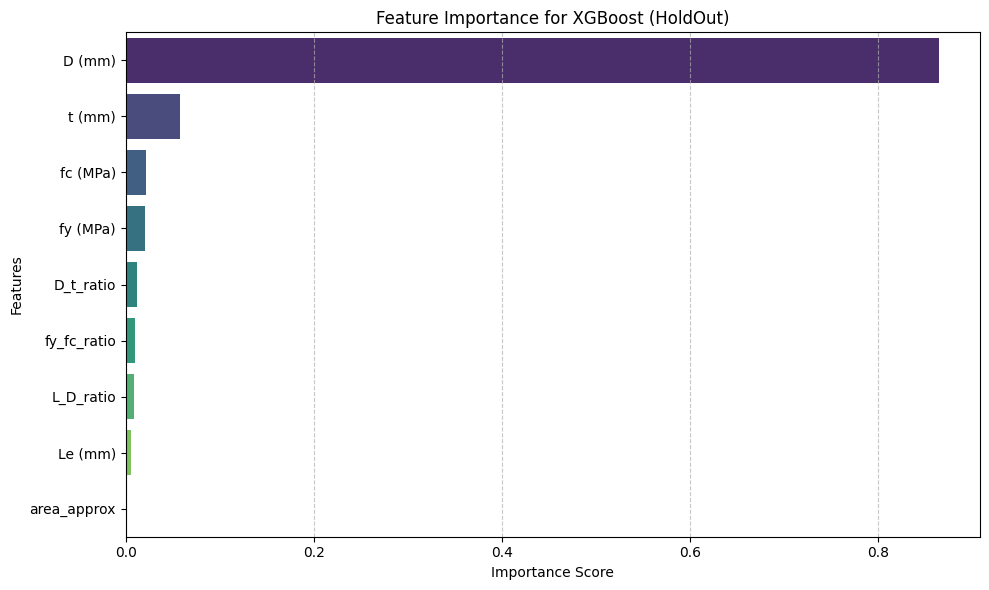

       Feature  Importance
0       D (mm)    0.864954
1       t (mm)    0.057538
4     fc (MPa)    0.021811
3     fy (MPa)    0.020613
5    D_t_ratio    0.011428
8  fy_fc_ratio    0.009591
6    L_D_ratio    0.008453
2      Le (mm)    0.005611
7  area_approx    0.000000


In [ ]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = '/content/drive/MyDrive/Master/Final/C_CFST'
model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')

loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

if hasattr(loaded_scaler, 'feature_names_in_'):
    feature_names = loaded_scaler.feature_names_in_
else:
    feature_names = [f"Feature_{i}" for i in range(len(loaded_model.feature_importances_))]

importances = loaded_model.feature_importances_
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance for XGBoost (HoldOut)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(df_imp)

#### **SHAP analysis**

**How to Read SHAP Plots** 📊

Vertical Axis (Y): Features are ranked by importance (top = most influential). 🥇

Horizontal Axis (X): Shows the impact on the model's output.

Right of the center line: Positive impact (increases output). 📈

Left of the center line: Negative impact (decreases output). 📉

**Color Scale:**

Red dots (High): Represent high feature values. 🔴

Blue dots (Low): Represent low feature values. 🔵

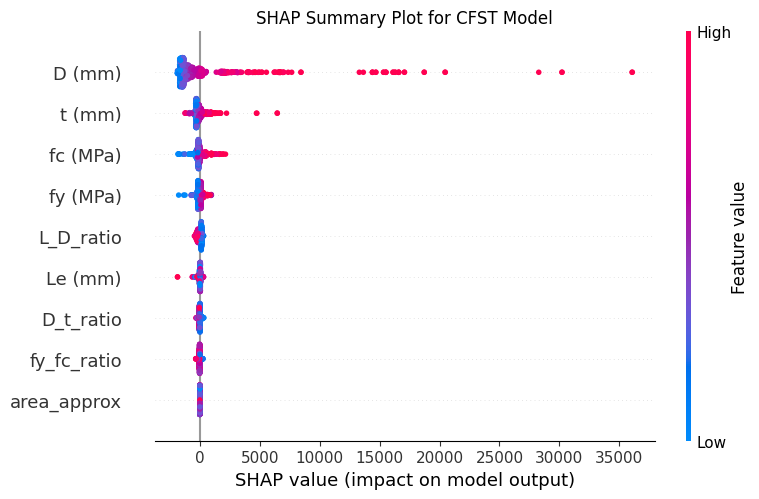

In [ ]:
import shap
import joblib
import os
import matplotlib.pyplot as plt

model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
model = joblib.load(model_path)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_scaled)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_scaled, feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot for CFST Model")
plt.tight_layout()
plt.show()

"To enhance the interpretability of the XGBoost model, SHAP (SHapley Additive exPlanations) values were analyzed. As shown in the summary plot, the diameter ($D$) is the most influential feature on the model's output, exhibiting a strong positive correlation with the load-carrying capacity of the CFST columns. Features such as wall thickness ($t$), concrete compressive strength ($f_c$), and steel yield strength ($f_y$) show a moderate positive impact, which aligns with structural engineering principles. Conversely, slenderness-related parameters ($L/D$, $Le$) demonstrate a negligible influence on the model predictions within the current dataset range, suggesting that the model's predictive capability is primarily driven by the cross-sectional geometry rather than the column height for this specific dataset."

## **Sheet 2) C_CFST_BC**


*   HistGradientBoosting
*   MLP



### **setup**

In [ ]:

!pip install optuna -q

import optuna
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib, json, os
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET          = 'C_CFST_BC'
RANDOM_STATE   = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")


Dataset: C_CFST_BC
Samples: 482  Features: 12


### **Model 1: HistGradientBoosting + Nested CV + Optuna**

In [ ]:


def run_hgb_nested_cv(X, y, label='HistGradientBoosting'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'max_iter':trial.suggest_int( 'max_iter', 100, 1000),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3,log=True),
                    'max_depth':trial.suggest_int('max_depth', 3, 15),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
                    'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0,log=True),
                    'max_bins':trial.suggest_int('max_bins', 64, 255),
                    'random_state': RANDOM_STATE,
                }

                m = HistGradientBoostingRegressor(**p)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )

            study.optimize(objective, n_trials=N_TRIALS,show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params['random_state'] = RANDOM_STATE
        model = HistGradientBoostingRegressor(**best_params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

### **Model 2: MLP + Nested CV + Optuna**

In [ ]:

def build_mlp(params):
    n_layers = params.get('n_layers', 2)
    layers   = tuple(
        params.get(f'units_{i}', 64)
        for i in range(n_layers)
    )
    # MLP without scaler - scaler will be handled separately
    return MLPRegressor(
        hidden_layer_sizes  = layers,
        activation          = params.get('activation', 'relu'),
        alpha               = params.get('alpha', 0.001),
        learning_rate_init  = params.get('lr_init', 0.001),
        batch_size          = params.get('batch_size', 32),
        max_iter            = 1000,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 20,
        random_state        = RANDOM_STATE,
    )

def run_mlp_nested_cv(X, y, label='MLP'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv = KFold(n_splits=N_SPLITS_INNER,shuffle=True,random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            # Scale data separately for inner CV
            scaler_inner = StandardScaler()
            X_in_tr_scaled = scaler_inner.fit_transform(X_in_tr)
            X_in_val_scaled = scaler_inner.transform(X_in_val)

            def objective(trial):
                p = {
                    'n_layers':trial.suggest_int('n_layers', 1, 4),
                    'activation': trial.suggest_categorical('activation',['relu', 'tanh']),
                    'alpha': trial.suggest_float('alpha', 1e-6, 0.1,log=True),
                    'lr_init':trial.suggest_float('lr_init', 1e-4, 0.05, log=True),
                    'batch_size': trial.suggest_categorical(
                                      'batch_size',
                                      [16, 32, 64, 128]),
                }
                for i in range(p['n_layers']):
                    p[f'units_{i}'] = trial.suggest_int(
                        f'units_{i}', 32, 256)
                m = build_mlp(p)
                m.fit(X_in_tr_scaled, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val_scaled))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        # Scale data for outer fold
        scaler_outer = StandardScaler()
        X_tr_scaled = scaler_outer.fit_transform(X_tr)
        X_te_scaled = scaler_outer.transform(X_te)

        final_model = build_mlp(best_params)
        final_model.fit(X_tr_scaled, y_tr)
        y_pred = final_model.predict(X_te_scaled)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        arch = [best_params.get(f'units_{i}', 64)
                for i in range(best_params.get('n_layers', 2))]
        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"arch={arch}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }



### **Execution**

In [ ]:

print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

hgb_result = run_hgb_nested_cv(X, y, label='HistGradientBoosting')
mlp_result = run_mlp_nested_cv(X, y, label='MLP')




#######################################################
# SHEET: C_CFST_BC
#######################################################

HistGradientBoosting — Nested CV
  Fold 1: R²=0.9316  RMSE=249.3  depth=11
  Fold 2: R²=0.8633  RMSE=272.9  depth=11
  Fold 3: R²=0.8646  RMSE=264.6  depth=8
  Fold 4: R²=0.9528  RMSE=172.1  depth=5
  Fold 5: R²=0.9884  RMSE=86.6  depth=5

  ✓ HistGradientBoosting:
    R²   = 0.9201 ± 0.0493
    RMSE = 209.09 ± 70.91
    MAE  = 93.92
    MAPE = 14.37%

MLP — Nested CV
  Fold 1: R²=0.9864  RMSE=111.2  arch=[90, 181, 102, 149]
  Fold 2: R²=0.9862  RMSE=86.8  arch=[137, 136, 164, 33]
  Fold 3: R²=0.9811  RMSE=99.0  arch=[135, 104, 61, 68]
  Fold 4: R²=0.9280  RMSE=212.4  arch=[87, 236, 154, 212]
  Fold 5: R²=0.9741  RMSE=129.6  arch=[65, 165, 122, 74]

  ✓ MLP:
    R²   = 0.9712 ± 0.0220
    RMSE = 127.78 ± 44.61
    MAE  = 70.77
    MAPE = 11.99%


### **Results**

In [ ]:

print(f"\n{'='*60}")
print(f"FINAL COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<25} {'R²':^22} {'RMSE':>8} "
      f"{'MAE':>8} {'MAPE%':>7}")
print("-"*60)

for res in [hgb_result, mlp_result]:
    print(f"{res['model']:<25} "
          f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
          f"{res['RMSE_Mean']:>8.1f} "
          f"{res['MAE']:>8.1f} "
          f"{res['MAPE']:>7.2f}%")

print("="*60)

winner = (hgb_result if hgb_result['R2_Mean'] >=
          mlp_result['R2_Mean'] else mlp_result)
print(f"\n✓ Winner for {SHEET}: {winner['model']} "
      f"(R²={winner['R2_Mean']:.4f})")



FINAL COMPARISON — C_CFST_BC
Model                               R²               RMSE      MAE   MAPE%
------------------------------------------------------------
HistGradientBoosting      0.9201 ± 0.0493     209.1     93.9   14.37%
MLP                       0.9712 ± 0.0220     127.8     70.8   11.99%

✓ Winner for C_CFST_BC: MLP (R²=0.9712)


### **Save**

In [ ]:

from google.colab import drive
drive.mount('/content/drive') if not os.path.exists(
    '/content/drive/MyDrive') else None

BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)


hgb_final = HistGradientBoostingRegressor(
    **hgb_result['best_params'])
hgb_final.fit(X, y)
joblib.dump(hgb_final,
            os.path.join(BASE_DIR,
                         'HistGradientBoosting_NestedCV.pkl'))
print(f"HGB model saved")


# MLP: fit on scaled data, save scaler separately
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

mlp_final = build_mlp(mlp_result['best_params'])
mlp_final.fit(X_scaled, y)

joblib.dump(scaler_final, os.path.join(BASE_DIR, 'scaler.pkl'))
print(f"Scaler saved")

joblib.dump(mlp_final,
            os.path.join(BASE_DIR, 'MLP_NestedCV.pkl'))
print(f"MLP model saved")


all_results = {
    'HistGradientBoosting': hgb_result,
    'MLP':                  mlp_result,
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)
print(f"Results saved")



HGB model saved
Scaler saved
MLP model saved
Results saved


In [ ]:
# فقط للشيت الثاني - تأكدي أنكِ في المسار الصحيح
BASE_DIR = '/content/drive/MyDrive/Master/Final/C_CFST_BC'

# تحميل البيانات الأصلية لهذا الشيت
X = processed_data['C_CFST_BC']['X']

# إنشاء سكيلر جديد تماماً ومطابق لهذه الأعمدة فقط
new_scaler = StandardScaler()
X_scaled = pd.DataFrame(new_scaler.fit_transform(X), columns=X.columns)

# حفظه في المجلد الخاص به
joblib.dump(new_scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("تم حفظ سكيلر جديد خاص بالشيت الثاني فقط.")

تم حفظ سكيلر جديد خاص بالشيت الثاني فقط.


### **Train/Test split 70/30**

In [ ]:

import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


SHEET = 'C_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)


X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Train: {X_train.shape[0]} Test: {X_test.shape[0]}")

# Scaler is SEPARATE from the model (same as Sheet 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("Scaler saved")

best_p = mlp_result['best_params']

n_layers = best_p.get('n_layers', 2)
layers = tuple(best_p.get(f'units_{i}', 64) for i in range(n_layers))

# MLP model WITHOUT scaler in pipeline (same as Sheet 1)
mlp_model = MLPRegressor(
    hidden_layer_sizes=layers,
    activation=best_p.get('activation', 'relu'),
    alpha=best_p.get('alpha', 0.001),
    learning_rate_init=best_p.get('lr_init', 0.001),
    batch_size=best_p.get('batch_size', 32),
    max_iter=1000,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

y_pred = mlp_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")

joblib.dump(mlp_model, os.path.join(BASE_DIR, 'MLP_HoldOut.pkl'))
print(f"\nModel Saved {BASE_DIR}")


Train: 337 Test: 145
Scaler saved
R² Score : 0.9885
RMSE     : 99.38
MAE      : 58.53

Model Saved /content/drive/MyDrive/Master/Final/C_CFST_BC


### **Feature Importance (Permutation Importance)**

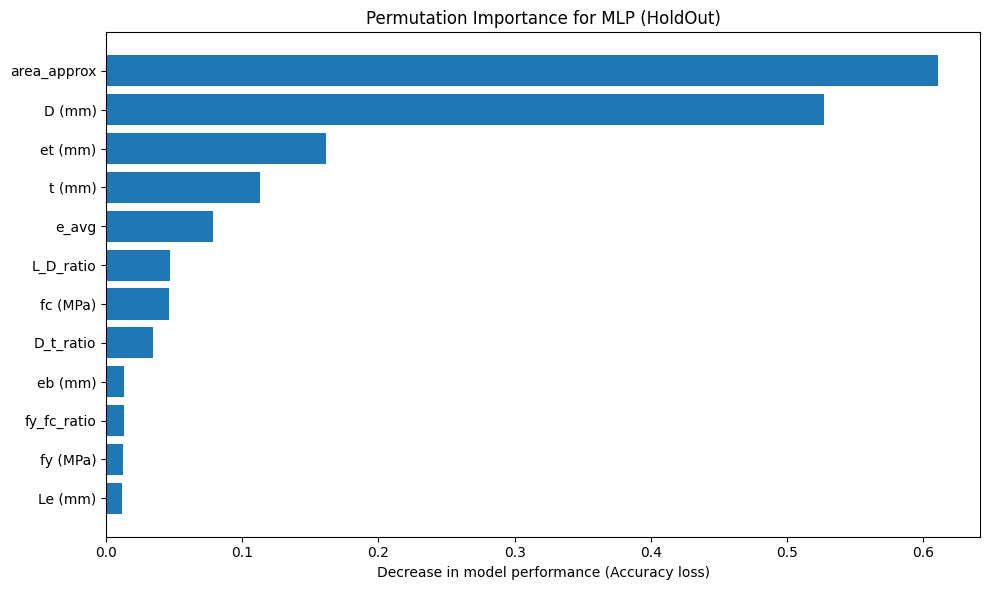

In [ ]:

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import os


SHEET = 'C_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
model_path = os.path.join(BASE_DIR, 'MLP_HoldOut.pkl')
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')


model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

X_test_scaled = scaler.transform(X_test)

perm_importance = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = perm_importance.importances_mean.argsort()
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), perm_importance.importances_mean[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title("Permutation Importance for MLP (HoldOut)")
plt.xlabel("Decrease in model performance (Accuracy loss)")
plt.tight_layout()
plt.show()

### **SHAP Analysis**

**How to Read SHAP Plots** 📊
Vertical Axis (Y): Features are ranked by importance (top = most influential). 🥇

Horizontal Axis (X): Shows the impact on the model's output.

Right of the center line: Positive impact (increases output). 📈

Left of the center line: Negative impact (decreases output). 📉

**Color Scale:**

Red dots (High): Represent high feature values. 🔴

Blue dots (Low): Represent low feature values. 🔵

  0%|          | 0/50 [00:00<?, ?it/s]

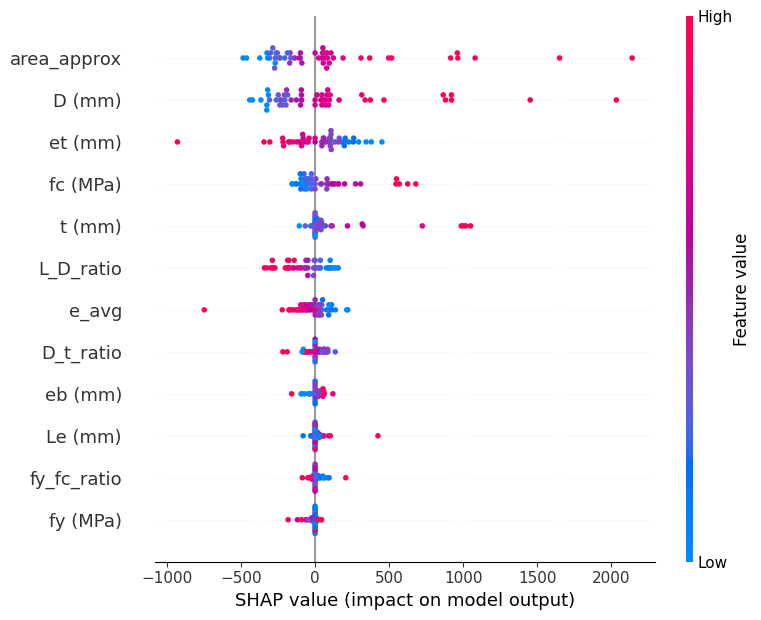

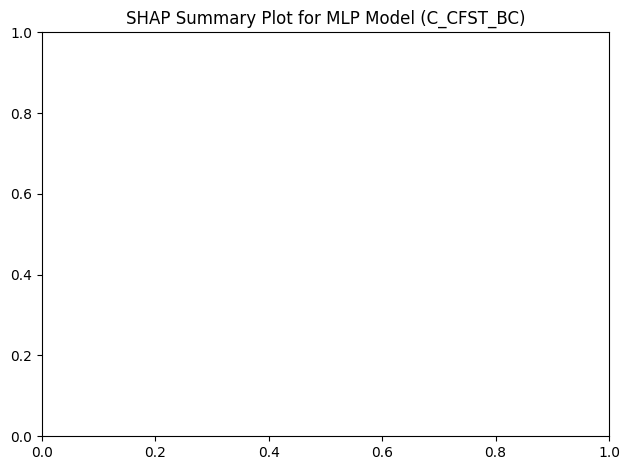

In [ ]:

import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os


SHEET = 'C_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
model_path = os.path.join(BASE_DIR, 'MLP_HoldOut.pkl')
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')


model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

# Scale training data for SHAP background (same as Sheet 1)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

background_data = shap.sample(X_train_scaled, 50)


predict_fn = lambda x: model.predict(x)

explainer = shap.KernelExplainer(predict_fn, background_data)


shap_values = explainer.shap_values(X_test_scaled[:50], nsamples=100)


plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled[:50], feature_names=X.columns)
plt.title(f"SHAP Summary Plot for MLP Model ({SHEET})")
plt.tight_layout()
plt.show()

"Unlike tree-based ensemble models (e.g., XGBoost) which provide intrinsic feature importance based on decision nodes and information gain, the Multi-Layer Perceptron (MLP) is a non-linear neural network. Due to its complex architecture—comprising multiple layers, weighted connections, and activation functions—it does not offer a direct or inherent way to rank input features. Consequently, the MLP is often classified as a 'black-box' model. To address this and ensure model transparency, post-hoc interpretability techniques, specifically Permutation Importance and SHAP (SHapley Additive exPlanations), were utilized to evaluate the relative contribution of each feature to the model's predictive output."

##  **Sheet 3) CFST_R**


*   XGBoost
*   Stacking



### **Setup**

In [ ]:

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

Dataset: R_CFST
Samples: 736  Features: 13


### **Model 1: XGBoost + Nested CV + Optuna**


In [ ]:

def run_xgb_nested_cv(X, y, label='XGBoost'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                  'n_estimators': trial.suggest_int('n_estimators', 100, 1200),
                  'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                  'max_depth': trial.suggest_int('max_depth', 3, 12),
                  'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                  'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                  'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                  'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                  'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                  'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
                  'random_state': RANDOM_STATE,
                  'n_jobs': -1
              }

                m = xgb.XGBRegressor(**p, verbosity=0)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS,
                           show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })
        model = xgb.XGBRegressor(**best_params, verbosity=0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

### **Model 2: Stacking (RF + Tuned XGBoost) + Nested CV**


In [ ]:



def run_stacking_nested_cv(X, y, xgb_best_params,
                            label='Stacking'):

    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]


        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_rf_params = None
        best_score     = -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def rf_objective(trial):
                p = {
                    'n_estimators': trial.suggest_int(
                                        'n_estimators', 100, 500),
                    'max_depth':    trial.suggest_int(
                                        'max_depth', 5, 20),
                    'min_samples_split': trial.suggest_int(
                                             'min_samples_split', 2, 10),
                    'max_features': trial.suggest_float(
                                        'max_features', 0.3, 1.0),
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1
                }
                rf = RandomForestRegressor(**p)
                rf.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, rf.predict(X_in_val))

            study_rf = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study_rf.optimize(rf_objective,
                              n_trials=N_TRIALS // 2,
                              show_progress_bar=False)

            if study_rf.best_value > best_score:
                best_score     = study_rf.best_value
                best_rf_params = study_rf.best_params

        best_rf_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })



        estimators = [
            ('rf',  RandomForestRegressor(**best_rf_params)),
            ('xgb', xgb.XGBRegressor(
                **xgb_best_params, verbosity=0)),
        ]
        stack = StackingRegressor(
            estimators      = estimators,
            final_estimator = Ridge(alpha=1.0),
            cv              = 3,
            n_jobs          = -1,
        )
        stack.fit(X_tr, y_tr)
        y_pred = stack.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}")

    print(f"\n  {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':     label,
        'R2_Mean':   round(np.mean(outer_r2),   4),
        'R2_Std':    round(np.std(outer_r2),    4),
        'RMSE_Mean': round(np.mean(outer_rmse), 2),
        'RMSE_Std':  round(np.std(outer_rmse),  2),
        'MAE':       round(np.mean(outer_mae),  2),
        'MAPE':      round(np.mean(outer_mape), 2),
    }


### **Execution**


In [ ]:
print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

xgb_result = run_xgb_nested_cv(X, y, label='XGBoost')

stack_result = run_stacking_nested_cv(
    X, y,
    xgb_best_params = xgb_result['best_params'],
    label           = 'Stacking (RF + XGB)'
)



#######################################################
# SHEET: R_CFST
#######################################################

XGBoost — Nested CV
  Fold 1: R²=0.9627  RMSE=397.7  depth=4
  Fold 2: R²=0.9890  RMSE=210.1  depth=3
  Fold 3: R²=0.9587  RMSE=430.8  depth=9
  Fold 4: R²=0.9752  RMSE=353.2  depth=3
  Fold 5: R²=0.9783  RMSE=336.9  depth=3

  XGBoost:
    R²   = 0.9728 ± 0.0110
    RMSE = 345.73 ± 75.43
    MAE  = 178.76
    MAPE = 8.80%

Stacking (RF + XGB) — Nested CV
  Fold 1: R²=0.9434  RMSE=489.8
  Fold 2: R²=0.9830  RMSE=261.2
  Fold 3: R²=0.9577  RMSE=436.0
  Fold 4: R²=0.9767  RMSE=342.6
  Fold 5: R²=0.9760  RMSE=354.5

  Stacking (RF + XGB):
    R²   = 0.9674 ± 0.0147
    RMSE = 376.80 ± 79.11
    MAE  = 233.65
    MAPE = 14.14%


### **RESULTS**


In [ ]:


print(f"\n{'='*60}")
print(f"FINAL COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)

for res in [xgb_result, stack_result]:
    print(f"{res['model']:<22} "
          f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
          f"{res['RMSE_Mean']:>8.1f} "
          f"{res['MAE']:>8.1f} "
          f"{res['MAPE']:>7.2f}%")

print("="*60)

winner = (xgb_result if xgb_result['R2_Mean'] >=
          stack_result['R2_Mean'] else stack_result)
print(f"\nWinner for {SHEET}: {winner['model']} "
      f"(R²={winner['R2_Mean']:.4f})")




FINAL COMPARISON — R_CFST
Model                            R²               RMSE      MAE   MAPE%
------------------------------------------------------------
XGBoost                0.9728 ± 0.0110     345.7    178.8    8.80%
Stacking (RF + XGB)    0.9674 ± 0.0147     376.8    233.7   14.14%

Winner for R_CFST: XGBoost (R²=0.9728)


### **Save**


In [ ]:

import joblib
import json
import os
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n{'='*55}Saved in {BASE_DIR}\n{'='*55}")

scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved: {scaler_path}")


xgb_final = xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0)
xgb_final.fit(X, y)
joblib.dump(xgb_final, os.path.join(BASE_DIR, 'XGBoost_NestedCV.pkl'))
print(f"XGBoost final model saved.")



rf_best_params = {'n_estimators': 300, 'max_depth': 10, 'random_state': RANDOM_STATE} # يفضل استخدام أفضل params لو قمتِ بتخزينها
stack_final = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(**rf_best_params, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0))
    ],
    final_estimator=Ridge(),
    cv=3, n_jobs=-1
)
stack_final.fit(X, y)
joblib.dump(stack_final, os.path.join(BASE_DIR, 'Stacking_NestedCV.pkl'))
print(f"✓ Stacking final model saved.")


all_results = {
    "XGBoost": xgb_result,
    "Stacking": stack_result
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=======================================================Saved in /content/drive/MyDrive/Master/Final/R_CFST
Scaler saved: /content/drive/MyDrive/Master/Final/R_CFST/scaler.pkl
XGBoost final model saved.
✓ Stacking final model saved.


### **Train/Test split 70/30**

In [ ]:
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

SHEET    = 'R_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

X_raw = processed_data[SHEET]['X'].copy()
y     = processed_data[SHEET]['y']

obj_cols = X_raw.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    unique_vals = X_raw[col].dropna().unique()
    print(f"Encoding '{col}': {unique_vals}")
    if len(unique_vals) <= 2:
        X_raw[col] = X_raw[col].str.lower().str.contains(
            'cyl', na=False).astype(int)
    else:
        cat_col      = X_raw[col].astype('category')
        X_raw[col]   = cat_col.cat.codes

X = X_raw.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")
print(f"Features: {X.shape[1]}")

scaler         = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("✓ Scaler saved")

model = xgb.XGBRegressor(
    n_estimators  = 500,
    learning_rate = 0.05,
    max_depth     = 6,
    random_state  = 42,
    n_jobs        = -1
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\nR²   = {r2:.4f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAE  = {mae:.2f}")
print(f"MAPE = {mape:.2f}%")

joblib.dump(model, os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl'))
print(f"\n✅ Saved in {BASE_DIR}")

Encoding 'fc type': ['Cyl' 'Cube' 'Cyl 100']
Train: 515  Test: 221
Features: 13
✓ Scaler saved

R²   = 0.9521
RMSE = 439.76
MAE  = 211.70
MAPE = 9.68%

✅ Saved in /content/drive/MyDrive/Master/Final/R_CFST


### **Feature Importance**

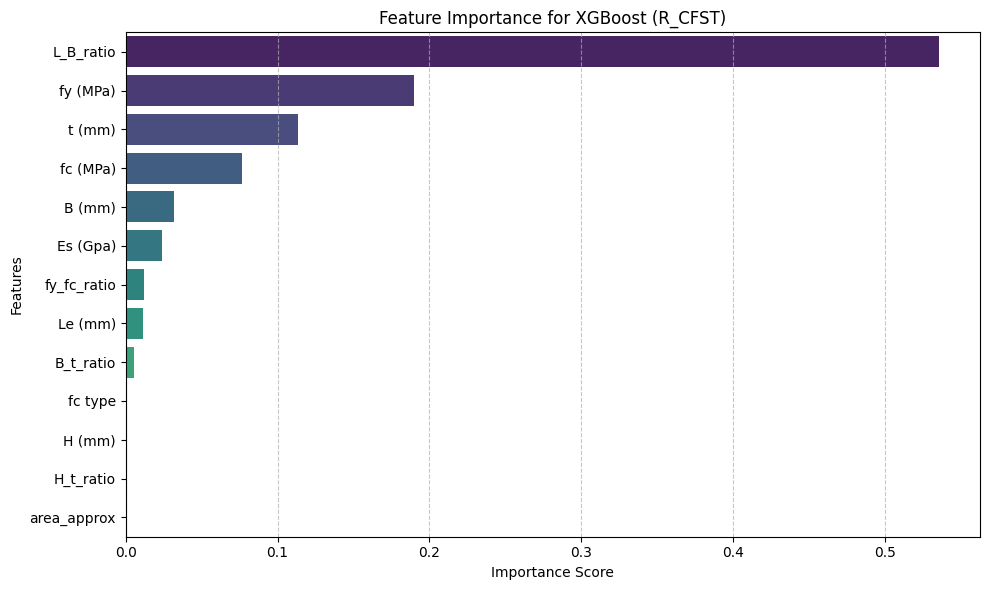

        Feature  Importance
10    L_B_ratio    0.535816
4      fy (MPa)    0.189779
2        t (mm)    0.113260
6      fc (MPa)    0.076642
0        B (mm)    0.031685
5      Es (Gpa)    0.024009
12  fy_fc_ratio    0.011875
3       Le (mm)    0.011401
8     B_t_ratio    0.005374
7       fc type    0.000157
1        H (mm)    0.000000
9     H_t_ratio    0.000000
11  area_approx    0.000000


In [ ]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SHEET = 'R_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')


loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)



feature_names = X.columns


importances = loaded_model.feature_importances_
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance for XGBoost ({SHEET})')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print(df_imp)

### **SHAP Analysis**

**How to Read SHAP Plots** 📊
Vertical Axis (Y): Features are ranked by importance (top = most influential). 🥇

Horizontal Axis (X): Shows the impact on the model's output.

Right of the center line: Positive impact (increases output). 📈

Left of the center line: Negative impact (decreases output). 📉

**Color Scale:**

Red dots (High): Represent high feature values. 🔴

Blue dots (Low): Represent low feature values. 🔵

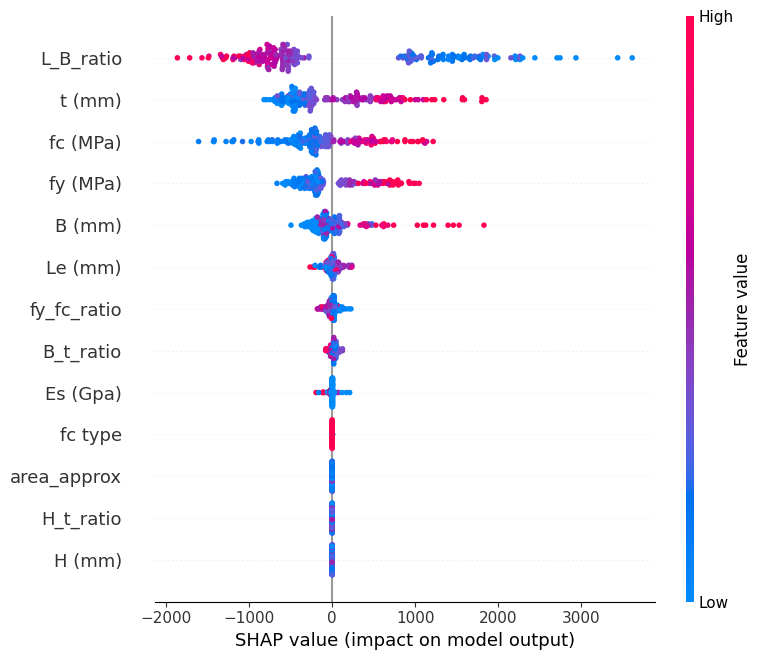

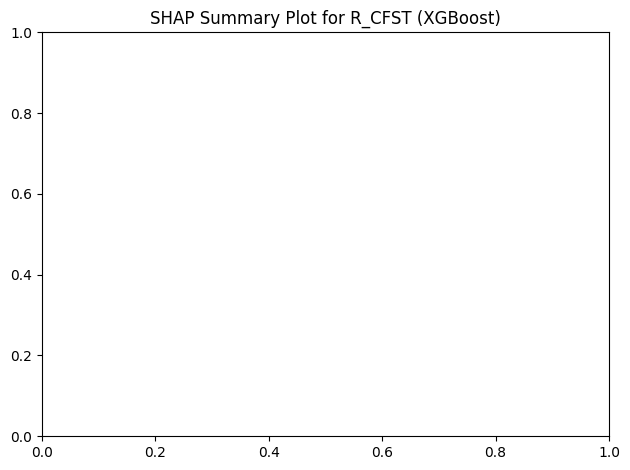

In [ ]:
import shap
import joblib
import os
import matplotlib.pyplot as plt


model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
model = joblib.load(model_path)


explainer = shap.TreeExplainer(model)


shap_values = explainer.shap_values(X_test_scaled)


plt.figure(figsize=(10, 6))

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)
plt.title(f"SHAP Summary Plot for {SHEET} (XGBoost)")
plt.tight_layout()
plt.show()

## **Sheet 3) R_CFST — MLP Regressor + Nested CV + Optuna**


In [ ]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 30.9 MB/s eta 0:00:00


In [ ]:
import optuna
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 3
N_SPLITS_INNER = 2
N_TRIALS       = 20

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")


def run_mlp_nested_cv(X, y, label='MLP Regressor'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        scaler_inner = StandardScaler()
        X_in_tr_scaled = scaler_inner.fit_transform(X_tr)
        X_in_te_scaled = scaler_inner.transform(X_te)

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_in_tr_scaled):
            X_in_tr  = X_in_tr_scaled[in_tr_idx]
            X_in_val = X_in_tr_scaled[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                n_layers = trial.suggest_int('n_layers', 1, 3)
                hidden_layers = tuple(
                    trial.suggest_int(f'n_units_l{i}', 32, 512, log=True)
                    for i in range(n_layers)
                )

                p = {
                    'hidden_layer_sizes':hidden_layers,
                    'activation':trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
                    'solver':trial.suggest_categorical('solver', ['adam', 'lbfgs']),
                    'alpha':trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
                    'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
                    'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64, 128, 'auto']),
                    'max_iter':2000,
                    'early_stopping':True,
                    'validation_fraction': 0.1,
                    'n_iter_no_change':20,
                    'random_state':RANDOM_STATE
                }

                if p['solver'] == 'lbfgs':
                    p['early_stopping'] = False
                    p['batch_size'] = 'auto'

                m = MLPRegressor(**p)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_hidden = tuple(
            best_params[f'n_units_l{i}']
            for i in range(best_params['n_layers'])
        )

        final_params = {
            'hidden_layer_sizes':  best_hidden,
            'activation':best_params['activation'],
            'solver':best_params['solver'],
            'alpha': best_params['alpha'],
            'learning_rate_init':best_params['learning_rate_init'],
            'batch_size':best_params['batch_size'],
            'max_iter':2000,
            'early_stopping':True,
            'validation_fraction': 0.1,
            'n_iter_no_change':20,
            'random_state': RANDOM_STATE
        }

        if final_params['solver'] == 'lbfgs':
            final_params['early_stopping'] = False
            final_params['batch_size'] = 'auto'

        model = MLPRegressor(**final_params)
        model.fit(X_in_tr_scaled, y_tr)
        y_pred = model.predict(X_in_te_scaled)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"layers={best_params['n_layers']}  "
              f"units={[best_params[f'n_units_l{i}'] for i in range(best_params['n_layers'])]}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }


print(f"\n{'#'*55}")
print(f"# ⭐SHEET: {SHEET}")
print(f"{'#'*55}")

mlp_result = run_mlp_nested_cv(X, y, label='MLP Regressor')


print(f"\n{'='*60}")
print(f"FINAL RESULTS — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)





#Results
res = mlp_result
print(f"{res['model']:<22} "
      f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
      f"{res['RMSE_Mean']:>8.1f} "
      f"{res['MAE']:>8.1f} "
      f"{res['MAPE']:>7.2f}%")

print("="*60)

bp = mlp_result['best_params']
print(f"\nBest Params:")
print(f"  n_layers: {bp['n_layers']}")
for i in range(bp['n_layers']):
    print(f"  n_units_l{i}: {bp[f'n_units_l{i}']}")
print(f"  activation: {bp['activation']}")
print(f"  solver: {bp['solver']}")
print(f"  alpha: {bp['alpha']:.6f}")
print(f"  learning_rate_init: {bp['learning_rate_init']:.6f}")
print(f"  batch_size: {bp['batch_size']}")




#Save

import joblib
import json
import os
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_MLP'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n{'='*55}\n {BASE_DIR}\n{'='*55}")

scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")

bp = mlp_result['best_params']
best_hidden = tuple(bp[f'n_units_l{i}'] for i in range(bp['n_layers']))

final_params = {
    'hidden_layer_sizes':  best_hidden,
    'activation':bp['activation'],
    'solver':bp['solver'],
    'alpha':bp['alpha'],
    'learning_rate_init':bp['learning_rate_init'],
    'batch_size':bp['batch_size'],
    'max_iter':3000,
    'early_stopping':True,
    'validation_fraction': 0.1,
    'n_iter_no_change':50,
    'random_state':RANDOM_STATE
}

if final_params['solver'] == 'lbfgs':
    final_params['early_stopping'] = False
    final_params['batch_size'] = 'auto'

scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

mlp_final = MLPRegressor(**final_params)
mlp_final.fit(X_scaled_full, y)

joblib.dump(mlp_final, os.path.join(BASE_DIR, 'MLP_NestedCV.pkl'))
joblib.dump(scaler_full, os.path.join(BASE_DIR, 'scaler_full.pkl'))
print(f"MLP final model saved.")

with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(mlp_result, f, indent=4)
print(f"Results saved.")



Dataset: R_CFST
Samples: 736  Features: 13

#######################################################
# ⭐SHEET: R_CFST
#######################################################

MLP Regressor — Nested CV


[W 2026-07-07 11:40:09,894] Trial 0 failed with parameters: {'n_layers': 2, 'n_units_l0': 447, 'n_units_l1': 243, 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.002537815508265664, 'learning_rate_init': 0.013311216080736894, 'batch_size': 32} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_790/721307782.py", line 83, in objective
    m.fit(X_in_tr, y_in_tr)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 754, in fit
    return self._fit(X, y, incremental=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "

KeyboardInterrupt: 

### **Train/Test split 70/30 (HoldOut Validation)**


In [ ]:



import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor

SHEET = 'R_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_MLP'
os.makedirs(BASE_DIR, exist_ok=True)

X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Train: {X_train.shape[0]} Test: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler_holdout.pkl'))

mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

y_pred = mlp_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")
print(f"MAPE     : {mape:.2f}%")

joblib.dump(mlp_model, os.path.join(BASE_DIR, 'MLP_HoldOut.pkl'))
print(f"\nSaved in {BASE_DIR}")




import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=60, color='darkorange', label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y = x)')

z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
ax.plot(y_test, p(y_test), 'g-', lw=2, alpha=0.8, label='Fit Line')

textstr = '\n'.join((
    f'$R^2$ = {r2:.4f}',
    f'RMSE = {rmse:.2f}',
    f'MAE = {mae:.2f}',
    f'MAPE = {mape:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)

ax.set_xlabel('Actual Values', fontsize=13)
ax.set_ylabel('Predicted Values', fontsize=13)
ax.set_title(f'Regression Line Plot: Actual vs Predicted ({SHEET} — MLP)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'regression_line_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {os.path.join(BASE_DIR, 'regression_line_plot.png')}")





#plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred
ax1.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', s=50, color='coral')
ax1.axhline(y=0, color='r', linestyle='--', lw=2)
ax1.set_xlabel('Predicted Values', fontsize=12)
ax1.set_ylabel('Residuals', fontsize=12)
ax1.set_title(f'Residuals vs Predicted ({SHEET})', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.hist(residuals, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Residuals', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(f'Distribution of Residuals ({SHEET})', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'residuals_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {os.path.join(BASE_DIR, 'residuals_plot.png')}")

## **Sheet 3) R_CFST — MLP Regressor + Optimized**


In [ ]:
! pip install optuna

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_

In [ ]:
# ============================================================
# R_CFST — MLP + Log Target Transform (Full Code)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os, json
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 3
N_SPLITS_INNER = 2
N_TRIALS       = 20

X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

# ── Log Transform على الـ Target ──────────────────────────
y_log = np.log1p(y)

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")
print(f"Target range (original): {y.min():.0f} – {y.max():.0f} kN")
print(f"Target range (log):      {y_log.min():.3f} – {y_log.max():.3f}")

# ══════════════════════════════════════════════════════════
# Nested CV + Optuna على الـ Log Target
# ══════════════════════════════════════════════════════════

def run_mlp_log_nested_cv(X, y_log, y_orig, label='MLP + Log'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr    = X.iloc[tr_idx]
        X_te    = X.iloc[te_idx]
        y_tr    = y_log.iloc[tr_idx]
        y_te_log  = y_log.iloc[te_idx]
        y_te_orig = y_orig.iloc[te_idx]

        # ── Scaling ───────────────────────────────────────
        scaler_fold = StandardScaler()
        X_tr_sc     = scaler_fold.fit_transform(X_tr)
        X_te_sc     = scaler_fold.transform(X_te)

        inner_cv = KFold(n_splits=N_SPLITS_INNER,
                         shuffle=True,
                         random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr_sc):
            X_in_tr  = X_tr_sc[in_tr_idx]
            X_in_val = X_tr_sc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                n_layers = trial.suggest_int('n_layers', 1, 3)
                hidden_layers = tuple(
                    trial.suggest_int(
                        f'n_units_l{i}', 32, 512, log=True)
                    for i in range(n_layers)
                )
                p = {
                    'hidden_layer_sizes':  hidden_layers,
                    'activation':          trial.suggest_categorical(
                                               'activation',
                                               ['relu', 'tanh']),
                    'solver':              trial.suggest_categorical(
                                               'solver',
                                               ['adam', 'lbfgs']),
                    'alpha':               trial.suggest_float(
                                               'alpha', 1e-5, 1e-1,
                                               log=True),
                    'learning_rate_init':  trial.suggest_float(
                                               'learning_rate_init',
                                               1e-4, 1e-1, log=True),
                    'batch_size':          trial.suggest_categorical(
                                               'batch_size',
                                               [16, 32, 64, 128,
                                                'auto']),
                    'max_iter':            2000,
                    'early_stopping':      True,
                    'validation_fraction': 0.1,
                    'n_iter_no_change':    20,
                    'random_state':        RANDOM_STATE,
                }
                if p['solver'] == 'lbfgs':
                    p['early_stopping'] = False
                    p['batch_size']     = 'auto'

                m = MLPRegressor(**p)
                m.fit(X_in_tr, y_in_tr)

                # التقييم على الـ original scale
                y_pred_log  = m.predict(X_in_val)
                y_pred_orig = np.expm1(y_pred_log)
                y_val_orig  = np.expm1(y_in_val)
                return r2_score(y_val_orig, y_pred_orig)

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS,
                           show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        # ── تدريب الـ final model للـ fold ────────────────
        best_hidden = tuple(
            best_params[f'n_units_l{i}']
            for i in range(best_params['n_layers'])
        )
        final_params = {
            'hidden_layer_sizes':  best_hidden,
            'activation':          best_params['activation'],
            'solver':              best_params['solver'],
            'alpha':               best_params['alpha'],
            'learning_rate_init':  best_params['learning_rate_init'],
            'batch_size':          best_params['batch_size'],
            'max_iter':            2000,
            'early_stopping':      True,
            'validation_fraction': 0.1,
            'n_iter_no_change':    20,
            'random_state':        RANDOM_STATE,
        }
        if final_params['solver'] == 'lbfgs':
            final_params['early_stopping'] = False
            final_params['batch_size']     = 'auto'

        model = MLPRegressor(**final_params)
        model.fit(X_tr_sc, y_tr)

        # ── تقييم على الـ original scale ──────────────────
        y_pred_log  = model.predict(X_te_sc)
        y_pred_orig = np.expm1(y_pred_log)

        r2   = r2_score(y_te_orig, y_pred_orig)
        rmse = np.sqrt(mean_squared_error(
            y_te_orig, y_pred_orig))
        mae  = mean_absolute_error(y_te_orig, y_pred_orig)
        mape = np.mean(np.abs(
            (y_te_orig - y_pred_orig) / y_te_orig)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"layers={best_params['n_layers']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f}"
          f" ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f}"
          f" ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(float(np.mean(outer_r2)),   4),
        'R2_Std':      round(float(np.std(outer_r2)),    4),
        'RMSE_Mean':   round(float(np.mean(outer_rmse)), 2),
        'RMSE_Std':    round(float(np.std(outer_rmse)),  2),
        'MAE':         round(float(np.mean(outer_mae)),  2),
        'MAPE':        round(float(np.mean(outer_mape)), 2),
        'best_params': all_best_params[best_fold_idx],
    }

# ══════════════════════════════════════════════════════════
# تشغيل
# ══════════════════════════════════════════════════════════

print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET} — Log Target Transform")
print(f"{'#'*55}")

mlp_log_result = run_mlp_log_nested_cv(
    X, y_log, y, label='MLP + Log Transform'
)

# ══════════════════════════════════════════════════════════
# مقارنة مع النتايج القديمة
# ══════════════════════════════════════════════════════════

print(f"\n{'='*60}")
print(f"COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<25} {'R²':^22} {'RMSE':>8} {'MAPE%':>7}")
print("-"*60)
print(f"{'MLP (original)':<25} "
      f"{'0.9751':^22} {'297.59':>8} {'10.00%':>7}")
print(f"{'MLP + Log Transform':<25} "
      f"{mlp_log_result['R2_Mean']:.4f}"
      f" ± {mlp_log_result['R2_Std']:.4f}  "
      f"{mlp_log_result['RMSE_Mean']:>8.1f} "
      f"{mlp_log_result['MAPE']:>7.2f}%")
print("="*60)

improvement = mlp_log_result['R2_Mean'] - 0.9751
sign = "▲" if improvement > 0 else "▼"
print(f"\nR² Change: {sign}{abs(improvement):.4f}")

# ══════════════════════════════════════════════════════════
# HoldOut Validation (70/30)
# ══════════════════════════════════════════════════════════

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.3, random_state=RANDOM_STATE
)
y_test_orig  = np.expm1(y_test_log)
y_train_orig = np.expm1(y_train_log)

scaler_ho = StandardScaler()
X_train_sc = scaler_ho.fit_transform(X_train)
X_test_sc  = scaler_ho.transform(X_test)

bp = mlp_log_result['best_params']
best_hidden = tuple(
    bp[f'n_units_l{i}'] for i in range(bp['n_layers'])
)
final_params = {
    'hidden_layer_sizes':  best_hidden,
    'activation':          bp['activation'],
    'solver':              bp['solver'],
    'alpha':               bp['alpha'],
    'learning_rate_init':  bp['learning_rate_init'],
    'batch_size':          bp['batch_size'],
    'max_iter':            3000,
    'early_stopping':      True,
    'validation_fraction': 0.1,
    'n_iter_no_change':    30,
    'random_state':        RANDOM_STATE,
}
if final_params['solver'] == 'lbfgs':
    final_params['early_stopping'] = False
    final_params['batch_size']     = 'auto'

model_ho = MLPRegressor(**final_params)
model_ho.fit(X_train_sc, y_train_log)

y_pred_log  = model_ho.predict(X_test_sc)
y_pred_orig = np.expm1(y_pred_log)

r2   = r2_score(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae  = mean_absolute_error(y_test_orig, y_pred_orig)
mape = np.mean(np.abs(
    (y_test_orig - y_pred_orig) / y_test_orig)) * 100

print(f"\n--- HoldOut (70/30) ---")
print(f"R²   = {r2:.4f}  (was 0.9751)")
print(f"RMSE = {rmse:.2f}  (was 297.59)")
print(f"MAE  = {mae:.2f}  (was 189.81)")
print(f"MAPE = {mape:.2f}%  (was 10.00%)")

# ══════════════════════════════════════════════════════════
# Plots
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Regression line
ax = axes[0]
ax.scatter(y_test_orig, y_pred_orig,
           alpha=0.6, s=40, color='steelblue',
           edgecolors='k', linewidths=0.3,
           label='Predicted vs Actual')
lims = [0, max(float(y_test_orig.max()),
               float(y_pred_orig.max()))]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit')

z = np.polyfit(y_test_orig, y_pred_orig, 1)
p = np.poly1d(z)
x_line = np.linspace(lims[0], lims[1], 100)
ax.plot(x_line, p(x_line), 'g-', lw=2,
        alpha=0.8, label='Fit Line')

textstr = '\n'.join([
    f'$R^2$ = {r2:.4f}',
    f'RMSE = {rmse:.2f}',
    f'MAE = {mae:.2f}',
    f'MAPE = {mape:.2f}%',
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr,
        transform=ax.transAxes,
        fontsize=11, verticalalignment='top', bbox=props)
ax.set_xlabel('Actual (kN)', fontsize=12)
ax.set_ylabel('Predicted (kN)', fontsize=12)
ax.set_title(f'{SHEET} — MLP + Log Transform\nHoldOut',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Residuals vs Predicted
ax = axes[1]
residuals = y_test_orig.values - y_pred_orig
ax.scatter(y_pred_orig, residuals,
           alpha=0.5, s=40, color='coral',
           edgecolors='k', linewidths=0.3)
ax.axhline(0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted (kN)', fontsize=12)
ax.set_ylabel('Residuals', fontsize=12)
ax.set_title('Residuals vs Predicted', fontsize=12,
             fontweight='bold')
ax.grid(True, alpha=0.3)

# 3. Distribution of Residuals
ax = axes[2]
ax.hist(residuals, bins=25,
        color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='r', linestyle='--', lw=2)
ax.axvline(np.mean(residuals), color='green',
           linestyle='-', lw=2,
           label=f'Mean={np.mean(residuals):.1f}')
ax.set_xlabel('Residuals', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Residuals', fontsize=12,
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'{SHEET} — MLP + Log Transform',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════
# Save
# ══════════════════════════════════════════════════════════

from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_MLP_Log'
os.makedirs(BASE_DIR, exist_ok=True)

# Scaler
joblib.dump(scaler_ho,
            os.path.join(BASE_DIR, 'scaler.pkl'))

# Model (trained on full data with log target)
scaler_full = StandardScaler()
X_full_sc   = scaler_full.fit_transform(X)
y_full_log  = np.log1p(y)

model_full = MLPRegressor(**final_params)
model_full.fit(X_full_sc, y_full_log)

joblib.dump(model_full,
            os.path.join(BASE_DIR, 'MLP_Log_NestedCV.pkl'))
joblib.dump(scaler_full,
            os.path.join(BASE_DIR, 'scaler_full.pkl'))

# Results
all_results = {
    'nested_cv':   mlp_log_result,
    'holdout': {
        'R2':   round(float(r2),   4),
        'RMSE': round(float(rmse), 2),
        'MAE':  round(float(mae),  2),
        'MAPE': round(float(mape), 2),
    },
    'note': 'Target was log-transformed: y_log = log1p(y). '
            'Predictions must be back-transformed: '
            'y_pred = expm1(model.predict(X))',
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)

print(f"\n✅ All files saved to: {BASE_DIR}")
print(f"   - scaler.pkl")
print(f"   - MLP_Log_NestedCV.pkl")
print(f"   - scaler_full.pkl")
print(f"   - results.json")
print(f"\n⚠️  Note: للتنبؤ لازم تعمل expm1 على الـ output:")
print(f"   y_pred = np.expm1(model.predict(X_scaled))")

NameError: name 'processed_data' is not defined

## **Sheet 3) CatBoost**

In [ ]:


!pip install lightgbm -q

import lightgbm as lgb
import optuna
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

SHEET        = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                 shuffle=True, random_state=RANDOM_STATE)

outer_r2, outer_rmse = [], []
all_best_params = []

for fold, (tr_idx, te_idx) in enumerate(
        outer_cv.split(X), 1):

    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    inner_cv = KFold(n_splits=N_SPLITS_INNER,
                     shuffle=True, random_state=RANDOM_STATE)
    best_params, best_score = None, -np.inf

    for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
        X_in_tr  = X_tr.iloc[in_tr_idx]
        X_in_val = X_tr.iloc[in_val_idx]
        y_in_tr  = y_tr.iloc[in_tr_idx]
        y_in_val = y_tr.iloc[in_val_idx]

        def objective(trial):
            p = {
                'n_estimators':      trial.suggest_int(
                                         'n_estimators', 200, 2000),
                'learning_rate':     trial.suggest_float(
                                         'learning_rate', 0.005, 0.1,
                                         log=True),
                'num_leaves':        trial.suggest_int(
                                         'num_leaves', 20, 300),
                'max_depth':         trial.suggest_int(
                                         'max_depth', 3, 12),
                'min_child_samples': trial.suggest_int(
                                         'min_child_samples', 5, 100),
                'subsample':         trial.suggest_float(
                                         'subsample', 0.5, 1.0),
                'colsample_bytree':  trial.suggest_float(
                                         'colsample_bytree', 0.5, 1.0),
                'reg_alpha':         trial.suggest_float(
                                         'reg_alpha', 1e-8, 10.0,
                                         log=True),
                'reg_lambda':        trial.suggest_float(
                                         'reg_lambda', 1e-8, 10.0,
                                         log=True),
                'random_state': RANDOM_STATE,
                'n_jobs': -1,
                'verbose': -1,
            }
            m = lgb.LGBMRegressor(**p)
            m.fit(X_in_tr, y_in_tr)
            return r2_score(y_in_val, m.predict(X_in_val))

        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(
                seed=RANDOM_STATE)
        )
        study.optimize(objective, n_trials=N_TRIALS,
                       show_progress_bar=False)

        if study.best_value > best_score:
            best_score  = study.best_value
            best_params = study.best_params

    best_params.update({
        'random_state': RANDOM_STATE,
        'n_jobs': -1, 'verbose': -1
    })
    model = lgb.LGBMRegressor(**best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    outer_r2.append(r2)
    outer_rmse.append(rmse)
    all_best_params.append(best_params.copy())

    print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}")

print(f"\n  LightGBM:")
print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
print(f"    RMSE = {np.mean(outer_rmse):.2f}")
print(f"\n  XGBoost was: ~0.9750")
improvement = np.mean(outer_r2) - 0.9750
sign = "▲" if improvement > 0 else "▼"
print(f"  Change: {sign}{abs(improvement):.4f}")

  Fold 1: R²=0.9624  RMSE=399.1
  Fold 2: R²=0.9880  RMSE=220.0
  Fold 3: R²=0.9660  RMSE=390.9
  Fold 4: R²=0.9790  RMSE=325.1
  Fold 5: R²=0.9717  RMSE=385.1

  LightGBM:
    R²   = 0.9734 ± 0.0092
    RMSE = 344.04

  XGBoost was: ~0.9750
  Change: ▼0.0016


## **Sheet 3: kimi edits xgboost**

### **Simple CV + Optuna**

After filtering B=H: (736, 9)
Encoding 'fc type': ['Cyl' 'Cube' 'Cyl 100']

Final features (18): ['B (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'Es (Gpa)', 'fc (MPa)', 'fc type', 'B_t_ratio', 'L_B_ratio', 'fy_fc_ratio', 'As_mm2', 'Ac_mm2', 'steel_ratio', 'fy_x_fc', 'fy_x_area', 'L_B_ratio_sq', 't_B_ratio', 'lambda_norm']
Samples: 736

Outlier removal:
  Before: 736
  After: 609
  Removed: 127

Train: 487 | Test: 122

ExtraTrees Baseline:
  R²   = 0.9588
  RMSE = 445.31


  0%|          | 0/30 [00:00<?, ?it/s]


ExtraTrees Tuned:
  Best CV R² = 0.9649
  Best Params: {'n_estimators': 200, 'max_depth': 39, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'bootstrap': False}
  Test R²  = 0.9869
  Test RMSE = 251.55


  0%|          | 0/30 [00:00<?, ?it/s]


XGBoost Tuned:
  Best CV R² = 0.9701
  Test R²  = 0.9899
  Test RMSE = 220.72

Ensemble (Voting):
  R²   = 0.9899
  RMSE = 220.99

FINAL COMPARISON — R_CFST
Model                             R²         RMSE
────────────────────────────────────────────────────────────
ExtraTrees (Baseline)         0.9588       445.31
ExtraTrees (Tuned)            0.9869       251.55
XGBoost (Tuned)               0.9899       220.72
Ensemble (Voting)             0.9899       220.99

🏆 Winner: XGBoost (R² = 0.9899)


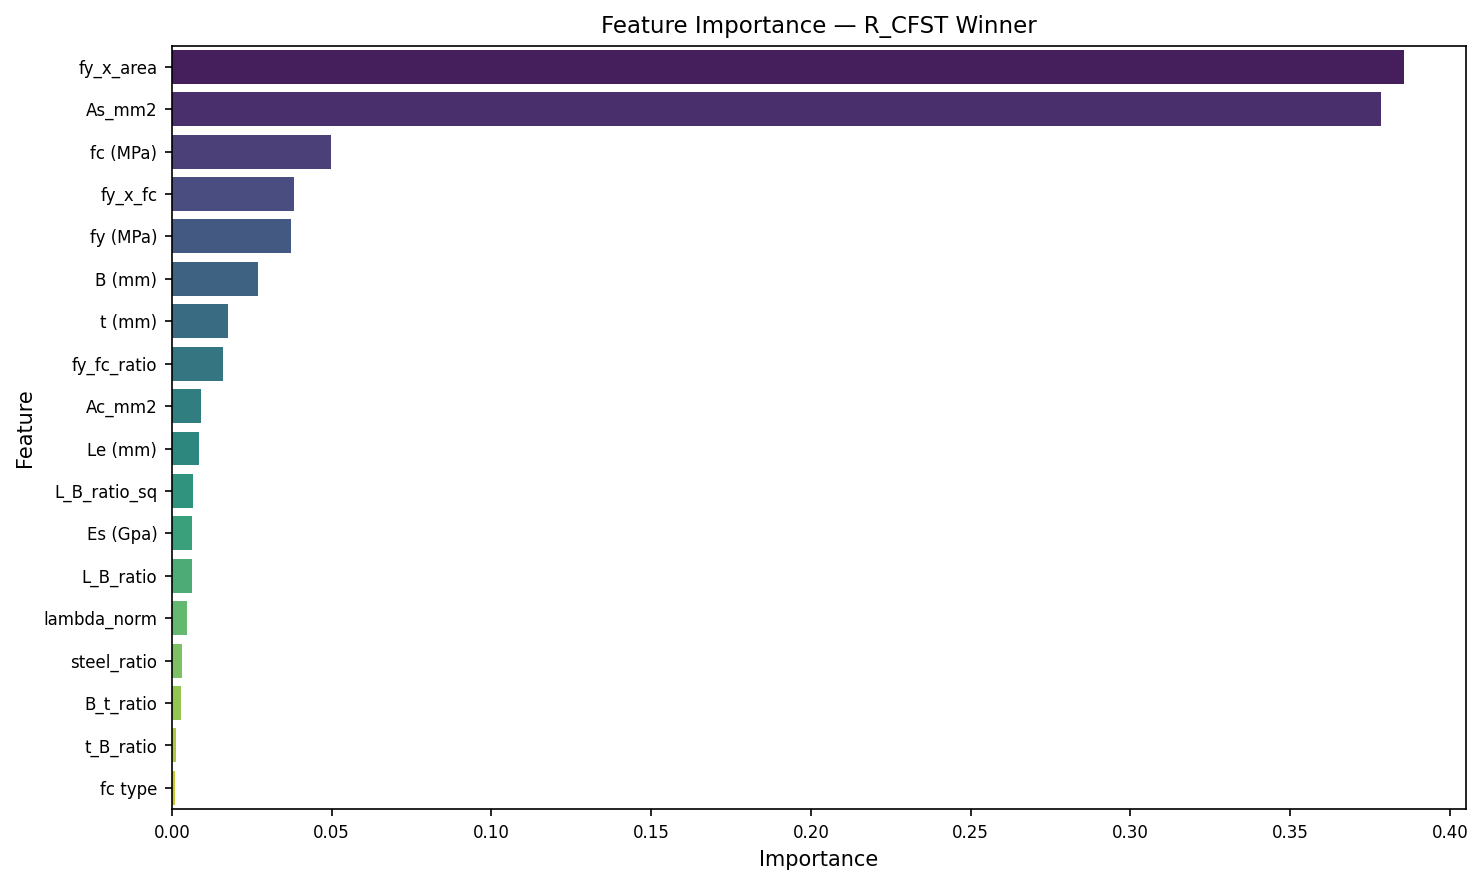


Feature Importance:
     Feature  Importance
   fy_x_area    0.385703
      As_mm2    0.378475
    fc (MPa)    0.049675
     fy_x_fc    0.038291
    fy (MPa)    0.037352
      B (mm)    0.026868
      t (mm)    0.017599
 fy_fc_ratio    0.015955
      Ac_mm2    0.009087
     Le (mm)    0.008467
L_B_ratio_sq    0.006497
    Es (Gpa)    0.006422
   L_B_ratio    0.006397
 lambda_norm    0.004842
 steel_ratio    0.003136
   B_t_ratio    0.002889
   t_B_ratio    0.001265
     fc type    0.001079


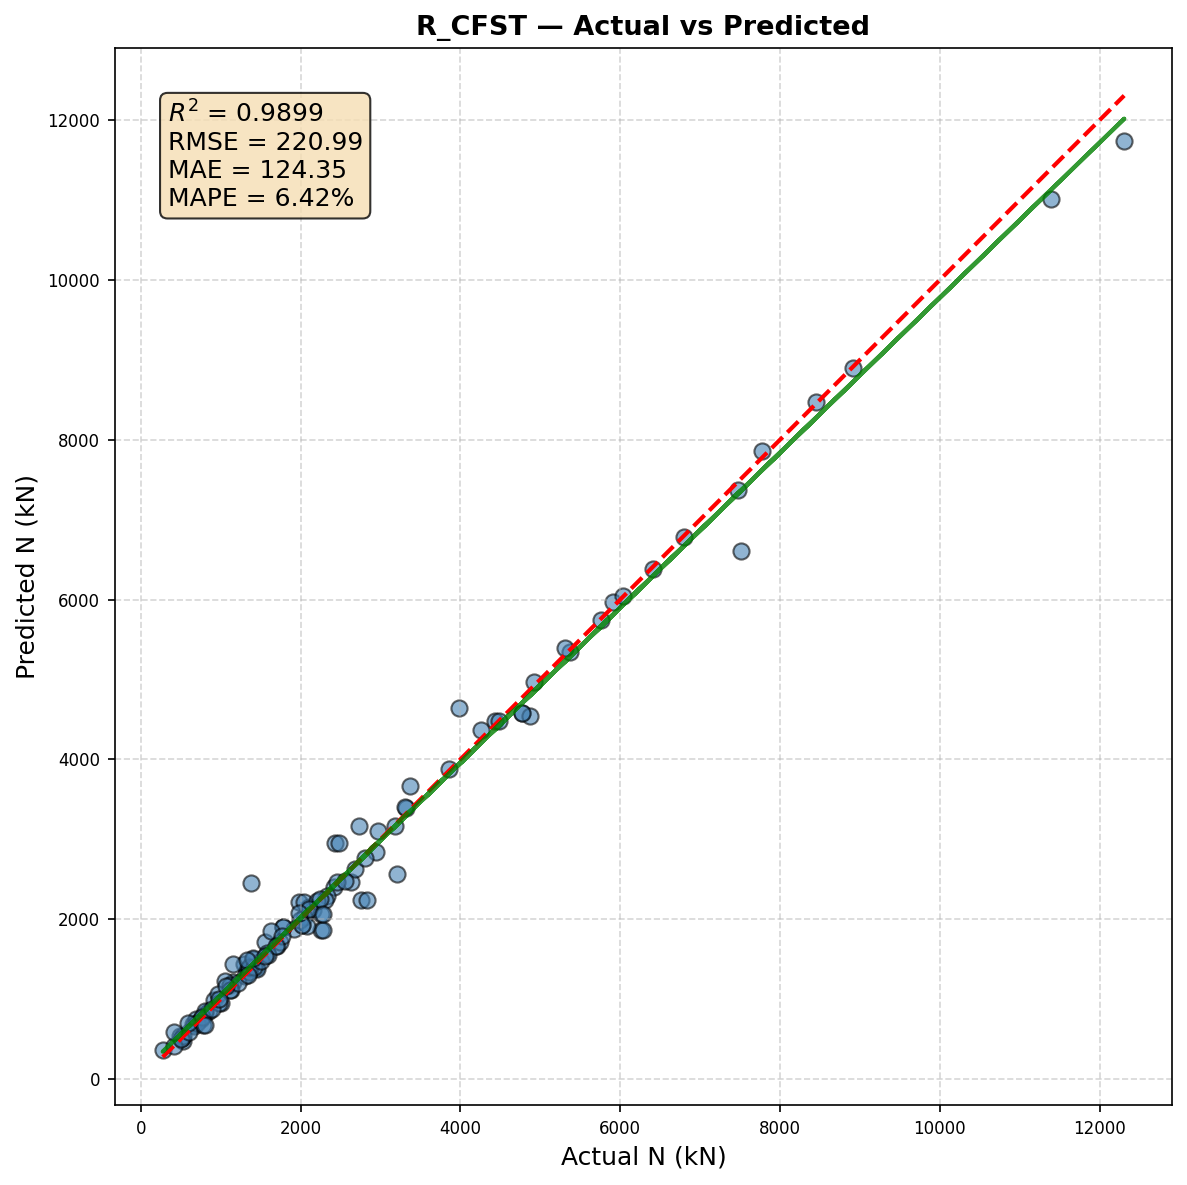

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Saved to: /content/drive/MyDrive/Master/Final/R_CFST_Improved


In [ ]:
## **R_CFST — Complete Pipeline for Higher Accuracy**

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. تحميل البيانات (لو مش محملة)
# ─────────────────────────────────────────────
import requests
from io import BytesIO

ALL_FEATURES_FILE = "https://raw.githubusercontent.com/FatemaTaher/CFST-Capacity-Prediction/main/CFST%20All%20Features.xlsx"
response = requests.get(ALL_FEATURES_FILE)
xls_all_features = pd.ExcelFile(BytesIO(response.content))

R_CFST = pd.read_excel(xls_all_features, sheet_name="R_CFST")

# ─────────────────────────────────────────────
# 2. تنظيف البيانات (نفس الكود بتاعك)
# ─────────────────────────────────────────────
R_CFST = R_CFST.drop(columns=['No', 'Refference', 'Year', 'Ref. No', 'Speciment', 'fu (MPa)', 'Ec (GPa)'])

# فلترة: B = H بس (Square sections)
R_CFST = R_CFST[R_CFST['B (mm)'] == R_CFST['H (mm)']].reset_index(drop=True)
print(f"After filtering B=H: {R_CFST.shape}")

# ─────────────────────────────────────────────
# 3. Feature Engineering (محسن)
# ─────────────────────────────────────────────
TARGET = 'N Test (kN)'

X = R_CFST.drop(columns=[TARGET]).copy()
y = R_CFST[TARGET].copy()

# Rename L/Le
if 'L /Le (mm)' in X.columns:
    X.rename(columns={'L /Le (mm)': 'Le (mm)'}, inplace=True)

# Basic features
X['B_t_ratio'] = X['B (mm)'] / X['t (mm)']
X['L_B_ratio'] = X['Le (mm)'] / X['B (mm)']
X['fy_fc_ratio'] = X['fy (MPa)'] / X['fc (MPa)']

# Advanced features
perimeter = 4 * X['B (mm)']  # للـ Square
X['As_mm2'] = perimeter * X['t (mm)']  # Steel area
X['Ac_mm2'] = X['B (mm)'] ** 2 - X['As_mm2']  # Concrete area
X['steel_ratio'] = X['As_mm2'] / (X['B (mm)'] ** 2)
X['fy_x_fc'] = X['fy (MPa)'] * X['fc (MPa)']
X['fy_x_area'] = X['fy (MPa)'] * (X['B (mm)'] ** 2)
X['L_B_ratio_sq'] = X['L_B_ratio'] ** 2
X['t_B_ratio'] = X['t (mm)'] / X['B (mm)']

# Normalized slenderness
r = X['B (mm)'] / np.sqrt(12)  # radius of gyration
Es = 200000  # MPa
X['lambda_norm'] = (X['Le (mm)'] / r) / np.sqrt(X['fy (MPa)'] / Es)

# Remove redundant features
cols_to_drop = ['H (mm)', 'H_t_ratio']  # H = B بعد الفلترة
for col in cols_to_drop:
    if col in X.columns:
        X = X.drop(columns=[col])

# Handle object columns
obj_cols = X.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    unique_vals = X[col].dropna().unique()
    print(f"Encoding '{col}': {unique_vals}")
    if len(unique_vals) <= 2:
        X[col] = X[col].str.lower().str.contains('cyl', na=False).astype(int)
    else:
        X[col] = X[col].astype('category').cat.codes

print(f"\nFinal features ({X.shape[1]}): {list(X.columns)}")
print(f"Samples: {len(y)}")

# ─────────────────────────────────────────────
# 4. Outlier Removal (IQR on L_B_ratio)
# ─────────────────────────────────────────────
Q1 = X['L_B_ratio'].quantile(0.25)
Q3 = X['L_B_ratio'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (X['L_B_ratio'] >= lower) & (X['L_B_ratio'] <= upper)
print(f"\nOutlier removal:")
print(f"  Before: {len(X)}")
print(f"  After: {mask.sum()}")
print(f"  Removed: {(~mask).sum()}")

X_clean = X[mask].reset_index(drop=True)
y_clean = y[mask].reset_index(drop=True)

# ─────────────────────────────────────────────
# 5. Scaling
# ─────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_clean), columns=X_clean.columns, index=X_clean.index)

# ─────────────────────────────────────────────
# 6. Train/Test Split
# ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clean, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# ─────────────────────────────────────────────
# 7. Baseline: ExtraTrees (أحسن من البيزلاين)
# ─────────────────────────────────────────────
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

et = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)

r2_et = r2_score(y_test, y_pred_et)
rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))
print(f"\n{'='*50}")
print(f"ExtraTrees Baseline:")
print(f"  R²   = {r2_et:.4f}")
print(f"  RMSE = {rmse_et:.2f}")

# ─────────────────────────────────────────────
# 8. Optuna Tuning for ExtraTrees
# ─────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_et(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'max_depth': trial.suggest_int('max_depth', 5, 40),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7, None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42,
        'n_jobs': -1
    }

    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(
        ExtraTreesRegressor(**params), X_train, y_train,
        cv=5, scoring='r2', n_jobs=-1
    )
    return scores.mean()

study_et = optuna.create_study(direction='maximize')
study_et.optimize(objective_et, n_trials=30, show_progress_bar=True)

print(f"\n{'='*50}")
print(f"ExtraTrees Tuned:")
print(f"  Best CV R² = {study_et.best_value:.4f}")
print(f"  Best Params: {study_et.best_params}")

# تدريب نهائي بأفضل params
et_best = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)
et_best.fit(X_train, y_train)
y_pred_et_best = et_best.predict(X_test)

r2_et_best = r2_score(y_test, y_pred_et_best)
rmse_et_best = np.sqrt(mean_squared_error(y_test, y_pred_et_best))
print(f"  Test R²  = {r2_et_best:.4f}")
print(f"  Test RMSE = {rmse_et_best:.2f}")

# ─────────────────────────────────────────────
# 9. XGBoost Tuned
# ─────────────────────────────────────────────
import xgboost as xgb

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'n_jobs': -1
    }

    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(
        xgb.XGBRegressor(**params, verbosity=0), X_train, y_train,
        cv=5, scoring='r2', n_jobs=-1
    )
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f"\n{'='*50}")
print(f"XGBoost Tuned:")
print(f"  Best CV R² = {study_xgb.best_value:.4f}")

xgb_best = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1, verbosity=0)
xgb_best.fit(X_train, y_train)
y_pred_xgb = xgb_best.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"  Test R²  = {r2_xgb:.4f}")
print(f"  Test RMSE = {rmse_xgb:.2f}")

# ─────────────────────────────────────────────
# 10. Ensemble: Voting (ExtraTrees + XGBoost)
# ─────────────────────────────────────────────
from sklearn.ensemble import VotingRegressor

ensemble = VotingRegressor([
    ('et', et_best),
    ('xgb', xgb_best)
])

ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

r2_ens = r2_score(y_test, y_pred_ens)
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_ens))
print(f"\n{'='*50}")
print(f"Ensemble (Voting):")
print(f"  R²   = {r2_ens:.4f}")
print(f"  RMSE = {rmse_ens:.2f}")

# ─────────────────────────────────────────────
# 11. Final Comparison
# ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"FINAL COMPARISON — R_CFST")
print(f"{'='*60}")
print(f"{'Model':<25} {'R²':>10} {'RMSE':>12}")
print(f"{'─'*60}")
print(f"{'ExtraTrees (Baseline)':<25} {r2_et:>10.4f} {rmse_et:>12.2f}")
print(f"{'ExtraTrees (Tuned)':<25} {r2_et_best:>10.4f} {rmse_et_best:>12.2f}")
print(f"{'XGBoost (Tuned)':<25} {r2_xgb:>10.4f} {rmse_xgb:>12.2f}")
print(f"{'Ensemble (Voting)':<25} {r2_ens:>10.4f} {rmse_ens:>12.2f}")
print(f"{'='*60}")

winner = max([('ExtraTrees', r2_et), ('ExtraTrees Tuned', r2_et_best),
              ('XGBoost', r2_xgb), ('Ensemble', r2_ens)], key=lambda x: x[1])
print(f"\n🏆 Winner: {winner[0]} (R² = {winner[1]:.4f})")

# ─────────────────────────────────────────────
# 12. Feature Importance (للـ Winner)
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

winner_model = et_best if r2_et_best >= max(r2_xgb, r2_ens) else (xgb_best if r2_xgb >= r2_ens else ensemble)

if hasattr(winner_model, 'feature_importances_'):
    importances = winner_model.feature_importances_
else:
    # للـ VotingRegressor نستخدم ExtraTrees
    importances = et_best.feature_importances_

df_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
df_imp = df_imp.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance — R_CFST Winner')
plt.tight_layout()
plt.show()

print(f"\nFeature Importance:")
print(df_imp.to_string(index=False))

# ─────────────────────────────────────────────
# 13. Regression Line Plot
# ─────────────────────────────────────────────
y_pred_winner = winner_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_winner, alpha=0.6, edgecolors='k', s=60, color='steelblue')

min_val = min(y_test.min(), y_pred_winner.min())
max_val = max(y_test.max(), y_pred_winner.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

z = np.polyfit(y_test, y_pred_winner, 1)
p = np.poly1d(z)
ax.plot(y_test, p(y_test), 'g-', lw=2, alpha=0.8)

mae = mean_absolute_error(y_test, y_pred_winner)
mape = np.mean(np.abs((y_test - y_pred_winner) / y_test)) * 100

textstr = f'$R^2$ = {r2_ens:.4f}\nRMSE = {rmse_ens:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Actual N (kN)', fontsize=12)
ax.set_ylabel('Predicted N (kN)', fontsize=12)
ax.set_title('R_CFST — Actual vs Predicted', fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 14. Save Results
# ─────────────────────────────────────────────
from google.colab import drive
import joblib
import os

drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/Master/Final/R_CFST_Improved'
os.makedirs(BASE_DIR, exist_ok=True)

joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
joblib.dump(et_best, os.path.join(BASE_DIR, 'ExtraTrees_Best.pkl'))
joblib.dump(xgb_best, os.path.join(BASE_DIR, 'XGBoost_Best.pkl'))
joblib.dump(ensemble, os.path.join(BASE_DIR, 'Ensemble.pkl'))

print(f"\n✅ Saved to: {BASE_DIR}")

### **Nested CV + Optuna**

After filtering B=H: (736, 9)
Encoding 'fc type': ['Cyl' 'Cube' 'Cyl 100']

Final features (18): ['B (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'Es (Gpa)', 'fc (MPa)', 'fc type', 'B_t_ratio', 'L_B_ratio', 'fy_fc_ratio', 'As_mm2', 'Ac_mm2', 'steel_ratio', 'fy_x_fc', 'fy_x_area', 'L_B_ratio_sq', 't_B_ratio', 'lambda_norm']

Outlier removal: 736 → 609 (removed 127)

#######################################################
# DATASET: R_CFST
# Samples: 609 | Features: 18
# Nested CV: 5-Fold Outer × 3-Fold Inner
# Optuna Trials: 20
#######################################################

XGBoost — Nested CV
  Fold 1: R²=0.9870  RMSE=250.5  depth=3
  Fold 2: R²=0.9676  RMSE=362.5  depth=5
  Fold 3: R²=0.9691  RMSE=393.7  depth=6
  Fold 4: R²=0.9859  RMSE=257.3  depth=3
  Fold 5: R²=0.9457  RMSE=567.3  depth=4

  ✓ XGBoost:
    R²   = 0.9710 ± 0.0150
    RMSE = 366.27 ± 115.28
    MAE  = 185.39
    MAPE = 7.32%

FINAL RESULTS — R_CFST
Model                            R²               RMSE      MAE

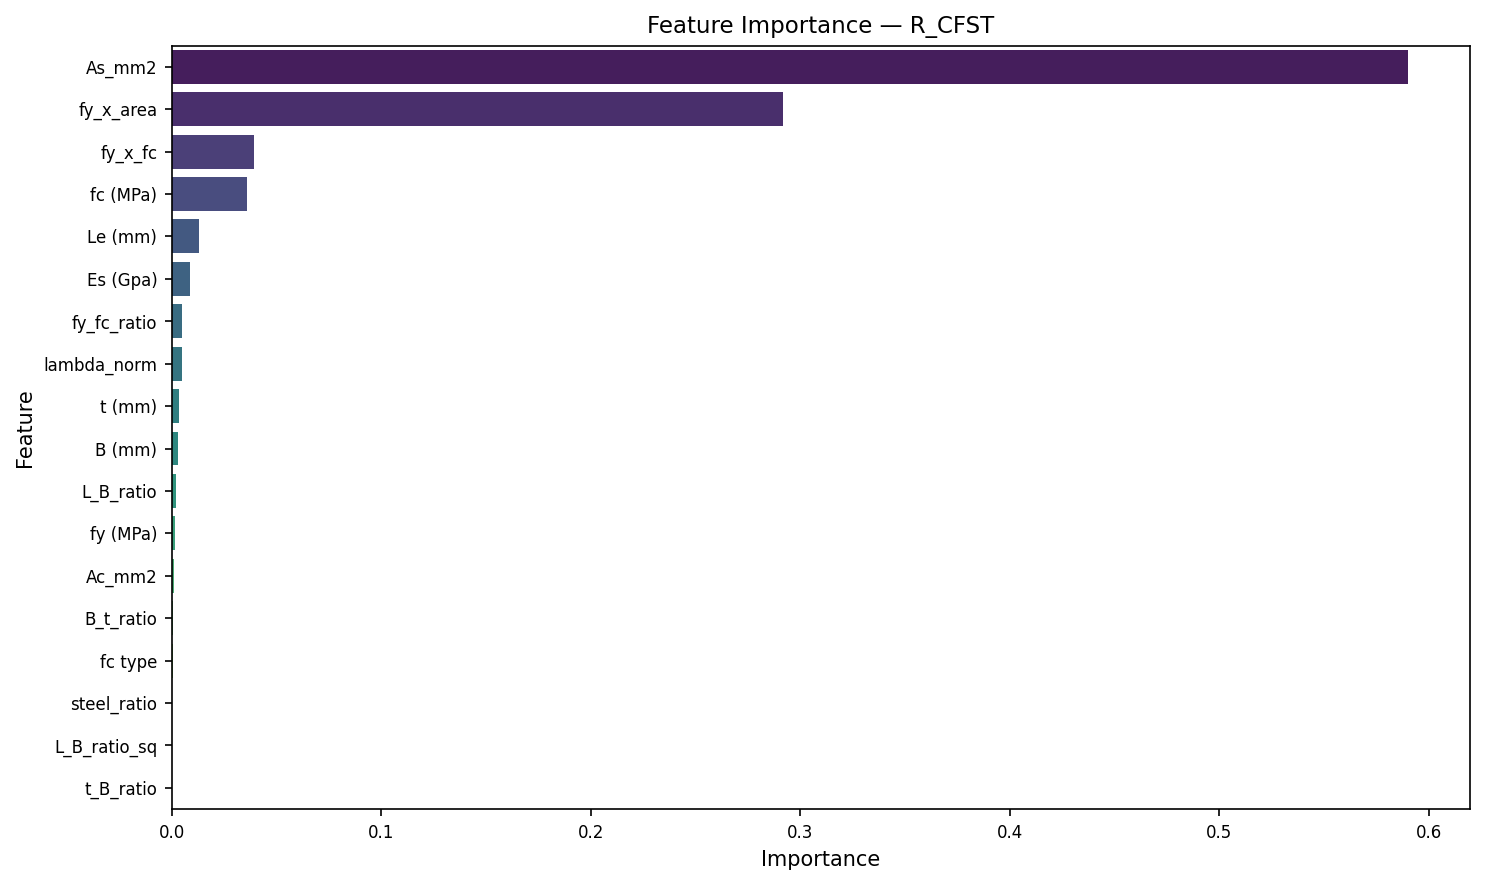

     Feature  Importance
      As_mm2    0.590208
   fy_x_area    0.291749
     fy_x_fc    0.039281
    fc (MPa)    0.035664
     Le (mm)    0.012993
    Es (Gpa)    0.008829
 fy_fc_ratio    0.004951
 lambda_norm    0.004735
      t (mm)    0.003358
      B (mm)    0.002694
   L_B_ratio    0.002040
    fy (MPa)    0.001625
      Ac_mm2    0.000910
   B_t_ratio    0.000599
     fc type    0.000364
 steel_ratio    0.000000
L_B_ratio_sq    0.000000
   t_B_ratio    0.000000


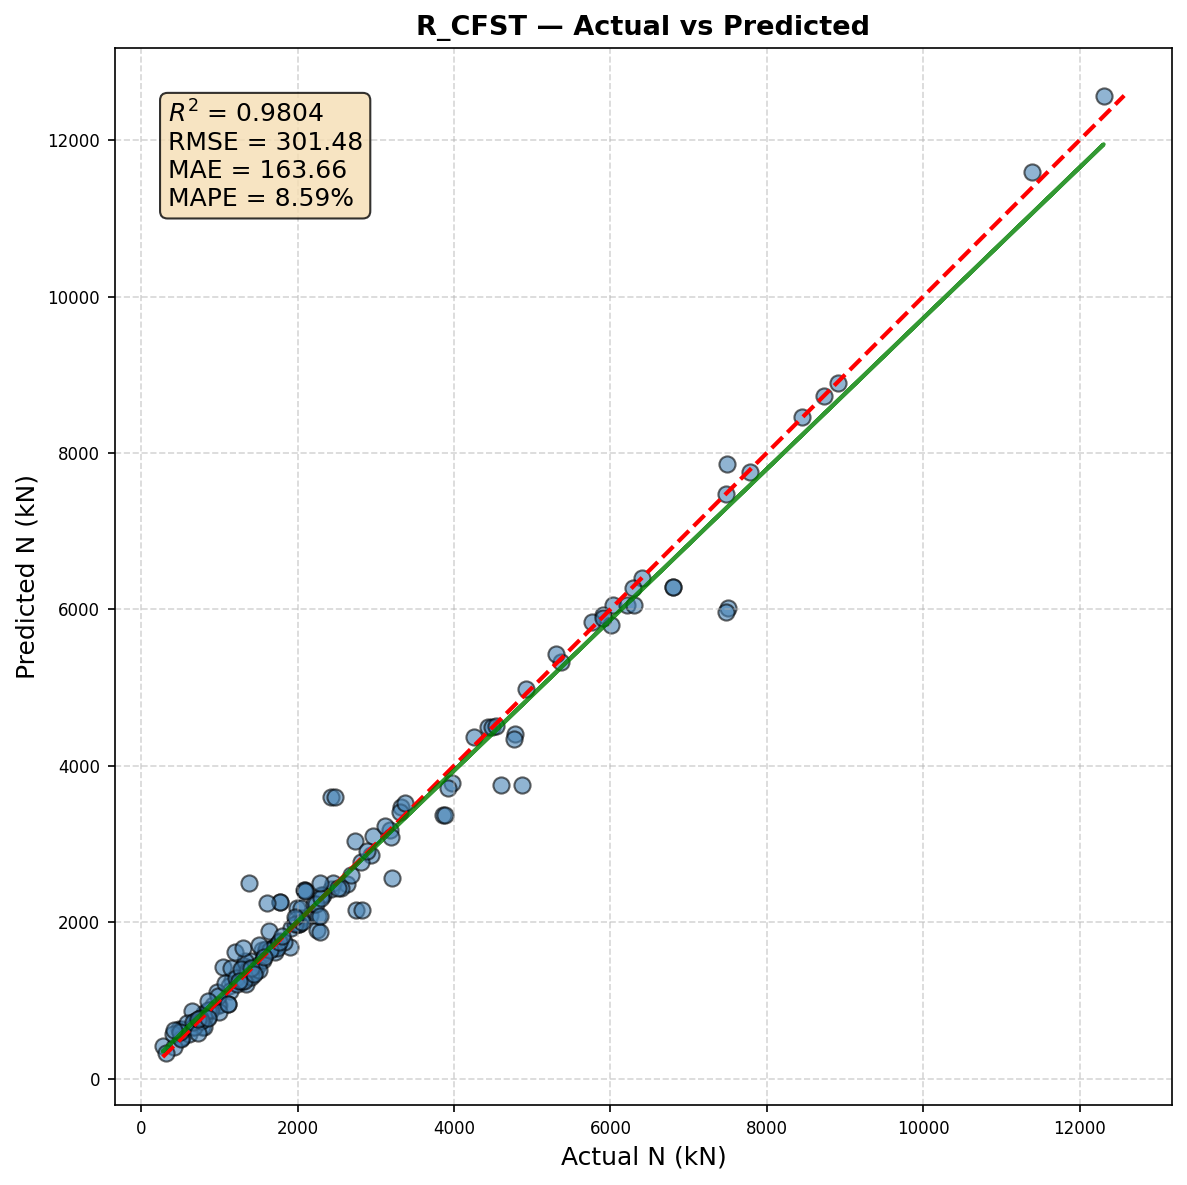

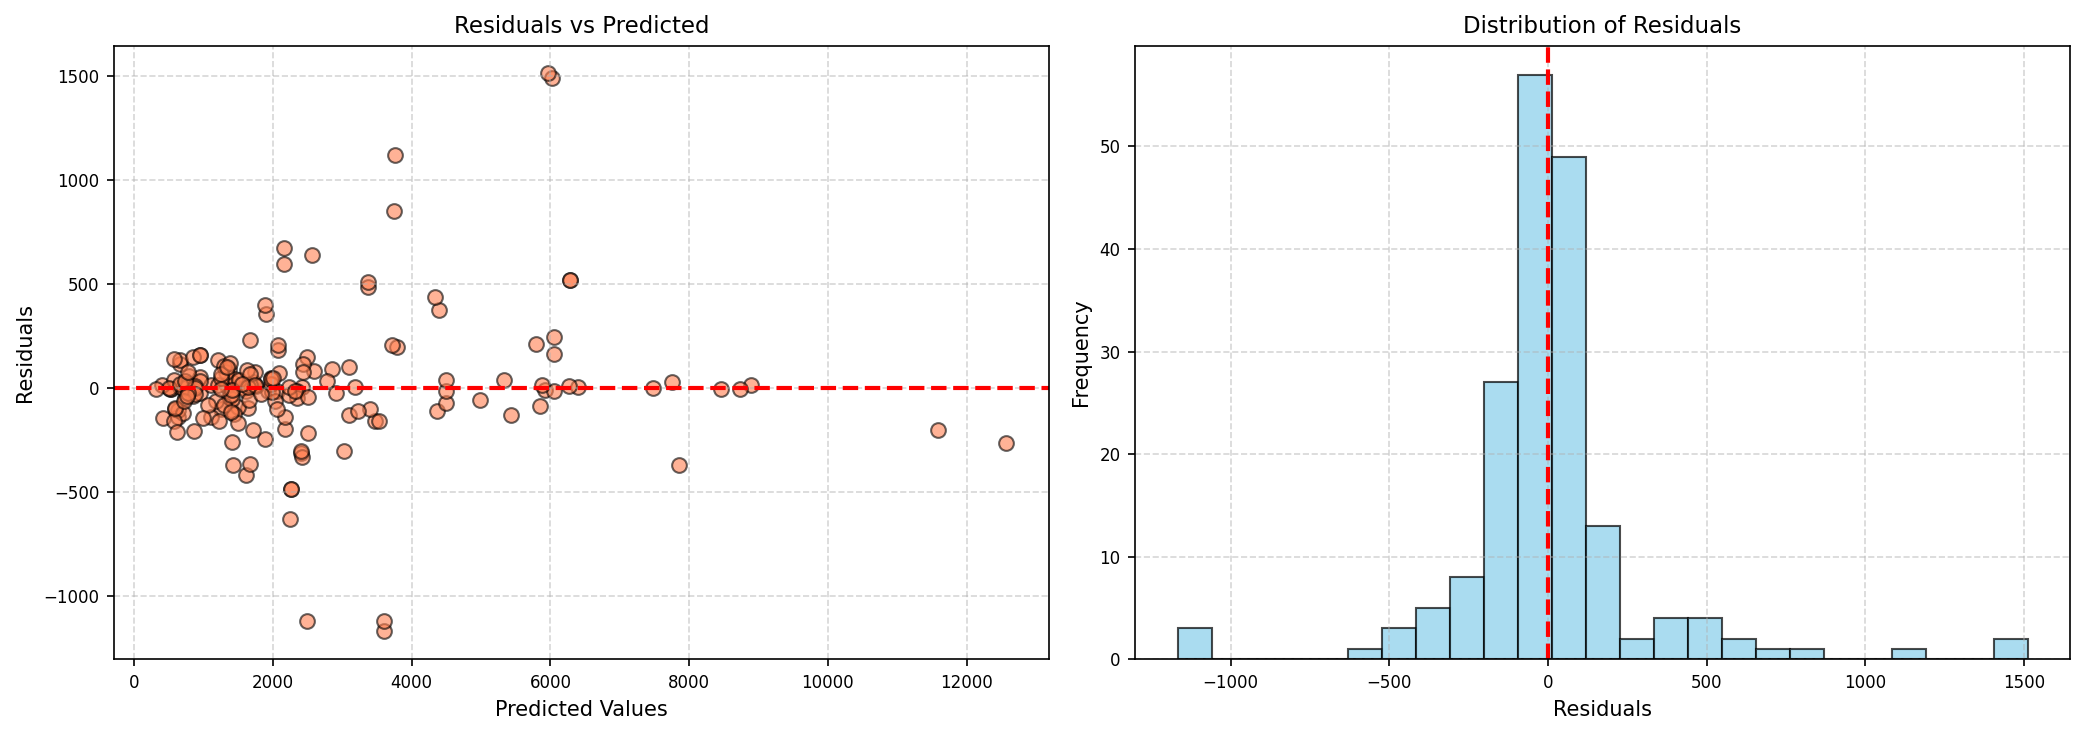


✅ All figures saved to: /content/drive/MyDrive/Master/Final/R_CFST_NestedCV


In [ ]:
## **R_CFST — Complete Pipeline: Nested CV + Optuna (20 Trials)**

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. تحميل البيانات
# ─────────────────────────────────────────────
import requests
from io import BytesIO

ALL_FEATURES_FILE = "https://raw.githubusercontent.com/FatemaTaher/CFST-Capacity-Prediction/main/CFST%20All%20Features.xlsx"
response = requests.get(ALL_FEATURES_FILE)
xls_all_features = pd.ExcelFile(BytesIO(response.content))

R_CFST = pd.read_excel(xls_all_features, sheet_name="R_CFST")

# ─────────────────────────────────────────────
# 2. تنظيف البيانات
# ─────────────────────────────────────────────
R_CFST = R_CFST.drop(columns=['No', 'Refference', 'Year', 'Ref. No', 'Speciment', 'fu (MPa)', 'Ec (GPa)'])

# فلترة: Square sections بس (B = H)
R_CFST = R_CFST[R_CFST['B (mm)'] == R_CFST['H (mm)']].reset_index(drop=True)
print(f"After filtering B=H: {R_CFST.shape}")

# ─────────────────────────────────────────────
# 3. Feature Engineering
# ─────────────────────────────────────────────
TARGET = 'N Test (kN)'

X = R_CFST.drop(columns=[TARGET]).copy()
y = R_CFST[TARGET].copy()

# Rename
if 'L /Le (mm)' in X.columns:
    X.rename(columns={'L /Le (mm)': 'Le (mm)'}, inplace=True)

# Basic ratios
X['B_t_ratio'] = X['B (mm)'] / X['t (mm)']
X['L_B_ratio'] = X['Le (mm)'] / X['B (mm)']
X['fy_fc_ratio'] = X['fy (MPa)'] / X['fc (MPa)']

# Advanced engineering features
perimeter = 4 * X['B (mm)']
X['As_mm2'] = perimeter * X['t (mm)']
X['Ac_mm2'] = X['B (mm)'] ** 2 - X['As_mm2']
X['steel_ratio'] = X['As_mm2'] / (X['B (mm)'] ** 2)
X['fy_x_fc'] = X['fy (MPa)'] * X['fc (MPa)']
X['fy_x_area'] = X['fy (MPa)'] * (X['B (mm)'] ** 2)
X['L_B_ratio_sq'] = X['L_B_ratio'] ** 2
X['t_B_ratio'] = X['t (mm)'] / X['B (mm)']

# Normalized slenderness
r = X['B (mm)'] / np.sqrt(12)
Es = 200000
X['lambda_norm'] = (X['Le (mm)'] / r) / np.sqrt(X['fy (MPa)'] / Es)

# Remove redundant features
for col in ['H (mm)', 'H_t_ratio']:
    if col in X.columns:
        X = X.drop(columns=[col])

# Encode categorical
obj_cols = X.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    unique_vals = X[col].dropna().unique()
    print(f"Encoding '{col}': {unique_vals}")
    if len(unique_vals) <= 2:
        X[col] = X[col].str.lower().str.contains('cyl', na=False).astype(int)
    else:
        X[col] = X[col].astype('category').cat.codes

print(f"\nFinal features ({X.shape[1]}): {list(X.columns)}")

# ─────────────────────────────────────────────
# 4. Outlier Removal (IQR on L_B_ratio)
# ─────────────────────────────────────────────
Q1 = X['L_B_ratio'].quantile(0.25)
Q3 = X['L_B_ratio'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (X['L_B_ratio'] >= lower) & (X['L_B_ratio'] <= upper)
print(f"\nOutlier removal: {len(X)} → {mask.sum()} (removed {(~mask).sum()})")

X_clean = X[mask].reset_index(drop=True)
y_clean = y[mask].reset_index(drop=True)

# ─────────────────────────────────────────────
# 5. Scaling
# ─────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_clean),
    columns=X_clean.columns,
    index=X_clean.index
)

# ─────────────────────────────────────────────
# 6. Nested CV + Optuna (20 Trials)
# ─────────────────────────────────────────────
import optuna
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS = 20  # قللنا من 40 لـ 20

X = X_scaled
y = y_clean

print(f"\n{'#'*55}")
print(f"# DATASET: {SHEET}")
print(f"# Samples: {len(y)} | Features: {X.shape[1]}")
print(f"# Nested CV: {N_SPLITS_OUTER}-Fold Outer × {N_SPLITS_INNER}-Fold Inner")
print(f"# Optuna Trials: {N_TRIALS}")
print(f"{'#'*55}")

def run_xgb_nested_cv(X, y, label='XGBoost'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER, shuffle=True, random_state=RANDOM_STATE)
    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X), 1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv = KFold(n_splits=N_SPLITS_INNER, shuffle=True, random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 1200),
                    'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                    'max_depth': trial.suggest_int('max_depth', 3, 12),
                    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                    'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                    'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1
                }
                m = xgb.XGBRegressor(**p, verbosity=0)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score = study.best_value
                best_params = study.best_params

        best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1})
        model = xgb.XGBRegressor(**best_params, verbosity=0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2 = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model': label,
        'R2_Mean': round(np.mean(outer_r2), 4),
        'R2_Std': round(np.std(outer_r2), 4),
        'RMSE_Mean': round(np.mean(outer_rmse), 2),
        'RMSE_Std': round(np.std(outer_rmse), 2),
        'MAE': round(np.mean(outer_mae), 2),
        'MAPE': round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

# Run Nested CV
xgb_result = run_xgb_nested_cv(X, y, label='XGBoost')

print(f"\n{'='*60}")
print(f"FINAL RESULTS — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)
res = xgb_result
print(f"{res['model']:<22} "
      f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
      f"{res['RMSE_Mean']:>8.1f} "
      f"{res['MAE']:>8.1f} "
      f"{res['MAPE']:>7.2f}%")
print("="*60)
print(f"\n✓ Best Params: {xgb_result['best_params']}")

# ─────────────────────────────────────────────
# 7. Save Model (Full Data)
# ─────────────────────────────────────────────
from google.colab import drive
import joblib
import json
import os

drive.mount('/content/drive')
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_NestedCV'
os.makedirs(BASE_DIR, exist_ok=True)

# Save scaler
joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))

# Train final model on full data
xgb_final = xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0)
xgb_final.fit(X, y)
joblib.dump(xgb_final, os.path.join(BASE_DIR, 'XGBoost_NestedCV.pkl'))

# Save results
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(xgb_result, f, indent=4)

print(f"\n✅ Saved to: {BASE_DIR}")

# ─────────────────────────────────────────────
# 8. HoldOut Validation (70/30)
# ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

xgb_holdout = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_holdout.fit(X_train, y_train)
y_pred = xgb_holdout.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n{'='*60}")
print(f"HOLDOUT VALIDATION (70/30)")
print(f"{'='*60}")
print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAE  = {mae:.2f}")
print(f"MAPE = {mape:.2f}%")

joblib.dump(xgb_holdout, os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl'))

# ─────────────────────────────────────────────
# 9. Feature Importance
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

importances = xgb_holdout.feature_importances_
df_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
df_imp = df_imp.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance — {SHEET}')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'feature_importance.png'), dpi=300)
plt.show()
print(df_imp.to_string(index=False))

# ─────────────────────────────────────────────
# 10. Regression Line Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=60, color='steelblue')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
ax.plot(y_test, p(y_test), 'g-', lw=2, alpha=0.8)

textstr = f'$R^2$ = {r2:.4f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Actual N (kN)', fontsize=12)
ax.set_ylabel('Predicted N (kN)', fontsize=12)
ax.set_title(f'{SHEET} — Actual vs Predicted', fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'regression_line_plot.png'), dpi=300)
plt.show()

# ─────────────────────────────────────────────
# 11. Residuals Plot
# ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred
ax1.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', s=50, color='coral')
ax1.axhline(y=0, color='r', linestyle='--', lw=2)
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Predicted')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.hist(residuals, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Residuals')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Residuals')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'residuals_plot.png'), dpi=300)
plt.show()

print(f"\n✅ All figures saved to: {BASE_DIR}")

### **Kimi Edits + 50 Trials**

In [ ]:
! pip install optuna

After filtering B=H: (736, 9)
Encoding 'fc type': ['Cyl' 'Cube' 'Cyl 100']

Final features (18): ['B (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'Es (Gpa)', 'fc (MPa)', 'fc type', 'B_t_ratio', 'L_B_ratio', 'fy_fc_ratio', 'As_mm2', 'Ac_mm2', 'steel_ratio', 'fy_x_fc', 'fy_x_area', 'L_B_ratio_sq', 't_B_ratio', 'lambda_norm']

Outlier removal: 736 → 609 (removed 127)

#######################################################
# DATASET: R_CFST
# Samples: 609 | Features: 18
# Nested CV: 5-Fold Outer × 3-Fold Inner
# Optuna Trials: 50
#######################################################

XGBoost — Nested CV
  Fold 1: R²=0.9849  RMSE=269.6  depth=8
  Fold 2: R²=0.9674  RMSE=363.7  depth=8
  Fold 3: R²=0.9698  RMSE=389.2  depth=8
  Fold 4: R²=0.9859  RMSE=257.3  depth=3
  Fold 5: R²=0.9466  RMSE=562.9  depth=4

  ✓ XGBoost:
    R²   = 0.9709 ± 0.0143
    RMSE = 368.55 ± 109.91
    MAE  = 184.11
    MAPE = 7.46%

FINAL RESULTS — R_CFST
Model                            R²               RMSE      MAE

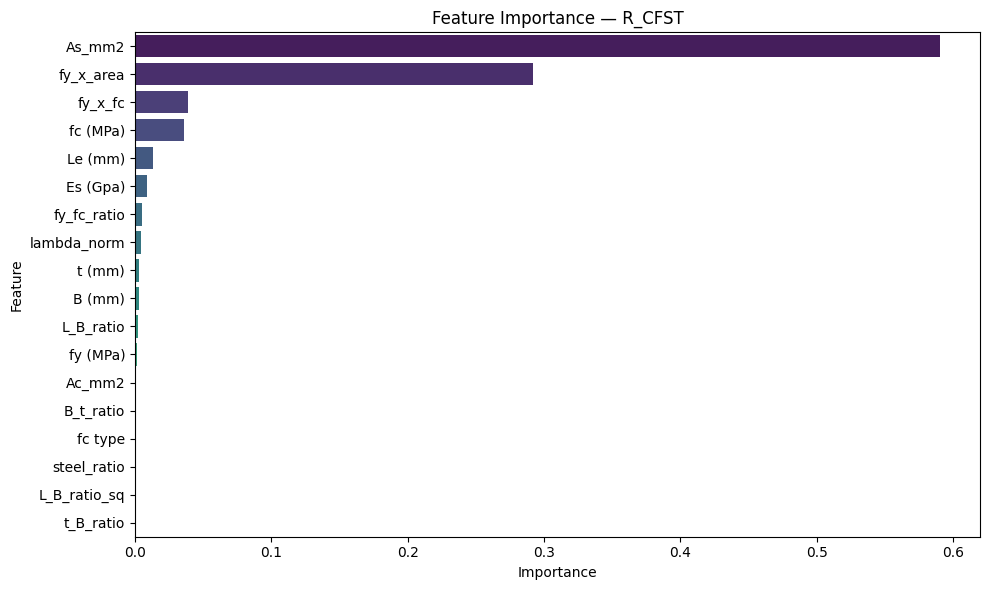

     Feature  Importance
      As_mm2    0.590208
   fy_x_area    0.291749
     fy_x_fc    0.039281
    fc (MPa)    0.035664
     Le (mm)    0.012993
    Es (Gpa)    0.008829
 fy_fc_ratio    0.004951
 lambda_norm    0.004735
      t (mm)    0.003358
      B (mm)    0.002694
   L_B_ratio    0.002040
    fy (MPa)    0.001625
      Ac_mm2    0.000910
   B_t_ratio    0.000599
     fc type    0.000364
 steel_ratio    0.000000
L_B_ratio_sq    0.000000
   t_B_ratio    0.000000


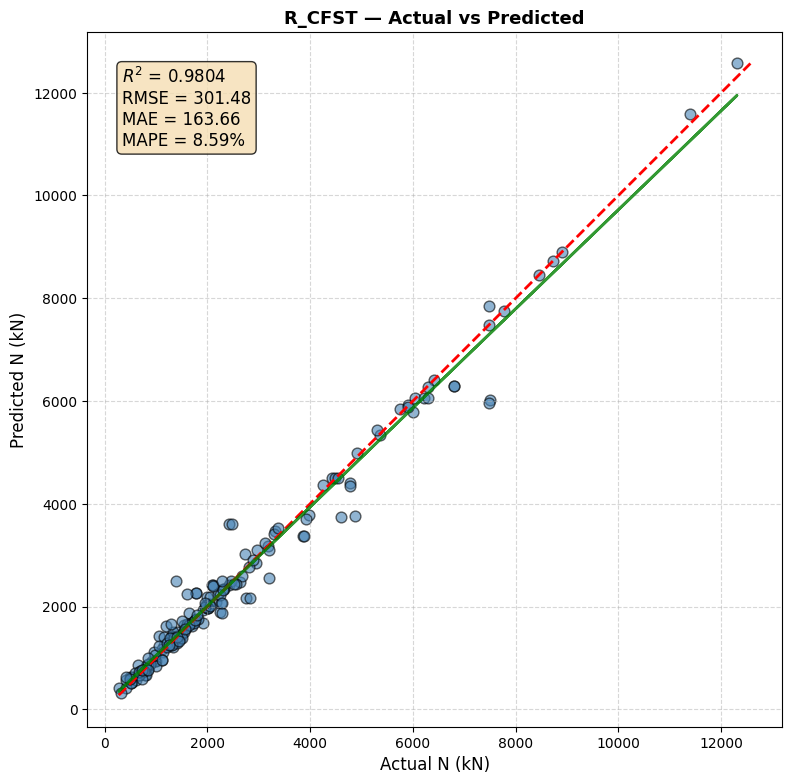

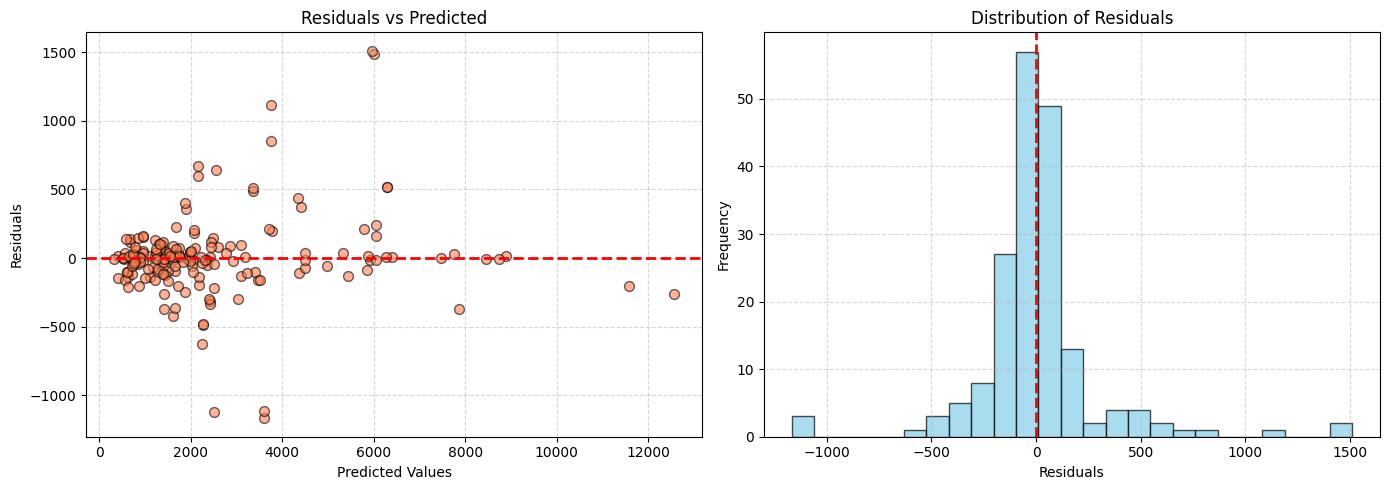


✅ All figures saved to: /content/drive/MyDrive/Master/Final/R_CFST_NestedCV


In [ ]:
## **R_CFST — Complete Pipeline: Nested CV + Optuna (20 Trials)**

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. تحميل البيانات
# ─────────────────────────────────────────────
import requests
from io import BytesIO

ALL_FEATURES_FILE = "https://raw.githubusercontent.com/FatemaTaher/CFST-Capacity-Prediction/main/CFST%20All%20Features.xlsx"
response = requests.get(ALL_FEATURES_FILE)
xls_all_features = pd.ExcelFile(BytesIO(response.content))

R_CFST = pd.read_excel(xls_all_features, sheet_name="R_CFST")

# ─────────────────────────────────────────────
# 2. تنظيف البيانات
# ─────────────────────────────────────────────
R_CFST = R_CFST.drop(columns=['No', 'Refference', 'Year', 'Ref. No', 'Speciment', 'fu (MPa)', 'Ec (GPa)'])

# فلترة: Square sections بس (B = H)
R_CFST = R_CFST[R_CFST['B (mm)'] == R_CFST['H (mm)']].reset_index(drop=True)
print(f"After filtering B=H: {R_CFST.shape}")

# ─────────────────────────────────────────────
# 3. Feature Engineering
# ─────────────────────────────────────────────
TARGET = 'N Test (kN)'

X = R_CFST.drop(columns=[TARGET]).copy()
y = R_CFST[TARGET].copy()

# Rename
if 'L /Le (mm)' in X.columns:
    X.rename(columns={'L /Le (mm)': 'Le (mm)'}, inplace=True)

# Basic ratios
X['B_t_ratio'] = X['B (mm)'] / X['t (mm)']
X['L_B_ratio'] = X['Le (mm)'] / X['B (mm)']
X['fy_fc_ratio'] = X['fy (MPa)'] / X['fc (MPa)']

# Advanced engineering features
perimeter = 4 * X['B (mm)']
X['As_mm2'] = perimeter * X['t (mm)']
X['Ac_mm2'] = X['B (mm)'] ** 2 - X['As_mm2']
X['steel_ratio'] = X['As_mm2'] / (X['B (mm)'] ** 2)
X['fy_x_fc'] = X['fy (MPa)'] * X['fc (MPa)']
X['fy_x_area'] = X['fy (MPa)'] * (X['B (mm)'] ** 2)
X['L_B_ratio_sq'] = X['L_B_ratio'] ** 2
X['t_B_ratio'] = X['t (mm)'] / X['B (mm)']

# Normalized slenderness
r = X['B (mm)'] / np.sqrt(12)
Es = 200000
X['lambda_norm'] = (X['Le (mm)'] / r) / np.sqrt(X['fy (MPa)'] / Es)

# Remove redundant features
for col in ['H (mm)', 'H_t_ratio']:
    if col in X.columns:
        X = X.drop(columns=[col])

# Encode categorical
obj_cols = X.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    unique_vals = X[col].dropna().unique()
    print(f"Encoding '{col}': {unique_vals}")
    if len(unique_vals) <= 2:
        X[col] = X[col].str.lower().str.contains('cyl', na=False).astype(int)
    else:
        X[col] = X[col].astype('category').cat.codes

print(f"\nFinal features ({X.shape[1]}): {list(X.columns)}")

# ─────────────────────────────────────────────
# 4. Outlier Removal (IQR on L_B_ratio)
# ─────────────────────────────────────────────
Q1 = X['L_B_ratio'].quantile(0.25)
Q3 = X['L_B_ratio'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (X['L_B_ratio'] >= lower) & (X['L_B_ratio'] <= upper)
print(f"\nOutlier removal: {len(X)} → {mask.sum()} (removed {(~mask).sum()})")

X_clean = X[mask].reset_index(drop=True)
y_clean = y[mask].reset_index(drop=True)

# ─────────────────────────────────────────────
# 5. Scaling
# ─────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_clean),
    columns=X_clean.columns,
    index=X_clean.index
)

# ─────────────────────────────────────────────
# 6. Nested CV + Optuna (20 Trials)
# ─────────────────────────────────────────────
import optuna
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS = 50  # قللنا من 40 لـ 20

X = X_scaled
y = y_clean

print(f"\n{'#'*55}")
print(f"# DATASET: {SHEET}")
print(f"# Samples: {len(y)} | Features: {X.shape[1]}")
print(f"# Nested CV: {N_SPLITS_OUTER}-Fold Outer × {N_SPLITS_INNER}-Fold Inner")
print(f"# Optuna Trials: {N_TRIALS}")
print(f"{'#'*55}")

def run_xgb_nested_cv(X, y, label='XGBoost'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER, shuffle=True, random_state=RANDOM_STATE)
    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X), 1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv = KFold(n_splits=N_SPLITS_INNER, shuffle=True, random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 1200),
                    'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                    'max_depth': trial.suggest_int('max_depth', 3, 12),
                    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                    'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                    'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1
                }
                m = xgb.XGBRegressor(**p, verbosity=0)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score = study.best_value
                best_params = study.best_params

        best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1})
        model = xgb.XGBRegressor(**best_params, verbosity=0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2 = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model': label,
        'R2_Mean': round(np.mean(outer_r2), 4),
        'R2_Std': round(np.std(outer_r2), 4),
        'RMSE_Mean': round(np.mean(outer_rmse), 2),
        'RMSE_Std': round(np.std(outer_rmse), 2),
        'MAE': round(np.mean(outer_mae), 2),
        'MAPE': round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

# Run Nested CV
xgb_result = run_xgb_nested_cv(X, y, label='XGBoost')

print(f"\n{'='*60}")
print(f"FINAL RESULTS — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)
res = xgb_result
print(f"{res['model']:<22} "
      f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
      f"{res['RMSE_Mean']:>8.1f} "
      f"{res['MAE']:>8.1f} "
      f"{res['MAPE']:>7.2f}%")
print("="*60)
print(f"\n✓ Best Params: {xgb_result['best_params']}")

# ─────────────────────────────────────────────
# 7. Save Model (Full Data)
# ─────────────────────────────────────────────
from google.colab import drive
import joblib
import json
import os

drive.mount('/content/drive')
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_NestedCV'
os.makedirs(BASE_DIR, exist_ok=True)

# Save scaler
joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))

# Train final model on full data
xgb_final = xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0)
xgb_final.fit(X, y)
joblib.dump(xgb_final, os.path.join(BASE_DIR, 'XGBoost_NestedCV.pkl'))

# Save results
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(xgb_result, f, indent=4)

print(f"\n✅ Saved to: {BASE_DIR}")

# ─────────────────────────────────────────────
# 8. HoldOut Validation (70/30)
# ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

xgb_holdout = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_holdout.fit(X_train, y_train)
y_pred = xgb_holdout.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n{'='*60}")
print(f"HOLDOUT VALIDATION (70/30)")
print(f"{'='*60}")
print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAE  = {mae:.2f}")
print(f"MAPE = {mape:.2f}%")

joblib.dump(xgb_holdout, os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl'))

# ─────────────────────────────────────────────
# 9. Feature Importance
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

importances = xgb_holdout.feature_importances_
df_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
df_imp = df_imp.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance — {SHEET}')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'feature_importance.png'), dpi=300)
plt.show()
print(df_imp.to_string(index=False))

# ─────────────────────────────────────────────
# 10. Regression Line Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=60, color='steelblue')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
ax.plot(y_test, p(y_test), 'g-', lw=2, alpha=0.8)

textstr = f'$R^2$ = {r2:.4f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Actual N (kN)', fontsize=12)
ax.set_ylabel('Predicted N (kN)', fontsize=12)
ax.set_title(f'{SHEET} — Actual vs Predicted', fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'regression_line_plot.png'), dpi=300)
plt.show()

# ─────────────────────────────────────────────
# 11. Residuals Plot
# ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred
ax1.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', s=50, color='coral')
ax1.axhline(y=0, color='r', linestyle='--', lw=2)
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Predicted')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.hist(residuals, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Residuals')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Residuals')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'residuals_plot.png'), dpi=300)
plt.show()

print(f"\n✅ All figures saved to: {BASE_DIR}")

### **MLP Regressor**

After filtering B=H: (736, 9)
Encoding 'fc type': ['Cyl' 'Cube' 'Cyl 100']

Final features (18): ['B (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'Es (Gpa)', 'fc (MPa)', 'fc type', 'B_t_ratio', 'L_B_ratio', 'fy_fc_ratio', 'As_mm2', 'Ac_mm2', 'steel_ratio', 'fy_x_fc', 'fy_x_area', 'L_B_ratio_sq', 't_B_ratio', 'lambda_norm']
Samples: 736 — NO outlier removal

NaN before imputation: 228
NaN after imputation: 0

#######################################################
# DATASET: R_CFST
# Samples: 736 | Features: 18
# NO Outlier Removal — Using RobustScaler
# Nested CV: 5-Fold Outer × 3-Fold Inner
# Optuna Trials: 20
#######################################################

MLP Regressor — Nested CV
  Fold 1: R²=0.9629  RMSE=396.6  layers=1  units=(56,)
  Fold 2: R²=0.9805  RMSE=280.2  layers=2  units=(231, 146)
  Fold 3: R²=0.9740  RMSE=341.4  layers=2  units=(231, 146)
  Fold 4: R²=0.9750  RMSE=354.5  layers=3  units=(148, 62, 42)
  Fold 5: R²=0.9679  RMSE=410.1  layers=2  units=(34, 250)

  ✓ M

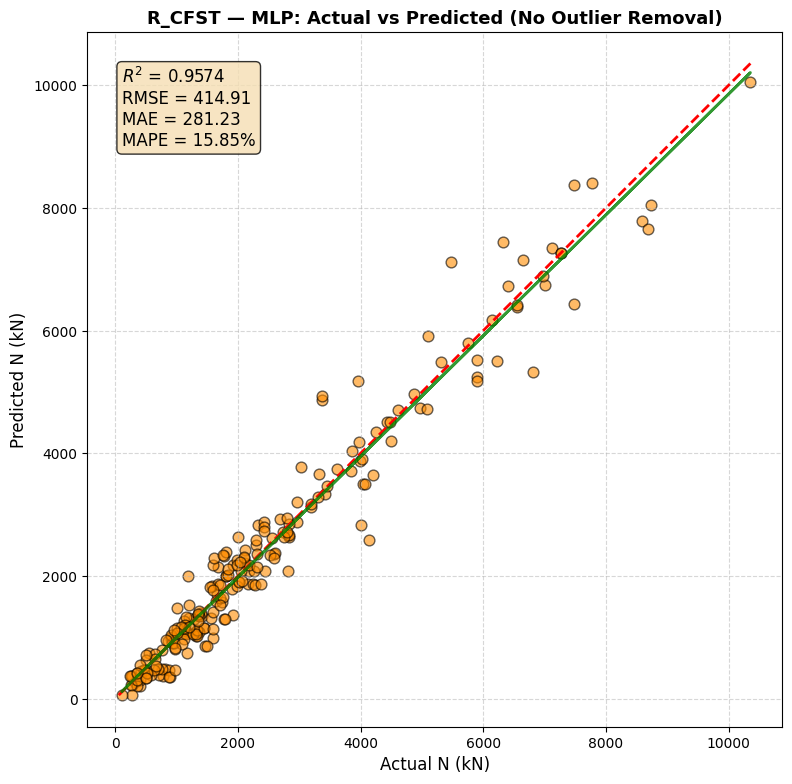

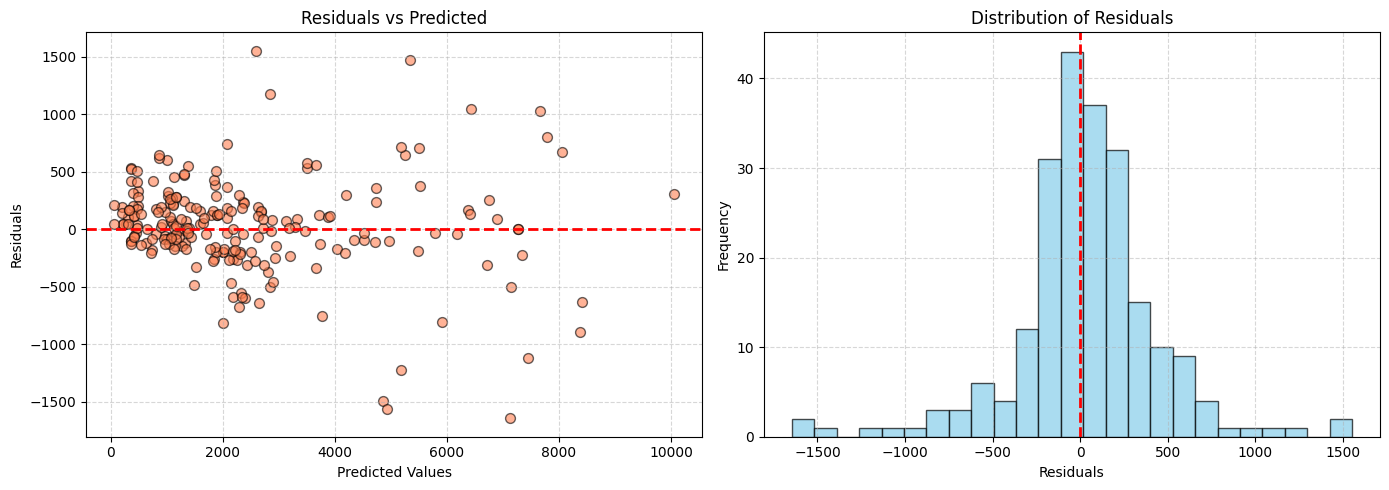


✅ All figures saved to: /content/drive/MyDrive/Master/Final/R_CFST_MLP_NoOutlier


In [ ]:
## **R_CFST — MLP (NO Outlier Removal)**

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1-3. نفس الكود (تحميل + تنظيف + Feature Engineering)
# ─────────────────────────────────────────────
import requests
from io import BytesIO

ALL_FEATURES_FILE = "https://raw.githubusercontent.com/FatemaTaher/CFST-Capacity-Prediction/main/CFST%20All%20Features.xlsx"
response = requests.get(ALL_FEATURES_FILE)
xls_all_features = pd.ExcelFile(BytesIO(response.content))

R_CFST = pd.read_excel(xls_all_features, sheet_name="R_CFST")
R_CFST = R_CFST.drop(columns=['No', 'Refference', 'Year', 'Ref. No', 'Speciment', 'fu (MPa)', 'Ec (GPa)'])
R_CFST = R_CFST[R_CFST['B (mm)'] == R_CFST['H (mm)']].reset_index(drop=True)
print(f"After filtering B=H: {R_CFST.shape}")

TARGET = 'N Test (kN)'
X = R_CFST.drop(columns=[TARGET]).copy()
y = R_CFST[TARGET].copy()

if 'L /Le (mm)' in X.columns:
    X.rename(columns={'L /Le (mm)': 'Le (mm)'}, inplace=True)

# Basic ratios
X['B_t_ratio'] = X['B (mm)'] / X['t (mm)']
X['L_B_ratio'] = X['Le (mm)'] / X['B (mm)']
X['fy_fc_ratio'] = X['fy (MPa)'] / X['fc (MPa)']

# Advanced features
perimeter = 4 * X['B (mm)']
X['As_mm2'] = perimeter * X['t (mm)']
X['Ac_mm2'] = X['B (mm)'] ** 2 - X['As_mm2']
X['steel_ratio'] = X['As_mm2'] / (X['B (mm)'] ** 2)
X['fy_x_fc'] = X['fy (MPa)'] * X['fc (MPa)']
X['fy_x_area'] = X['fy (MPa)'] * (X['B (mm)'] ** 2)
X['L_B_ratio_sq'] = X['L_B_ratio'] ** 2
X['t_B_ratio'] = X['t (mm)'] / X['B (mm)']

r = X['B (mm)'] / np.sqrt(12)
Es = 200000
X['lambda_norm'] = (X['Le (mm)'] / r) / np.sqrt(X['fy (MPa)'] / Es)

for col in ['H (mm)', 'H_t_ratio']:
    if col in X.columns:
        X = X.drop(columns=[col])

# Encode categorical
obj_cols = X.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    unique_vals = X[col].dropna().unique()
    print(f"Encoding '{col}': {unique_vals}")
    if len(unique_vals) <= 2:
        X[col] = X[col].str.lower().str.contains('cyl', na=False).astype(int)
    else:
        X[col] = X[col].astype('category').cat.codes

print(f"\nFinal features ({X.shape[1]}): {list(X.columns)}")
print(f"Samples: {len(y)} — NO outlier removal")

# ─────────────────────────────────────────────
# 4. Impute + Scale (بدل Outlier Removal)
# ─────────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler  # RobustScaler أحسن للـ Outliers

# Check NaN
print(f"\nNaN before imputation: {X.isna().sum().sum()}")

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"NaN after imputation: {X_imputed.isna().sum().sum()}")

# Use RobustScaler (يتحمل الـ Outliers)
scaler = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

# ─────────────────────────────────────────────
# 5. Nested CV + Optuna (20 Trials) — MLP
# ─────────────────────────────────────────────
import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS = 20

X_data = X_scaled
y_data = y

print(f"\n{'#'*55}")
print(f"# DATASET: {SHEET}")
print(f"# Samples: {len(y_data)} | Features: {X_data.shape[1]}")
print(f"# NO Outlier Removal — Using RobustScaler")
print(f"# Nested CV: {N_SPLITS_OUTER}-Fold Outer × {N_SPLITS_INNER}-Fold Inner")
print(f"# Optuna Trials: {N_TRIALS}")
print(f"{'#'*55}")

def run_mlp_nested_cv(X, y, label='MLP Regressor'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER, shuffle=True, random_state=RANDOM_STATE)
    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X), 1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # Scale داخل كل Fold (RobustScaler)
        scaler_inner = RobustScaler()
        X_tr_s = scaler_inner.fit_transform(X_tr)
        X_te_s = scaler_inner.transform(X_te)

        inner_cv = KFold(n_splits=N_SPLITS_INNER, shuffle=True, random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr_s):
            X_in_tr = X_tr_s[in_tr_idx]
            X_in_val = X_tr_s[in_val_idx]
            y_in_tr = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                n_layers = trial.suggest_int('n_layers', 1, 3)
                hidden_layers = tuple(
                    trial.suggest_int(f'n_units_l{i}', 32, 256, log=True)
                    for i in range(n_layers)
                )

                p = {
                    'hidden_layer_sizes': hidden_layers,
                    'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
                    'solver': trial.suggest_categorical('solver', ['adam', 'lbfgs']),
                    'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
                    'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
                    'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128, 'auto']),
                    'max_iter': 2000,
                    'early_stopping': True,
                    'validation_fraction': 0.15,
                    'n_iter_no_change': 20,
                    'random_state': RANDOM_STATE
                }

                if p['solver'] == 'lbfgs':
                    p['early_stopping'] = False
                    p['batch_size'] = 'auto'

                m = MLPRegressor(**p)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score = study.best_value
                best_params = study.best_params

        # Build final params
        n_layers = best_params['n_layers']
        hidden_layers = tuple(best_params[f'n_units_l{i}'] for i in range(n_layers))

        final_params = {
            'hidden_layer_sizes': hidden_layers,
            'activation': best_params['activation'],
            'solver': best_params['solver'],
            'alpha': best_params['alpha'],
            'learning_rate_init': best_params['learning_rate_init'],
            'batch_size': best_params['batch_size'],
            'max_iter': 3000,
            'early_stopping': True,
            'validation_fraction': 0.15,
            'n_iter_no_change': 30,
            'random_state': RANDOM_STATE
        }

        if final_params['solver'] == 'lbfgs':
            final_params['early_stopping'] = False
            final_params['batch_size'] = 'auto'

        model = MLPRegressor(**final_params)
        model.fit(X_tr_s, y_tr)
        y_pred = model.predict(X_te_s)

        r2 = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"layers={n_layers}  units={hidden_layers}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model': label,
        'R2_Mean': round(np.mean(outer_r2), 4),
        'R2_Std': round(np.std(outer_r2), 4),
        'RMSE_Mean': round(np.mean(outer_rmse), 2),
        'RMSE_Std': round(np.std(outer_rmse), 2),
        'MAE': round(np.mean(outer_mae), 2),
        'MAPE': round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

# Run
mlp_result = run_mlp_nested_cv(X_data, y_data, label='MLP Regressor')

print(f"\n{'='*60}")
print(f"FINAL RESULTS — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)
res = mlp_result
print(f"{res['model']:<22} "
      f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
      f"{res['RMSE_Mean']:>8.1f} "
      f"{res['MAE']:>8.1f} "
      f"{res['MAPE']:>7.2f}%")
print("="*60)

# ─────────────────────────────────────────────
# 6. Save + HoldOut + Figures
# ─────────────────────────────────────────────
from google.colab import drive
import joblib
import json
import os

drive.mount('/content/drive')
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_MLP_NoOutlier'
os.makedirs(BASE_DIR, exist_ok=True)

# Save
joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
joblib.dump(imputer, os.path.join(BASE_DIR, 'imputer.pkl'))

bp = mlp_result['best_params']
hidden_layers = tuple(bp[f'n_units_l{i}'] for i in range(bp['n_layers']))

final_params = {
    'hidden_layer_sizes': hidden_layers,
    'activation': bp['activation'],
    'solver': bp['solver'],
    'alpha': bp['alpha'],
    'learning_rate_init': bp['learning_rate_init'],
    'batch_size': bp['batch_size'],
    'max_iter': 5000,
    'early_stopping': True,
    'validation_fraction': 0.15,
    'n_iter_no_change': 50,
    'random_state': RANDOM_STATE
}

if final_params['solver'] == 'lbfgs':
    final_params['early_stopping'] = False
    final_params['batch_size'] = 'auto'

X_full_s = scaler.fit_transform(imputer.fit_transform(X))
mlp_final = MLPRegressor(**final_params)
mlp_final.fit(X_full_s, y)

joblib.dump(mlp_final, os.path.join(BASE_DIR, 'MLP_NestedCV.pkl'))

with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(mlp_result, f, indent=4)

print(f"\n✅ Saved to: {BASE_DIR}")

# HoldOut
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Impute + Scale
imp_ho = SimpleImputer(strategy='median')
X_train_i = imp_ho.fit_transform(X_train)
X_test_i = imp_ho.transform(X_test)

sc_ho = RobustScaler()
X_train_s = sc_ho.fit_transform(X_train_i)
X_test_s = sc_ho.transform(X_test_i)

# MLP with best params
mlp_ho = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

mlp_ho.fit(X_train_s, y_train)
y_pred = mlp_ho.predict(X_test_s)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n{'='*60}")
print(f"HOLDOUT VALIDATION (70/30)")
print(f"{'='*60}")
print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAE  = {mae:.2f}")
print(f"MAPE = {mape:.2f}%")

joblib.dump(mlp_ho, os.path.join(BASE_DIR, 'MLP_HoldOut.pkl'))

# Figures
import matplotlib.pyplot as plt
import seaborn as sns

# Regression Line
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=60, color='darkorange')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
ax.plot(y_test, p(y_test), 'g-', lw=2, alpha=0.8)

textstr = f'$R^2$ = {r2:.4f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}\nMAPE = {mape:.2f}%'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Actual N (kN)', fontsize=12)
ax.set_ylabel('Predicted N (kN)', fontsize=12)
ax.set_title(f'{SHEET} — MLP: Actual vs Predicted (No Outlier Removal)', fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'regression_line_plot.png'), dpi=300)
plt.show()

# Residuals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
residuals = y_test - y_pred

ax1.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', s=50, color='coral')
ax1.axhline(y=0, color='r', linestyle='--', lw=2)
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Predicted')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.hist(residuals, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Residuals')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Residuals')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'residuals_plot.png'), dpi=300)
plt.show()

print(f"\n✅ All figures saved to: {BASE_DIR}")

## **Sheet 4) R_CFST_BC**


*   XGBoost
*    Voting(RF+XGboost)



### **Setup**

In [ ]:

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'R_CFST_BC'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

Dataset: R_CFST_BC
Samples: 370  Features: 14


### **Model 1: XGBoost + Nested CV + Optuna**


In [ ]:


def run_xgb_nested_cv(X, y, label='XGBoost'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_estimators':trial.suggest_int('n_estimators', 100, 1200),
                    'learning_rate':trial.suggest_float('learning_rate', 0.005, 0.3,log=True),
                    'max_depth':trial.suggest_int('max_depth', 3, 12),
                    'subsample':trial.suggest_float('subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                    'reg_lambda':trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                    'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                    'gamma':trial.suggest_float('gamma', 1e-8, 1.0,log=True),
                    'random_state': RANDOM_STATE, 'n_jobs': -1
                }
                m = xgb.XGBRegressor(**p, verbosity=0)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS,
                           show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })
        model = xgb.XGBRegressor(**best_params, verbosity=0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }



### **Model 2: Voting (RF + Tuned XGBoost) + Nested CV**


In [ ]:

def run_voting_nested_cv(X, y, xgb_best_params,
                            label='Voting'):

    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_rf_params = None
        best_score     = -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def rf_objective(trial):
                p = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                    'max_depth': trial.suggest_int('max_depth', 5, 20),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                    'max_features': trial.suggest_float('max_features', 0.3, 1.0),
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1
                }
                rf = RandomForestRegressor(**p)
                rf.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, rf.predict(X_in_val))

            study_rf = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study_rf.optimize(rf_objective,
                              n_trials=N_TRIALS // 2,
                              show_progress_bar=False)

            if study_rf.best_value > best_score:
                best_score     = study_rf.best_value
                best_rf_params = study_rf.best_params

        best_rf_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })


#voting
        estimators = [
            ('rf',  RandomForestRegressor(**best_rf_params)),
            ('xgb', xgb.XGBRegressor(
                **xgb_best_params, verbosity=0)),
        ]
        voting = VotingRegressor(
            estimators = estimators,
            n_jobs     = -1,
        )
        voting.fit(X_tr, y_tr)
        y_pred = voting.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}")

    print(f"\n {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':label,
        'R2_Mean':round(np.mean(outer_r2),   4),
        'R2_Std':round(np.std(outer_r2),    4),
        'RMSE_Mean':round(np.mean(outer_rmse), 2),
        'RMSE_Std':round(np.std(outer_rmse),  2),
        'MAE':round(np.mean(outer_mae),  2),
        'MAPE':round(np.mean(outer_mape), 2),
    }

### **Execution**


In [ ]:
print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

xgb_result = run_xgb_nested_cv(X, y, label='XGBoost')

voting_result = run_voting_nested_cv(
    X, y,
    xgb_best_params = xgb_result['best_params'],
    label           = 'Voting (RF + XGB)'
)


#######################################################
# SHEET: R_CFST_BC
#######################################################

XGBoost — Nested CV
  Fold 1: R²=0.9775  RMSE=124.1  depth=5
  Fold 2: R²=0.9718  RMSE=209.3  depth=3
  Fold 3: R²=0.9734  RMSE=129.2  depth=7
  Fold 4: R²=0.9909  RMSE=102.8  depth=3
  Fold 5: R²=0.9209  RMSE=288.7  depth=4

 XGBoost:
    R²   = 0.9669 ± 0.0240
    RMSE = 170.82 ± 69.16
    MAE  = 92.94
    MAPE = 9.76%

Voting (RF + XGB) — Nested CV
  Fold 1: R²=0.9688  RMSE=146.3
  Fold 2: R²=0.9428  RMSE=298.4
  Fold 3: R²=0.9702  RMSE=136.8
  Fold 4: R²=0.9839  RMSE=136.5
  Fold 5: R²=0.8707  RMSE=369.1

 Voting (RF + XGB):
    R²   = 0.9473 ± 0.0405
    RMSE = 217.43 ± 97.63
    MAE  = 118.95
    MAPE = 11.69%


### **RESULTS**


In [ ]:

print(f"\n{'='*60}")
print(f"FINAL COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)

for res in [xgb_result, voting_result]:
    print(f"{res['model']:<22} "
          f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
          f"{res['RMSE_Mean']:>8.1f} "
          f"{res['MAE']:>8.1f} "
          f"{res['MAPE']:>7.2f}%")

print("="*60)

winner = (xgb_result if xgb_result['R2_Mean'] >=
          voting_result['R2_Mean'] else voting_result)
print(f"\nWinner for {SHEET}: {winner['model']} "
      f"(R²={winner['R2_Mean']:.4f})")





FINAL COMPARISON — R_CFST_BC
Model                            R²               RMSE      MAE   MAPE%
------------------------------------------------------------
XGBoost                0.9669 ± 0.0240     170.8     92.9    9.76%
Voting (RF + XGB)      0.9473 ± 0.0405     217.4    119.0   11.69%

Winner for R_CFST_BC: XGBoost (R²=0.9669)


### **Save**


In [ ]:


import joblib
import json
import os
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)


scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved: {scaler_path}")

xgb_final = xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0)
xgb_final.fit(X, y)
joblib.dump(xgb_final, os.path.join(BASE_DIR, 'XGBoost_NestedCV.pkl'))
print(f"XGBoost final model saved.")

rf_best_params = {'n_estimators': 300, 'max_depth': 10, 'random_state': RANDOM_STATE}
voting_final = VotingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(**rf_best_params, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0))
    ],
    n_jobs=-1
)
voting_final.fit(X, y)
joblib.dump(voting_final, os.path.join(BASE_DIR, 'Voting_NestedCV.pkl'))
print(f"Voting final model saved.")

all_results = {
    "XGBoost": xgb_result,
    "Voting": voting_result
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scaler saved: /content/drive/MyDrive/Master/Final/R_CFST_BC/scaler.pkl
XGBoost final model saved.
Voting final model saved.


### **Train/Test split 70/30**


In [ ]:
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

SHEET = 'R_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("Scaler Saved")

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")
print(f"MAPE     : {mape:.2f}%")

joblib.dump(model, os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl'))
print(f"\nSaved in: {BASE_DIR}")

Train: 296, Test: 74
Scaler Saved
R² Score : 0.9792
RMSE     : 119.30
MAE      : 80.62
MAPE     : 10.51%

Saved in: /content/drive/MyDrive/Master/Final/R_CFST_BC


### **Feature Importance**

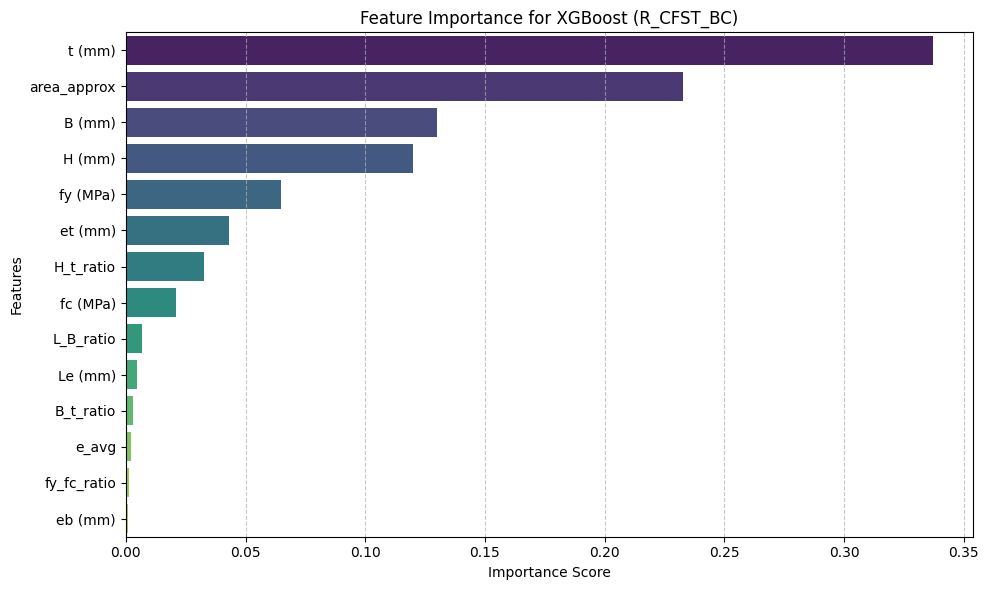

        Feature  Importance
2        t (mm)    0.336878
11  area_approx    0.232665
0        B (mm)    0.129947
1        H (mm)    0.120097
4      fy (MPa)    0.064883
6       et (mm)    0.042954
9     H_t_ratio    0.032792
5      fc (MPa)    0.020905
10    L_B_ratio    0.006707
3       Le (mm)    0.004886
8     B_t_ratio    0.003194
13        e_avg    0.002182
12  fy_fc_ratio    0.001139
7       eb (mm)    0.000770


In [ ]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SHEET = 'R_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')

loaded_model = joblib.load(model_path)

feature_names = X.columns

importances = loaded_model.feature_importances_
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance for XGBoost ({SHEET})')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(df_imp)

### **SHAP Analysis**

**How to Read SHAP Plots** 📊
Vertical Axis (Y): Features are ranked by importance (top = most influential). 🥇

Horizontal Axis (X): Shows the impact on the model's output.

Right of the center line: Positive impact (increases output). 📈

Left of the center line: Negative impact (decreases output). 📉

**Color Scale:**

Red dots (High): Represent high feature values. 🔴

Blue dots (Low): Represent low feature values. 🔵

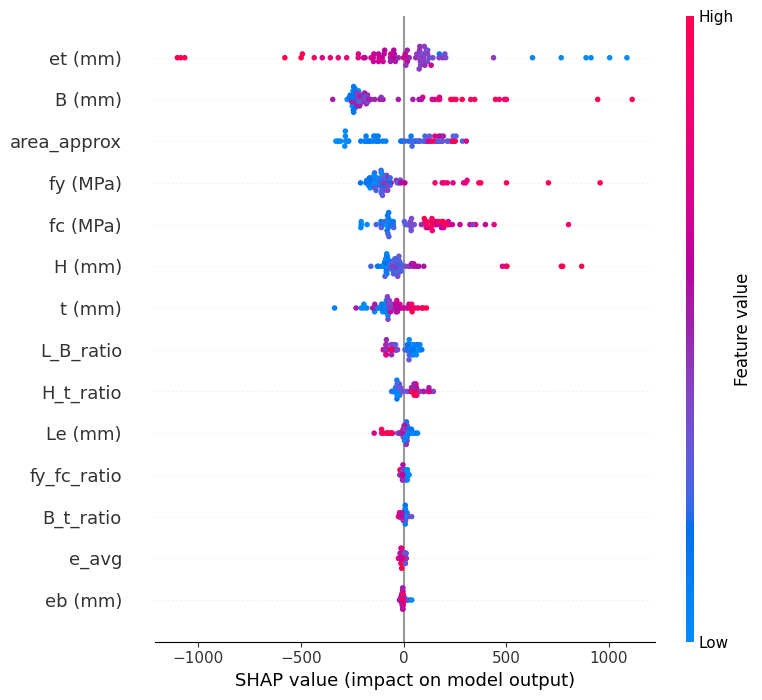

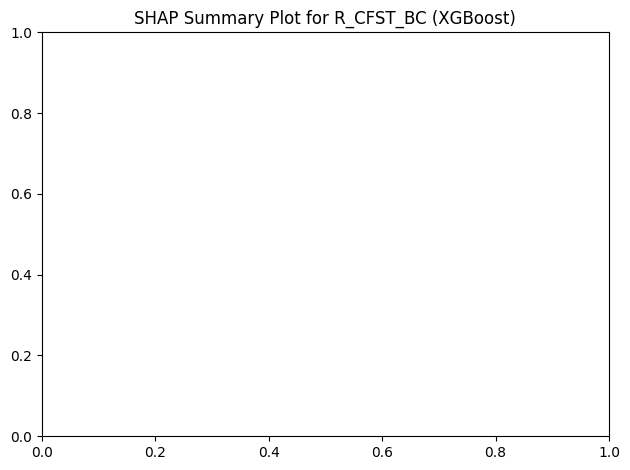

In [ ]:
import shap
import joblib
import os
import matplotlib.pyplot as plt

model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
model = joblib.load(model_path)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)
plt.title(f"SHAP Summary Plot for {SHEET} (XGBoost)")
plt.tight_layout()
plt.show()

# **Analysis**

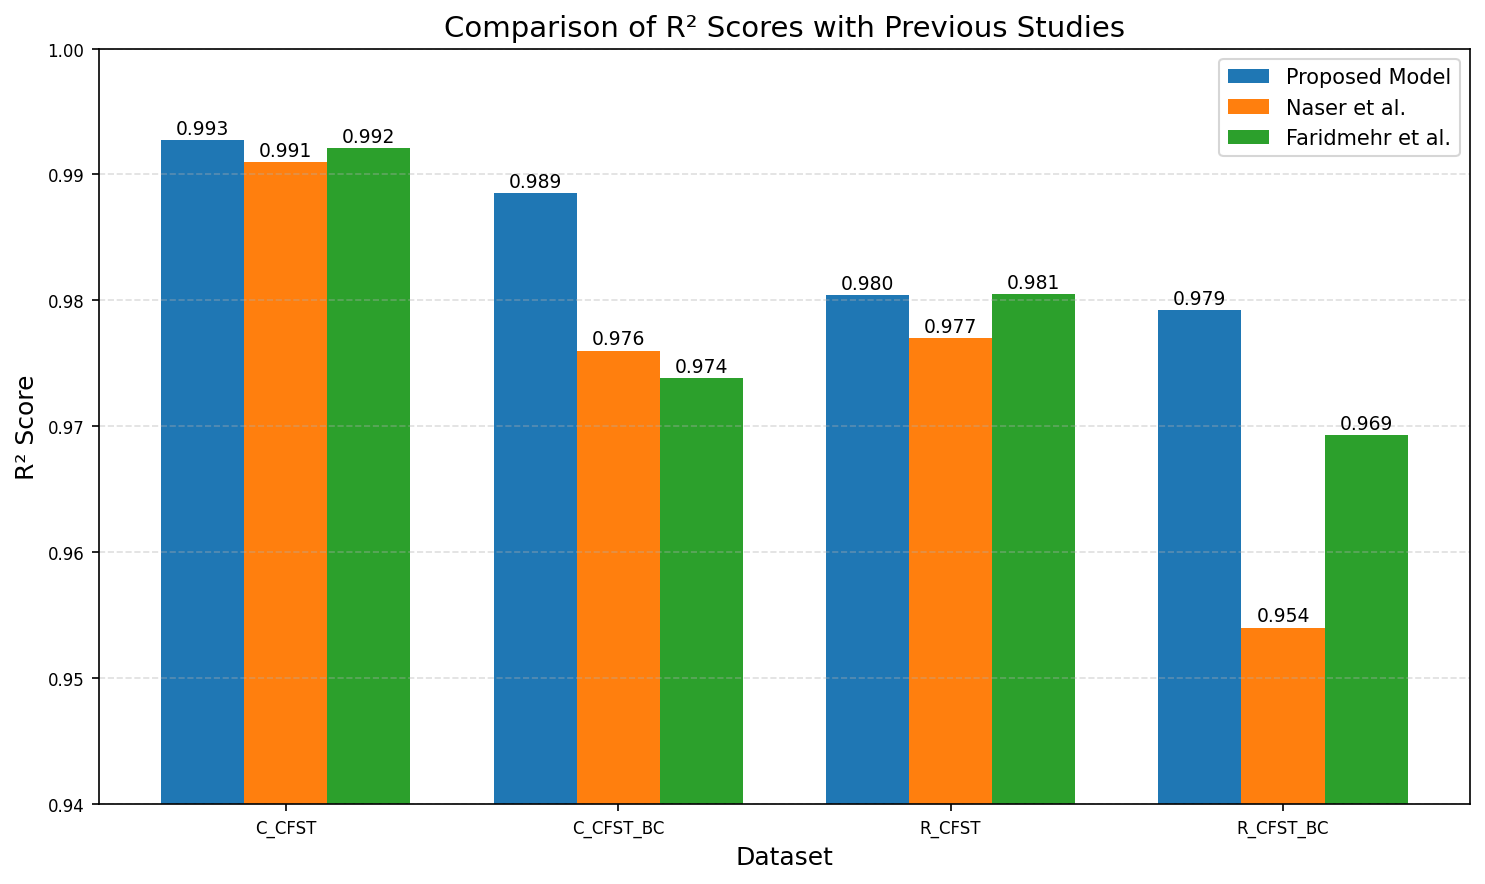

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

datasets = ['C_CFST', 'C_CFST_BC', 'R_CFST', 'R_CFST_BC']

our_results = [0.9927, 0.9885,0.9804 , 0.9792]
naser = [0.9910, 0.9760, 0.9770, 0.9540]
faridmehr = [0.9921, 0.9738, 0.9805, 0.9693]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width, our_results, width,
                label='Proposed Model')
bars2 = plt.bar(x, naser, width,
                label='Naser et al.')
bars3 = plt.bar(x + width, faridmehr, width,
                label='Faridmehr et al.')

plt.ylabel('R² Score', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.title('Comparison of R² Scores with Previous Studies', fontsize=14)
plt.xticks(x, datasets)
plt.ylim(0.94, 1.00)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.0005,
            f'{height:.3f}',
            ha='center',
            fontsize=9
        )

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('comparison_with_previous_studies.png', dpi=300)
plt.show()